# NIPS Curve Processing
Reusable processing and interpretation functions for a single zero curve and one or more sample curves.

**V1 - Took out less noise from the second derivative graph, enabling it to find the *actual* minimum of the curve.**

***What was fixed***: A lot of the proper minimums found were really accurate and ended up fixing the yellow/green regions as well

***Areas to improve***: Sometimes it chooses a less 'certain' minimum rather than the clear one. Needs a more comprehensive system to address it.

**V1-5 - Making the breakpoints better reflect the curve in a *single run.***

sometimes it chooses the wrong minimum. so I would like to have it recognize when its not good (maybe alongside the good fit heuristic though that would require multiple runs) and search 0.3 to the left and 0.3 to the right towards the endpoints of the search, 0 and 0.3 (just so that it doesnt choose the data pt like in that general hump and get the NEXT minimum

if there was a way to compare with one another...

I think I would like to make a separate function where it takes in breakpoint 1 (so i can manually adjust it for testing), generates the segmentation, checks for fit (the heuristic for this needs to be determined, maybe like total errors squared) and doesn't just return True or False, but like a *score*. And the highest score is the one that wins.

Again I would need to make sure that breakpoint 1 is THE ONLY thing wrong with this implementation before doing an automated undertaking, but yea I might have that
It's just that I really just think it would be helpful and more likely to be optimized, but the restructuring of everything might be too much of a task to reliably finish as ameans to just understand the code.

I think my changes for V1-5 is going to focus on curve-unrelated ones for now bc it's really hard to implement it. This just means that the heuristic of 'the yellow line should be below the curve' just cant happen. So I can't use that to systematically check for the next point... *yet*.

**V2 - Attempting to restructure**

I'm going to try to move everything into separate functions because i just really gotta organize things. Having everything lumped into the same thing might not be wise either.

**SECTION 1**: Imports and initialization

In [ ]:
import warnings
from pathlib import Path
import datetime

import matplotlib.pyplot as plt
import numpy as np
import copy
import pandas as pd
import piecewise_regression
from pygam import LinearGAM, s
from scipy.signal import find_peaks, peak_prominences ##NEW -- for second deriv analysis
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")

def namestr(obj, namespace):          #read the file name of data
    return [name for name in namespace if namespace[name] is obj][0]

LOAD_COL = "Ch:Load (N)"
LVDT_COL = "S:LVDT (in)"
SETPOINT_COL = "Set Point ()"

# ── Save config ──────────────────────────────────────────────────────────
SAVE_PLOTS = True   # set False to disable saving
SAVE_ROOT  = Path(f"pipeline_plots_{datetime.date.today().strftime('%Y-%m-%d')}")
# ─────────────────────────────────────────────────────────────────────────


**SECTION 2**: Data Pre-Processing

In [ ]:
def load_curve_data(file_path):
    return pd.read_csv(file_path)

def apply_load_cutoff(df, load_cutoff=1.0, load_col=LOAD_COL):
    return df[df[load_col] >= load_cutoff].copy()

def truncate_sample_keep_creep(
    df,
    lvdt_col=LVDT_COL,
    setpoint_col=SETPOINT_COL,
    creep_threshold=1.0,
    new_col="S:LVDT_shifted (um)",
):
    df = df.sort_index().copy()
    anchor_idx = df.index[-1]
    if setpoint_col in df.columns:
        mask_creep = df[setpoint_col] >= creep_threshold
        if mask_creep.any():
            anchor_idx = df[mask_creep].index[-1]
            df = df.loc[:anchor_idx].copy()
    df[new_col] = (df[lvdt_col]) * 25400.0


    # Remove data after the first point where 'Set Point ()' > 1
    # first_exceed_index = df[df[setpoint_col] > 1].index.min()
    # if not np.isnan(first_exceed_index):  # Check if such a point exists
    #     df = df.loc[:first_exceed_index - 1]  # Truncate data

    return df


def process_curve_raw(file_path, load_cutoff=1.0):
    df = load_curve_data(file_path)
    df_proc = truncate_sample_keep_creep(df)
    df_proc = apply_load_cutoff(df_proc, load_cutoff=load_cutoff)
    return df_proc


def shift_sample_and_zero_curve(
    df_zero,
    df_sample,
    lvdt_col="S:LVDT_shifted (um)",
):  
    df_zero_shift_value = df_zero[lvdt_col].iloc[-1]
    df_zero[lvdt_col] = df_zero[lvdt_col] - df_zero_shift_value
    df_sample[lvdt_col] = df_sample[lvdt_col] - df_zero_shift_value
    return df_zero, df_sample


def subtract_zero_from_sample(
    df_zero,
    df_sample,
    load_col=LOAD_COL,
    zero_disp_col="S:LVDT_shifted (um)",
    sample_disp_col="S:LVDT_shifted (um)",
    new_col="Disp_corrected (um)",
    keep_full_sample_load_range=True,
):
    z = df_zero.sort_values(load_col)
    s = df_sample.sort_values(load_col).copy()
    if not keep_full_sample_load_range:
        min_load = max(z[load_col].min(), s[load_col].min())
        max_load = min(z[load_col].max(), s[load_col].max())
        mask = (s[load_col] >= min_load) & (s[load_col] <= max_load)
        s = s[mask].copy()
    zero_loads = z[load_col].values
    zero_disp = z[zero_disp_col].values
    sample_loads = s[load_col].values
    zero_disp_interp = np.interp(sample_loads, zero_loads, zero_disp)
    s["Zero_interp (um)"] = zero_disp_interp
    s[new_col] = s[sample_disp_col] - zero_disp_interp
    return s



# Evaluation Functions

In [ ]:
def validData_eval(thickness):
    eval = True
    if thickness <= 50:
        eval = False
    return eval

'''
Valid data just means if it tested on a membrane. Nothing else.
Good data is a bit vague right now, but i think taking off the toe region is the main priority...
'''

def good_data():
    
    pass

from sklearn.metrics import r2_score
import numpy as np

def goodFit_eval(
    # data regions
    data, elasticRegion, xPlateau, xDensification,
    # predictions
    predElastic, predPlateau, predDensification,
    # models + key values
    modelElastic, modelPlateau,
    gam,                      # GAM spline on full stress-strain
    breakpoint1,              # elastic end strain
    changepoint,              # plateau-densification intersection strain
    yieldStrength,            # predicted stress at breakpoint1
    elasticModulus,
    slopePlateau,
    slopeDensification,
    creep_level=None,
    # thresholds
    pass_threshold=60,        # score >= this → True
):
    score = 0
    breakdown = {}
    catastrophic = False      # slope > modulus flags this; multiplies final score

    # ── ELASTIC REGION (30 pts) ──────────────────────────────────────────

    # R² of elastic linear fit (15 pts)
    w = 15
    if len(elasticRegion) > 1 and predElastic is not None:
        r2_e = r2_score(elasticRegion['stress (bar)'], predElastic)
        pts = round(w * max(r2_e, 0))
        breakdown['elastic_r2'] = (pts, w, f'R²={r2_e:.3f}')
        score += pts
    else:
        breakdown['elastic_r2'] = (0, w, 'insufficient data')

    # Yield point accuracy: GAM stress at bp1 vs linear model prediction (10 pts)
    w = 10
    gam_stress_at_bp1 = float(gam.predict([[breakpoint1]]))
    yield_err = abs(float(yieldStrength) - gam_stress_at_bp1)
    yield_err_pct = yield_err / (gam_stress_at_bp1 + 1e-9)
    pts = round(w * max(0, 1 - yield_err_pct / 0.10))  # full pts if <10% error (tighter)
    breakdown['yield_accuracy'] = (pts, w, f'|linear-GAM|={yield_err:.2f} bar ({yield_err_pct*100:.1f}%)')
    score += pts

    # Elastic modulus physical plausibility (5 pts)
    w = 5
    if elasticModulus > 0:
        pts = w if (10 < elasticModulus < 5000) else round(w * 0.5)
        breakdown['elastic_modulus'] = (pts, w, f'E={elasticModulus:.1f} bar')
    else:
        pts = 0
        breakdown['elastic_modulus'] = (0, w, f'negative modulus={elasticModulus:.1f}')
    score += pts

    # ── PLATEAU REGION (30 pts) ──────────────────────────────────────────

    # Junction continuity (15 pts) — most important, tighter tolerance
    w = 15
    if modelPlateau is not None:
        plateau_at_bp1 = float(modelPlateau.predict([[breakpoint1]]))
        junction_err_pct = abs(plateau_at_bp1 - float(yieldStrength)) / (abs(float(yieldStrength)) + 1e-9)
        pts = round(w * max(0, 1 - junction_err_pct / 0.10))  # full if <10% gap
        breakdown['junction_continuity'] = (pts, w, f'gap={junction_err_pct*100:.1f}%')
        score += pts
    else:
        breakdown['junction_continuity'] = (0, w, 'no plateau model')

    # Plateau slope vs modulus:
    #   - If slope > modulus → catastrophic (physically impossible for membrane)
    #   - Otherwise graded out of 5
    w = 5
    if slopePlateau > elasticModulus:
        pts = 0
        catastrophic = True
        breakdown['plateau_flatness'] = (0, w, f'CATASTROPHIC: slope={slopePlateau:.1f} > E={elasticModulus:.1f}')
    else:
        slope_ratio = abs(slopePlateau) / (abs(elasticModulus) + 1e-9)
        if slope_ratio < 0.10:
            pts = w
        elif slope_ratio < 0.25:
            pts = round(w * 0.5)
        else:
            pts = round(w * 0.2)
        breakdown['plateau_flatness'] = (pts, w, f'slope/E={slope_ratio:.3f}')
    score += pts

    # Plateau R² — first 40% of plateau only (beginning is what matters) (10 pts)
    w = 10
    if xPlateau is not None and len(xPlateau) > 1 and predPlateau is not None:
        cutoff = int(len(xPlateau) * 0.40)
        if cutoff >= 2:
            r2_p = r2_score(xPlateau['stress (bar)'].iloc[:cutoff], predPlateau[:cutoff])
        else:
            r2_p = r2_score(xPlateau['stress (bar)'], predPlateau)
        pts = round(w * max(r2_p, 0))
        breakdown['plateau_r2_start'] = (pts, w, f'R²(first 40%)={r2_p:.3f}')
        score += pts
    else:
        breakdown['plateau_r2_start'] = (0, w, 'insufficient data')

    # ── DENSIFICATION REGION (10 pts) ───────────────────────────────────

    # Densification slope > plateau slope (8 pts)
    w = 8
    if slopeDensification > slopePlateau:
        pts = w
    elif slopeDensification > 0:
        pts = round(w * 0.4)
    else:
        pts = 0
    breakdown['slope_ordering'] = (pts, w, f'densif={slopeDensification:.1f} > plateau={slopePlateau:.1f}')
    score += pts

    # Densification R² (2 pts — barely matters)
    w = 2
    if xDensification is not None and len(xDensification) > 1 and predDensification is not None:
        r2_d = r2_score(xDensification['stress (bar)'], predDensification)
        pts = round(w * max(r2_d, 0))
        breakdown['densification_r2'] = (pts, w, f'R²={r2_d:.3f}')
        score += pts
    else:
        breakdown['densification_r2'] = (0, w, 'insufficient data')

    # ── PHYSICAL PLAUSIBILITY (30 pts) ──────────────────────────────────

    # Elastic modulus > plateau slope (10 pts — hard check, separate from catastrophic)
    w = 10
    if elasticModulus > slopePlateau:
        pts = w
    else:
        pts = 0
    breakdown['elastic_vs_plateau'] = (pts, w, f'E={elasticModulus:.1f} > slope={slopePlateau:.1f}')
    score += pts

    # Breakpoint ordering: bp1 < changepoint < max_strain (5 pts)
    w = 5
    max_strain = data['strain'].max()
    if breakpoint1 < changepoint < max_strain:
        pts = w
    elif breakpoint1 < changepoint:
        pts = round(w * 0.5)
    else:
        pts = 0
    breakdown['breakpoint_order'] = (pts, w, f'bp1={breakpoint1:.3f} < cp={changepoint:.3f} < max={max_strain:.3f}')
    score += pts

    # Densification re-stiffens vs elastic (5 pts)
    w = 5
    if slopeDensification > elasticModulus * 0.5:
        pts = w
    elif slopeDensification > 0:
        pts = round(w * 0.5)
    else:
        pts = 0
    breakdown['densif_vs_elastic'] = (pts, w, f'densif/E={slopeDensification/(elasticModulus+1e-9):.2f}')
    score += pts

    # Sufficient data in each region (5 pts)
    w = 5
    min_pts = 5
    regions_ok = sum([
        len(elasticRegion) >= min_pts,
        xPlateau is not None and len(xPlateau) >= min_pts,
        xDensification is not None and len(xDensification) >= min_pts,
    ])
    pts = round(w * regions_ok / 3)
    breakdown['data_density'] = (pts, w, f'{regions_ok}/3 regions have ≥{min_pts} pts')
    score += pts

    # Changepoint within creep level (5 pts)
    w = 5
    if creep_level is not None:
        gam_stress_at_cp = float(gam.predict([[changepoint]]))
        pts = w if gam_stress_at_cp <= creep_level * 1.05 else 0
        breakdown['changepoint_vs_creep'] = (pts, w, f'GAM(cp)={gam_stress_at_cp:.1f} vs creep={creep_level:.1f}')
    else:
        pts = w
        breakdown['changepoint_vs_creep'] = (pts, w, 'no creep segment')
    score += pts

    # ── CATASTROPHIC PENALTY ─────────────────────────────────────────────
    # slope > modulus is physically impossible → halve the score
    if catastrophic:
        score = round(score * 0.5)
        breakdown['_catastrophic_penalty'] = (0, 0, 'slope > modulus — score halved')

    good = score >= pass_threshold
    return good, score, breakdown


def goodFit_eval_old(modelPlateau, predPlateau, breakpoint1, elasticModulus, yieldStrength, xPlateau):
    slopePlateau = modelPlateau.coef_[0]
    #evaluate fit
    plateauModel = LinearGAM(s(0))
    plateauModel.fit(xPlateau[['strain']], xPlateau['stress (bar)'])
    plateauSpline = plateauModel.predict(xPlateau[['strain']])

    correlation_coefficient = np.corrcoef(plateauSpline, predPlateau)[0, 1]
    #print(f"Correlation_coefficient: {correlation_coefficient:.4f}")
    
    #ensure the linear models align with each other
    rangeStart = yieldStrength - 3     #arbitrary range
    rangeEnd = yieldStrength + 3

    
    if rangeStart <= modelPlateau.predict(breakpoint1.reshape(1, -1)) <= rangeEnd and slopePlateau <= elasticModulus*1.25 and correlation_coefficient <= 0.98:
        eval = True
    else:
        if breakpoint1 <= 0.05: #arbitrary
            eval = False
        eval = True
    return eval

# Elastic Functions

In [203]:
## NEW METHODS
def pure_pw(data):
    '''
    EDIT - 6/9/2026
    I would like to have this 0.3 be a LOT more flexible
    piecewise regression is the most accurate when the beginning and end of the region are pretty uniformly linear.
    However, I can only make SURE of that after doing the model plateau, so that would just involve
    doing the exact same calculations again for no reason. 

    If there's a way I can have bp1 to like idk 0.4 or smth and have it identify a breakpoint there
    NOT from piecewise regression.... orrrr
    well also i could lwk just find another method
    '''
    # find approximate plateau window from 1st derivative
    d1_peak = data["1st derivative"].max()
    low_thresh = d1_peak * 0.15  # below this = plateau
    
    in_plateau = data["1st derivative"] < low_thresh
    plateau_start_approx = data["strain"][in_plateau].iloc[0]  if in_plateau.any() else 0.1
    plateau_end_approx   = data["strain"][in_plateau].iloc[-1] if in_plateau.any() else 0.5
    
    cutoff = (plateau_start_approx + plateau_end_approx) / 2
    print(f"Cutoff = {cutoff}")
    region = data[data["strain"] <= cutoff]
    try:
        pw_fit = piecewise_regression.Fit(list(region['strain']), list(region['stress (bar)']), n_breakpoints=1)
    except Exception as e:
        print(f"pw regression failed (n_bp={1}): {e}")
        return None
    pw_results = pw_fit.get_results()
    if pw_results['estimates']:
        bp1 = pw_results['estimates']['breakpoint1']['estimate']
        return bp1

    '''
    or double pw...?
    '''
    return None

def double_pw(data, bp1_init, interval):
    # constrain the regression data region around the initially determined bp1, so sort of like a second run
    tightened = data[(data['strain'] >= bp1_init - interval) & (data['strain'] <= bp1_init + interval)]
    try:
        pw_fit = piecewise_regression.Fit(list(tightened['strain']), list(tightened['stress (bar)']), n_breakpoints=1)
    except Exception as e:
        print(f"pw regression failed (n_bp={1}): {e}")
        return None
    pw_results = pw_fit.get_results()
    if pw_results['estimates']:
        bp1_double = pw_results['estimates']['breakpoint1']['estimate']
        return bp1_double
    return None
    
def find_drop(subset):
    #get slope ig
    subset['raw_slope'] = subset['2nd derivative'].diff() / subset['strain'].diff()
    subset['smooth_slope'] = subset['raw_slope'].rolling(window=5, center=True).mean()

    idx_bottom = subset['2nd derivative'].idxmin()   # This gets the ROW index (e.g. 452)
    strain_bottom = subset.loc[idx_bottom, 'strain'] # This gets the float strain (0.0741)
    val_bottom = subset.loc[idx_bottom, '2nd derivative']

    # 2. Extract left wall metrics
    left_side = subset.loc[:idx_bottom]
    val_start = left_side['2nd derivative'].max() 
    idx_start = left_side['2nd derivative'].idxmax()
    
    # 3. Extract right wall metrics safely
    right_side = subset.loc[idx_bottom:]
    
    # Isolate the localized recovery window
    local_window = right_side[right_side['strain'] <= (strain_bottom + 0.05)]
    
    # SAFE GUARD: Verify the window isn't empty before taking max
    if not local_window.empty:
        val_end_peak = local_window['2nd derivative'].max()
    else:
        val_end_peak = right_side['2nd derivative'].max() # Fallback to full right side if narrow

    total_climb_height = val_end_peak - val_bottom

    # 5. Define target flattening threshold (90% up the climb)
    flattening_target_y = val_bottom + (total_climb_height * 0.90)

    # 6. Locate first crossing index cleanly
    recovery_zone = right_side[right_side['2nd derivative'] >= flattening_target_y]
    idx_end = recovery_zone.index[0] if not recovery_zone.empty else right_side.index[-1]

    #strain
    strain_start = subset.loc[idx_start, 'strain']
    strain_end = subset.loc[idx_end, 'strain']

    # 8. Compute finalized net vertical delta
    val_start = subset.loc[idx_start, '2nd derivative']
    val_end = subset.loc[idx_end, '2nd derivative']
    net_height_drop = val_start - val_end
    if net_height_drop > 1500 or val_start - val_bottom > 5000:
        breakpoint1 = (strain_bottom + ((strain_end-strain_bottom) / 2.5))
    else:
        breakpoint1 = strain_bottom
    
    return breakpoint1

def elastic_peak(data, predictions):
    #takes in the data, outputs breakpoint1 - useful in case we want to manually change breakpoint



    #identify the elastic region
    # normal way
    data['2nd derivative'].idxmin()     #found the minimum of the 2nd derivative 
    #breakpoint1 = data['strain'][data['2nd derivative'].idxmin()]

    # ORIGINAL PROCESS
    # Restrict search to strain <= 0.3
    subset = data[data['strain'] <= 0.3]
    
   

    #make GAM on the first derivative (wasnt working originally bc of inf and NaN points)
    
    #boolean because there shouldn't be any infinite points in here
    clean_mask = (
        np.isfinite(data['strain']) & 
        np.isfinite(data['1st derivative']) 
        #(data['strain'] > 0.03)  # <-- This strips out the beginning data
    )
    X_clean = data['strain'][clean_mask].values.reshape(-1, 1) #for the GAM
    y_clean = data['1st derivative'][clean_mask].values
    
    
    gam_d1 = LinearGAM(s(0, n_splines=25, lam=0.5, penalties='derivative')).fit(X_clean, y_clean)
    #replace
    data['1st derivative'] = gam_d1.predict(data['strain'].values.reshape(-1, 1))

    
    data['2nd derivative'] = np.gradient(data['1st derivative'], data['strain'])


    
    #Implement V3 of noise reduction
    spike = data['2nd derivative'].diff().abs()
    data.loc[data['2nd derivative'].abs() > 25000, '2nd derivative'] = np.nan
    data.loc[spike > 150, '2nd derivative'] = np.nan
    data['2nd derivative'] = data['2nd derivative'].interpolate(method='linear')
    
    
    subset = data[data['strain'] <= 0.3]
    if subset['strain'][subset['2nd derivative'].idxmin()] <= 0.02:
        subset = data[(data['strain'] > 0.03) & (data['strain'] <= 0.3)].copy()

    bp1_pw = pure_pw(data)
    breakpoint1 = find_drop(subset)
    bp1_double = double_pw(data, bp1_pw, 0.1) if bp1_pw is not None else None  #last parameter should be dynamic
    print(f"PW + Double: {bp1_double}")
    if bp1_pw is not None and bp1_pw >= 0:
        print(f"Piecewise Chosen! {bp1_pw} | Drop Calculation: {breakpoint1}")
        return bp1_pw
    print(f"Drop Chosen! {breakpoint1} | Piecewise Calculation: {bp1_pw}")
    return breakpoint1

# Plateau/Densification Functions

In [204]:
'''PLATEAU/DENSIFICATION - Returns changepoint, modelPlateau, modelDens'''

def find_changepoint_old(data, regions):
    try:
        pw_fit = piecewise_regression.Fit(list(regions['strain']), list(regions['stress (bar)']), n_breakpoints=4)
    except Exception as e:
        print(f"Piecewise regression fitting failed: {e}")
        return None, None
    
    pw_results = pw_fit.get_results()
    
    if pw_results['estimates'] != None:
        breakpoint2 = pw_results['estimates']['breakpoint1']['estimate']
        breakpoint3 = pw_results['estimates']['breakpoint4']['estimate']
        return breakpoint2, breakpoint3
    
    else:
        return None, None
def find_breakpoints(data, regions):
    for n_bp in [4, 2]:
        try:
            pw_fit = piecewise_regression.Fit(list(regions['strain']), list(regions['stress (bar)']), n_breakpoints=n_bp)
        except Exception as e:
            print(f"pw regression failed (n_bp={n_bp}): {e}")
            continue

        pw_results = pw_fit.get_results()
        if pw_results['estimates'] is None:
            continue  # try fewer breakpoints

        if n_bp == 4:
            breakpoint2      = pw_results['estimates']['breakpoint1']['estimate']
            breakpoint3      = pw_results['estimates']['breakpoint4']['estimate']
            breakpoint_extra2 = pw_results['estimates']['breakpoint2']['estimate']
            breakpoint_extra3 = pw_results['estimates']['breakpoint3']['estimate']

            bp2 = (breakpoint_extra2 - 0.05) if breakpoint2 - regions['strain'].iloc[0] < 0.1 else breakpoint2 + 0.01
            bp3 = (breakpoint_extra3 + 0.01) if regions['strain'].iloc[-1] - breakpoint3 < 0.05 else breakpoint3 - 0.03
        else:
            bp2 = pw_results['estimates']['breakpoint1']['estimate']
            bp3 = pw_results['estimates']['breakpoint2']['estimate']

        return bp2, bp3

    return None, None




def create_changepoint():
    pass

#ok side - we have stress to strain but not the other way around which is VERY annoying
def stress_GAM(gam, strain):
        idx = np.array([[strain]])
        return gam.predict(idx)


# Model Functions

In [205]:
### RELIES ON THE BP2/BP3 METHOD -- MAY BE SCRAPPED AS NEW METHODS ARE DEVISED
def find_changepoint_fit(data, bp1, bp2, bp3, creep_level):
    plateauRegion = data[(bp1 + 0.03 <= data['strain']) & (data['strain'] <= bp2)]
    densificationRegion = data[bp3 <= data['strain']]
    
    #calculate the plateau region slope
    modelPlateau = LinearRegression() 
    modelPlateau.fit(plateauRegion['strain'].values.reshape(-1, 1), plateauRegion['stress (bar)'].values)
    slopePlateau = modelPlateau.coef_[0] #oh so mx + b, coef[0] is the m and intercept is the b
    interceptPlateau = modelPlateau.intercept_

    #calculate the densification region slope
    modelDensification = LinearRegression()
    modelDensification.fit(densificationRegion['strain'].values.reshape(-1, 1), densificationRegion['stress (bar)'].values)
    slopeDensification = modelDensification.coef_[0]
    interceptDensification = modelDensification.intercept_

    #calculate the changepoint between the plateau and densification region
    changepoint = (interceptDensification - interceptPlateau) / (slopePlateau - slopeDensification) #(b2-b1)/(m1-m2)
    xPlateau = data[(bp1 <= data['strain']) & (data['strain'] <= changepoint)]
    xDensification = data[changepoint <= data['strain']]
    ### wait what is this
    
    if len(xDensification) > 0 and len(xPlateau) > 0:
            
        predPlateau = modelPlateau.predict(xPlateau[['strain']])
        predDensification = modelDensification.predict(xDensification[['strain']])
        # replace values in predDensification that are greater than the predictions[-1] with predictions[-1]
        if creep_level is not None:
            predDensification[predDensification > creep_level] = creep_level
    return xPlateau, xDensification, predPlateau, predDensification, changepoint, slopePlateau, slopeDensification, modelPlateau
    
##unused
def create_fit_week3(data, bp1, changepoint, creep_level, bp2=None, bp3=None):
    pass


In [206]:
def graph_derivs(data, breakpoint1,bp1):
        fig, (fir, sec) = plt.subplots(1,2, figsize=(10,4))
        #fir.plot(data['strain'], data['1st derivative'], color='green')
        fir.plot(data['strain'], data['1st derivative'], color='green')
        #fir.plot(data['strain'], deriv_for_plot, color='green') - FAILED V0
        #fir.axvline(x=data['2nd derivative'][idx_bottom], color='r', linestyle = ':', label = 'old minimum')
        fir.axvline(x=breakpoint1, color='purple', linestyle = ':', label = 'NEW minimum')
        sec.scatter(data['strain'], data['2nd derivative'], color='pink', s=1)
        #sec.plot(data['strain'], deriv_for_plot, color='black') - FAILED V2
        sec.axvline(x=breakpoint1, color='green', linestyle = ':', label = 'NEW minimum')
        if bp1 is not None:
            sec.axvline(x=bp1, color='blue', linestyle=':', label='PW breakpoint')


def plot_average_curve(processed_curves, cutoff_load_displacement=2, condition_name="", save_dir=None):
    """
    Call once per condition (after all reps processed) to show average stress-strain + CV.
    Comment out the call in process_zero_sample_pairs_pipeline to skip.
    """
    stress_data = []
    strain_data = []

    for df in processed_curves:
        d = df[df['Ch:Load (N)'] > cutoff_load_displacement].copy()
        if 'Set Point ()' in d.columns and (d['Set Point ()'] > 1).any():
            d = d[d['Set Point ()'] <= 1].copy()
        if 'stress (bar)' not in d.columns or 'strain' not in d.columns:
            continue
        d = d.sort_values('stress (bar)').reset_index(drop=True)
        d['strain'] = d['strain'] - d['strain'].iloc[0]
        stress_data.append(d['stress (bar)'].values)
        strain_data.append(d['strain'].values)

    if not stress_data:
        return None

    common_min = max(s[0]  for s in stress_data)
    common_max = min(s[-1] for s in stress_data)
    n_pts      = min(len(s) for s in stress_data)
    common_stress = np.linspace(common_min, common_max, n_pts)

    aligned = np.array([
        np.interp(common_stress, stress, strain)
        for stress, strain in zip(stress_data, strain_data)
    ])
    avg_strain = np.mean(aligned, axis=0)
    std_strain = np.std(aligned,  axis=0)

    overall_avg = np.mean(avg_strain)
    overall_std = np.mean(std_strain)
    cv = overall_std / overall_avg if overall_avg != 0 else np.nan

    plt.figure(figsize=(8, 5.5))
    for i, (stress, strain) in enumerate(zip(stress_data, strain_data)):
        plt.plot(strain, stress, alpha=0.35, linewidth=1, label=f"Rep {i+1}")
    plt.plot(avg_strain, common_stress, color='black', linewidth=2.5, label='Average')
    plt.fill_betweenx(common_stress,
                      avg_strain - std_strain,
                      avg_strain + std_strain,
                      color='grey', alpha=0.3, label='+/-1 SD')
    plt.plot([],[], label=f'CV = {cv}')

    plt.xlabel('Strain', fontsize=16)
    plt.ylabel('Stress (bar)', fontsize=16)
    plt.title(condition_name, fontsize=14)
    plt.legend(fontsize=10)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    
    if SAVE_PLOTS and save_dir is not None:
        _sd = Path(save_dir)
        _sd.mkdir(parents=True, exist_ok=True)
        plt.savefig(_sd / "Comparison_CV.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"CV ({condition_name}): {cv:.4f}")
    return cv


# Terminology for Section 4

*elasticRegion* - x and y values of DATA up until breakpoint1 (how is this used to graph?)
*xPlateau/Densification* - ALSO x and y values of data, but based on the changepoint

In [207]:

#EXTRACT KNOWLEDGE OF A DATA BATCH
def interpretData(data_list, thickness_info = True, thickness_list = None, creep_info = True, cutoff_load_thickness=1, cutoff_load_displacement=2, save_path=None):
    #retrieves thickness information
    thickness = []
    if thickness_info:
        thickness = thickness_list
    else:
        for i in range(len(data_list)):
            thickness.append(-data_list[i]["Disp_corrected (um)"][data_list[i]['Ch:Load (N)'] > cutoff_load_thickness].iloc[0])

    #add concentration and heating to returned list
    mechanicalProperties = []
    
    #set up stress strain curve
    for i in range(len(data_list)): 
        data_list[i]['stress (bar)'] = data_list[i]['Ch:Load (N)'] / 19.635 *10      #create stress column which is load / area, the area is 19.635 mm^2
        data_list[i]['strain'] = data_list[i]['Disp_corrected (um)'] / thickness[i]      #create strain column which is displacement / thickness, the thickness is shown above
    
    # Calculate average standard deviation for all data points
    all_stress_data = []
    for i in range(len(data_list)):
        data = data_list[i][data_list[i]['Ch:Load (N)'] > cutoff_load_displacement]
        data['strain'] = data['strain'] - data['strain'].iloc[0]     #shift the data so that the first point is at 0 in 'S:LVDT (in)'
        data = data.reset_index(drop=True)
        all_stress_data.append(data['stress (bar)'].values)

    min_length = min([len(stress) for stress in all_stress_data])
    truncated_stress_data = [stress[:min_length] for stress in all_stress_data]
    avg_standard_deviation = np.mean([np.std(stress) for stress in truncated_stress_data])
    print(f"Average Standard Deviation: {avg_standard_deviation}")

    #set up for loop for each trial in the batch
    for i in range(len(data_list)):
        #####LOOK HEREE
        plt.figure(figsize=(8, 5.5))

        #retrieve data names
        if 'display_name' in data_list[i].columns and len(data_list[i]['display_name']) > 0:
            data_name = str(data_list[i]['display_name'].iloc[0])
        elif 'name' in data_list[i].columns and len(data_list[i]['name']) > 0:
            data_name = str(data_list[i]['name'].iloc[0])
        elif 'source_file' in data_list[i].columns and len(data_list[i]['source_file']) > 0:
            data_name = str(data_list[i]['source_file'].iloc[0]).rsplit('.', 1)[0]
        else:
            data_name = namestr(data_list[i], globals())
        if 'trial_label' in data_list[i].columns and len(data_list[i]['trial_label']) > 0:
            trial = str(data_list[i]['trial_label'].iloc[0])
        elif 'sample_num' in data_list[i].columns and len(data_list[i]['sample_num']) > 0:
            trial = f"sample {int(data_list[i]['sample_num'].iloc[0])}"
        else:
            trial = data_name.split('_')[-1]

        if not validData_eval(thickness[i]):
            print(f"Skipping GAM for {data_name} (thickness={thickness[i]:.1f} µm — no membrane)")
            _raw = data_list[i][data_list[i]['Ch:Load (N)'] > cutoff_load_displacement].copy()
            plt.scatter(_raw['Disp_corrected (um)'], _raw['stress (bar)'],
                        color='lightgrey', s=2, label='Raw Data')
            plt.title(f"{data_name} — no membrane detected", fontsize=12)
            plt.xlabel("Disp_corrected (um)")
            plt.ylabel("stress (bar)")
            plt.legend()
            if save_path is not None:
                from pathlib import Path as _Path
                _Path(save_path).parent.mkdir(parents=True, exist_ok=True)
                plt.savefig(save_path, dpi=150, bbox_inches='tight')
            plt.close()
            mechanicalProperties.append({
                'name': data_name,
                'Trial': trial,
                'Thickness': thickness[i],
                'Elastic Modulus': np.nan,
                'Yield Strength': np.nan,
                'Changepoint': np.nan,
                'Slope Plateau': np.nan,
                'Slope Densification': np.nan,
                'Creep Strain': np.nan,
                'Strain at 50 bar': np.nan,
                'Strain at 80 bar': np.nan,
                'Strain at 150 bar': np.nan,
                'Strain at 500 bar': np.nan,
                'Good Fit': False,
                'Average Standard Deviation': avg_standard_deviation,
            })
            continue

        #adjust data for interpretation
        data = data_list[i][data_list[i]['Ch:Load (N)'] > cutoff_load_displacement]      
        data['strain'] = data['strain'] - data['strain'].iloc[0]     #shift the data so that the first point is at 0 in 'S:LVDT (in)'
        data = data.reset_index(drop=True)     #resets indexing
        fracture_index = data['stress (bar)'].idxmax()
        has_creep_segment = creep_info and (data['Set Point ()'] > 1).any()
        if has_creep_segment:
            fracture_index = data[data['Set Point ()'] > 1].index[0] #find index of fracture point
            fracture_index += 1
        else:
            fracture_index += 1
        data_original = data.copy()
        data = data.iloc[:fracture_index]     #remove datapoints after fracture point

        creep_strain = None
        creep_level = None
        if has_creep_segment:
            #calculate creep
            creep_segment = data_original[data_original['Set Point ()'] > 1]['stress (bar)']
            creep_level = float(creep_segment.mean())
            #find the data range where set point is greater than 1
            creep_start = data_original[data_original['Set Point ()'] > 1]['strain'].min()
            creep_end = data_original[data_original['Set Point ()'] > 1]['strain'].max()
            # plot a horizontal line between the two points
            plt.hlines(creep_level, creep_start, creep_end, color='red', label='Creep Region', linewidth=3, zorder = 100)
            creep_strain = creep_end - creep_start

        if has_creep_segment:
            # find the index corresponding to the END of creep (last point with Set Point() > 1)
            creep_end_index = data_original[data_original['Set Point ()'] > 1].index[-1] + 1
        else:
            creep_end_index = fracture_index
        
       
        #generate spline model
        gam = LinearGAM(s(0))
        gam.fit(data[['strain']], data['stress (bar)'])
        predictions = gam.predict(data[['strain']])
        # replace values in predictions that are greater than the predictions[-1] with predictions[-1] but make a copy of the predictions for the plot
        predictions_for_plot = predictions.copy()
        predictions_for_plot[predictions_for_plot > creep_level] = creep_level if creep_level is not None else predictions[-1]
        #print(gam.summary())
        plt.plot(data['strain'], predictions_for_plot, color='black',label='Spline Model')


        # Compute strain-at-target-stress from GAM predictions on loading segment.
        if 'Set Point ()' in data_original.columns:
            loading_region = data_original[data_original['Set Point ()'] <= 1].copy()
        else:
            loading_region = data_original.copy()

        def strain_at_stress_from_gam(target_stress):
            if loading_region.empty:
                return np.nan
            lr = loading_region[['strain']].dropna().copy()
            if lr.empty:
                return np.nan
            gam_stress = gam.predict(lr[['strain']]).astype(float)
            if target_stress < np.min(gam_stress) or target_stress > np.max(gam_stress):
                return np.nan
            idx = int(np.argmin(np.abs(gam_stress - target_stress)))
            return float(lr['strain'].iloc[idx])
        
        strain_50bar = strain_at_stress_from_gam(50)
        strain_80bar = strain_at_stress_from_gam(80)
        strain_150bar = strain_at_stress_from_gam(150)
        strain_500bar = strain_at_stress_from_gam(500)
        
        # Plot the raw data up to the end of creep region
        plt.scatter(data_original.iloc[:creep_end_index]['strain'], 
                    data_original.iloc[:creep_end_index]['stress (bar)'], 
                    color='lightgrey', label='Raw Data')

        
        #### ELASTIC BREAKPOINT1 STUFF
        #calculate derivative of spline model
        data['1st derivative'] = np.gradient(predictions, data['strain'])
        data['2nd derivative'] = np.gradient(data['1st derivative'], data['strain'])
        subset = data[data['strain'] <= 0.3]
        
        breakpoint1 = elastic_peak(data, predictions)
        elasticRegion = data[data['strain'] <= breakpoint1]

        #calculate the elastic modulus and yield strength
        modelElastic = LinearRegression()
        modelElastic.fit(elasticRegion['strain'].values.reshape(-1, 1), elasticRegion['stress (bar)'].values)
        elasticModulus = modelElastic.coef_[0]
        yieldStrength = modelElastic.predict(np.array([[breakpoint1]]))
        predElastic = modelElastic.predict(elasticRegion[['strain']])

        regions = data[data['strain'] >= breakpoint1]

        bp2, bp3 = find_breakpoints(data, regions)
        if bp2 is None:
            continue

        xPlateau, xDensification, predPlateau, predDensification, changepoint, slopePlateau, slopeDensification, modelPlateau = find_changepoint_fit(data, breakpoint1, bp2, bp3, creep_level)

        if True:
            good, score, breakdown = goodFit_eval(
                                data, elasticRegion, xPlateau, xDensification,
                                predElastic, predPlateau, predDensification,
                                modelElastic, modelPlateau,
                                gam,
                                breakpoint1,
                                changepoint,
                                yieldStrength,
                                elasticModulus,
                                slopePlateau,
                                slopeDensification,
                                creep_level=creep_level,
                                pass_threshold=60,
                            )

            '''
            wait why the heck is the dictionary only appended when its like not 0... anyway
            '''
            #dictionary of each trial's mechanical properties
            
            dict = {'name': data_name,
                    #'Auto': Auto,
                    #'Heating': heating,
                    #'Concentration': conc,
                    #'Batch': batch,
                    #'Sample': sample,
                    'Trial': trial,
                    "Thickness": thickness[i],
                    "Elastic Modulus":elasticModulus, 
                    "Yield Strength":yieldStrength[0], 
                    "Changepoint":changepoint, 
                    "Slope Plateau":slopePlateau, 
                    "Slope Densification":slopeDensification,
                    "Creep Strain":creep_strain,
                    "Strain at 50 bar":strain_50bar,
                    "Strain at 80 bar":strain_80bar,
                    "Strain at 150 bar":strain_150bar,
                    "Strain at 500 bar":strain_500bar,
                    "Good Fit":good,
                    "Average Standard Deviation":avg_standard_deviation}
            mechanicalProperties.append(dict)



            #plotted linear models of each region
            plt.plot(elasticRegion['strain'], predElastic, color='blue',  label='Elastic Region', linewidth=3)
            plt.plot(xPlateau['strain'], predPlateau, color='orange', label="Plateau Region", linewidth=3)
            plt.plot(xDensification['strain'], predDensification, color='green', label="Densification Region", linewidth=3)
            b1 = pure_pw(data)
            if b1 is not None:
                plt.axvline(x=b1, color="b")
            # Annotate strain at target stresses (drawn after all data so axis limits are set)
            _ref_points = [
                (50,  strain_50bar,  'mediumpurple'),
                (80,  strain_80bar,  'darkcyan'),
                (150, strain_150bar, 'coral'),
                (500, strain_500bar, 'steelblue'),
            ]
            _ax = plt.gca()
            _xlim, _ylim = _ax.get_xlim(), _ax.get_ylim()
            for stress_val, strain_val, color in _ref_points:
                if strain_val is not None and not np.isnan(strain_val):
                    plt.plot([_xlim[0], strain_val], [stress_val, stress_val], color=color, linestyle=':', linewidth=1, alpha=0.9)
                    plt.plot([strain_val, strain_val], [_ylim[0], stress_val], color=color, linestyle=':', linewidth=1, alpha=0.9,
                             label=f'{stress_val} bar | ε = {strain_val:.3f}')
            _ax.set_xlim(_xlim)
            _ax.set_ylim(_ylim)


            print(dict)

        
        plt.title(data_name, fontsize=14)
        plt.xlabel('Strain', fontsize=20)
        plt.ylabel('Stress (bar)', fontsize=20)
        plt.legend(loc='upper left', fontsize=11)
        plt.xticks(fontsize=16)
        plt.yticks(fontsize=16)
        if SAVE_PLOTS and save_path is not None:
            Path(save_path).parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

        print(f"Score: {score}/100 → {'PASS' if good else 'FAIL'}")
        for k, (pts, max_pts, note) in breakdown.items():
            print(f"  {k:30s} {pts:2d}/{max_pts}  {note}")

        
        graph_derivs(data, breakpoint1, b1)

                

    return mechanicalProperties

#ADD DATA TO A GLOABL LIST
def extract(materialProperties):   
    '''
    adds data from the interpretData function list to global lists

    Parameters
    -----
    materialProperties : the returned list of the interpretData function

    Returns
    -----
    none

    NEEDS EMPTY GLOBAL LISTS IN CODE BEFORE USE
    '''
    for i in range(len(materialProperties)):
        name.append(materialProperties[i]['name'])
        thickness.append(materialProperties[i]['Thickness'])
        conc.append(materialProperties[0])
        trial.append(materialProperties[i]['Trial'])
            
        elasticModulus.append(materialProperties[i]['Elastic Modulus'])
        yieldStrength.append(materialProperties[i]['Yield Strength'])
        creepStrain.append(materialProperties[i]['Creep Strain'])
        strainAt50Bar.append(materialProperties[i]['Strain at 50 bar'])
        strainAt80Bar.append(materialProperties[i]['Strain at 80 bar'])
        strainAt150Bar.append(materialProperties[i]['Strain at 150 bar'])
        strainAt500Bar.append(materialProperties[i]['Strain at 500 bar'])
        slopePlateau.append(materialProperties[i]['Slope Plateau'])
        slopeDensification.append(materialProperties[i]['Slope Densification'])
        changepoint.append(materialProperties[i]['Changepoint'])
        fit.append(materialProperties[i]["Good Fit"])
        avg_standard_deviation.append(materialProperties[i]["Average Standard Deviation"])

#necessary global lists
name = []
auto = []
heating = []
concentration = []
batch = []
sample = []
trial = []
thickness = []
elasticModulus = []
yieldStrength = []
creepStrain = []
strainAt50Bar = []
strainAt80Bar = []
strainAt150Bar = []
strainAt500Bar = []
slopePlateau = []
slopeDensification = []
changepoint = []
fit = []
avg_standard_deviation = []
conc = []

#CREATE PROPERTY DATA CSV FILE
def propertyDataFile(filename_old, filename_new):
    '''
    creates property_data.csv from global lists of the material properties from the extract and interpretData function
    '''
    propertyData = {'Name':name,
                    'Trial':trial,
                    'Thickness':thickness,
                    'Elastic Modulus':elasticModulus,
                    'Yield Strength':yieldStrength,
                    'Creep Strain':creepStrain,
                    'Strain at 50 bar':strainAt50Bar,
                    'Strain at 80 bar':strainAt80Bar,
                    'Strain at 150 bar':strainAt150Bar,
                    'Strain at 500 bar':strainAt500Bar,
                    'Plateau Slope':slopePlateau,
                    'Densification Slope':slopeDensification,
                    'Changepoint':changepoint,
                    'Fit':fit,
                    'Average Standard Deviation':avg_standard_deviation}

    propertyData = pd.DataFrame(propertyData)
    df_old = pd.read_csv(filename_old)
    propertyData = pd.concat([df_old, propertyData], ignore_index=True)
    propertyData.to_csv(filename_new, index=False)


In [208]:
import re
from datetime import datetime
SPECIMEN_PATTERN = re.compile(r"^Specimen_(\d+)_(\d{8})_(\d{6})\.csv$")
def _parse_specimen_file_info(csv_path):
    name = Path(csv_path).name
    match = SPECIMEN_PATTERN.match(name)
    if not match:
        return None
    specimen_id = int(match.group(1))
    dt_str = "{}{}".format(match.group(2), match.group(3))
    timestamp = datetime.strptime(dt_str, "%m%d%Y%H%M%S")
    return {
        "path": str(Path(csv_path)),
        "name": name,
        "specimen_id": specimen_id,
        "timestamp": timestamp,
    }
def _pair_chronological_zero_sample(specimen_rows, strict=True):
    rows_sorted = sorted(specimen_rows, key=lambda row: (row["timestamp"], row["specimen_id"]))
    if len(rows_sorted) == 0:
        return []
    if strict and len(rows_sorted) % 2 != 0:
        raise ValueError("Expected an even number of CSV files, got {}.".format(len(rows_sorted)))
    n_pairs = len(rows_sorted) // 2
    zero_rows = rows_sorted[:n_pairs]
    sample_rows = rows_sorted[n_pairs:n_pairs * 2]
    pairs = []
    for i, (zero_row, sample_row) in enumerate(zip(zero_rows, sample_rows), start=1):
        pairs.append({
            "replicate": i,
            "zero_file": zero_row["path"],
            "sample_file": sample_row["path"],
            "zero_specimen": zero_row["specimen_id"],
            "sample_specimen": sample_row["specimen_id"],
            "zero_time": zero_row["timestamp"],
            "sample_time": sample_row["timestamp"],
        })
    return pairs
def load_zero_sample_pairs_by_condition(folder_name, data_root="Data", strict=True, load_dataframes=False):
    base_dir = Path(data_root) / folder_name
    if not base_dir.exists():
        raise FileNotFoundError("Folder not found: {}".format(base_dir))
    result = {}
    for condition_dir in sorted([p for p in base_dir.iterdir() if p.is_dir()]):
        csv_files = sorted(condition_dir.glob("*.csv"))
        specimen_rows = []
        for csv_file in csv_files:
            parsed = _parse_specimen_file_info(csv_file)
            if parsed is not None:
                specimen_rows.append(parsed)
        if len(specimen_rows) == 0:
            continue
        pairs = _pair_chronological_zero_sample(specimen_rows, strict=strict)
        if load_dataframes:
            for pair in pairs:
                pair["zero_df"] = pd.read_csv(pair["zero_file"])
                pair["sample_df"] = pd.read_csv(pair["sample_file"])
        result[condition_dir.name] = {
            "condition": condition_dir.name,
            "folder": str(condition_dir),
            "num_files": len(specimen_rows),
            "num_pairs": len(pairs),
            "pairs": pairs,
        }
    return result
def pairs_to_dataframe(pairs_by_condition):
    rows = []
    for condition_name, payload in pairs_by_condition.items():
        for pair in payload["pairs"]:
            rows.append({
                "condition": condition_name,
                "replicate": pair["replicate"],
                "zero_specimen": pair["zero_specimen"],
                "sample_specimen": pair["sample_specimen"],
                "zero_file": pair["zero_file"],
                "sample_file": pair["sample_file"],
                "zero_time": pair["zero_time"],
                "sample_time": pair["sample_time"],
            })
    return pd.DataFrame(rows)

In [209]:
pairs_by_condition = load_zero_sample_pairs_by_condition("compression-test-data", data_root=".", strict=True, load_dataframes=False)
pairs_preview = pairs_to_dataframe(pairs_by_condition)
pairs_preview

,condition,replicate,zero_specimen,sample_specimen,zero_file,sample_file,zero_time,sample_time
0,17-13deg-10s-NoN2-30s,1,7,10,compression-test-data/17-13deg-10s-NoN2-30s/Sp...,compression-test-data/17-13deg-10s-NoN2-30s/Sp...,2026-06-02 15:50:49,2026-06-02 16:03:14
1,17-13deg-10s-NoN2-30s,2,8,11,compression-test-data/17-13deg-10s-NoN2-30s/Sp...,compression-test-data/17-13deg-10s-NoN2-30s/Sp...,2026-06-02 15:54:06,2026-06-02 16:07:32
2,17-13deg-10s-NoN2-30s,3,9,12,compression-test-data/17-13deg-10s-NoN2-30s/Sp...,compression-test-data/17-13deg-10s-NoN2-30s/Sp...,2026-06-02 15:57:15,2026-06-02 16:11:24
3,17-13deg-10s-NoN2-40s,1,13,16,compression-test-data/17-13deg-10s-NoN2-40s/Sp...,compression-test-data/17-13deg-10s-NoN2-40s/Sp...,2026-06-01 16:17:48,2026-06-01 16:30:49
4,17-13deg-10s-NoN2-40s,2,14,17,compression-test-data/17-13deg-10s-NoN2-40s/Sp...,compression-test-data/17-13deg-10s-NoN2-40s/Sp...,2026-06-01 16:21:06,2026-06-01 16:34:53
5,17-13deg-10s-NoN2-40s,3,15,18,compression-test-data/17-13deg-10s-NoN2-40s/Sp...,compression-test-data/17-13deg-10s-NoN2-40s/Sp...,2026-06-01 16:24:25,2026-06-01 16:38:52
6,17-13deg-120s-NoN2-1800s,1,1,4,compression-test-data/17-13deg-120s-NoN2-1800s...,compression-test-data/17-13deg-120s-NoN2-1800s...,2026-05-28 16:36:33,2026-05-28 17:21:44
7,17-13deg-120s-NoN2-1800s,2,2,5,compression-test-data/17-13deg-120s-NoN2-1800s...,compression-test-data/17-13deg-120s-NoN2-1800s...,2026-05-28 16:40:16,2026-05-28 17:26:13
8,17-13deg-120s-NoN2-1800s,3,3,6,compression-test-data/17-13deg-120s-NoN2-1800s...,compression-test-data/17-13deg-120s-NoN2-1800s...,2026-05-28 16:43:53,2026-05-28 17:30:25
9,17-13deg-120s-NoN2-1900s,1,1,4,compression-test-data/17-13deg-120s-NoN2-1900s...,compression-test-data/17-13deg-120s-NoN2-1900s...,2026-05-29 12:41:02,2026-05-29 13:26:32


In [210]:
def process_zero_sample_pairs_pipeline(
    folder_name,
    data_root="Data",
    strict=True,
    load_cutoff=1.0,
    thickness_info=False,
    thickness_map=None,
    creep_info=True,
    cutoff_load_thickness=1,
    cutoff_load_displacement=2,
):
    """
    Run the full curve processing pipeline for all paired zero/sample curves in a folder.

    For each pair, this function:
    1) Processes raw curves via process_curve_raw()
    2) Aligns curves via shift_sample_and_zero_curve()
    3) Produces corrected sample via subtract_zero_from_sample()
    4) Shows a diagnostic figure with raw-processed, shifted, and corrected curves
    5) Shows interpretData() output figure for the corrected sample
    """
    pairs_by_condition = load_zero_sample_pairs_by_condition(
        folder_name=folder_name,
        data_root=data_root,
        strict=strict,
        load_dataframes=False,
    )

    pipeline_result = {}

    for condition_name, payload in pairs_by_condition.items():
        ## MAKE CONDITION NAME FOLDER?
        
        print("=" * 110)
        print("Condition: {} | pairs: {}".format(condition_name, payload["num_pairs"]))

        condition_processed_curves = []
        condition_valid_curves = []
        condition_properties = []

        for pair in payload["pairs"]:

            zero_file = pair["zero_file"]
            sample_file = pair["sample_file"]
            replicate = pair["replicate"]

            zero_raw_processed = process_curve_raw(zero_file, load_cutoff=load_cutoff)
            sample_raw_processed = process_curve_raw(sample_file, load_cutoff=load_cutoff)

            zero_shifted, sample_shifted = shift_sample_and_zero_curve(
                zero_raw_processed.copy(),
                sample_raw_processed.copy(),
            )

            processed_sample_curve = subtract_zero_from_sample(
                zero_shifted.copy(),
                sample_shifted.copy(),
            )

            display_name = "{} | rep {}".format(condition_name, replicate)
            processed_sample_curve["display_name"] = display_name
            processed_sample_curve["trial_label"] = "sample {}".format(pair["sample_specimen"])
            processed_sample_curve["source_file"] = Path(sample_file).name

            condition_processed_curves.append(processed_sample_curve)

            fig, axes = plt.subplots(1, 3, figsize=(18, 5))
            fig.suptitle(display_name, fontsize=14)

            axes[0].plot(
                zero_raw_processed["S:LVDT_shifted (um)"],
                zero_raw_processed[LOAD_COL],
                label="Zero (after process_curve_raw)",
            )
            axes[0].plot(
                sample_raw_processed["S:LVDT_shifted (um)"],
                sample_raw_processed[LOAD_COL],
                label="Sample (after process_curve_raw)",
            )
            axes[0].set_title("Raw Curves (Processed)")
            axes[0].set_xlabel("S:LVDT_shifted (um)")
            axes[0].set_ylabel("Load (N)")
            axes[0].legend(fontsize=8)

            axes[1].plot(
                zero_shifted["S:LVDT_shifted (um)"],
                zero_shifted[LOAD_COL],
                label="Zero (after shift)",
            )
            axes[1].plot(
                sample_shifted["S:LVDT_shifted (um)"],
                sample_shifted[LOAD_COL],
                label="Sample (after shift)",
            )
            axes[1].set_title("Shifted Curves")
            axes[1].set_xlabel("S:LVDT_shifted (um)")
            axes[1].set_ylabel("Load (N)")
            axes[1].legend(fontsize=8)

            axes[2].plot(
                processed_sample_curve["Disp_corrected (um)"],
                processed_sample_curve[LOAD_COL],
                color="black",
                label="Processed sample",
            )
            axes[2].set_title("After subtract_zero_from_sample")
            axes[2].set_xlabel("Disp_corrected (um)")
            axes[2].set_ylabel("Load (N)")
            axes[2].legend(fontsize=8)

            plt.tight_layout()
            if SAVE_PLOTS:
                _rep_dir = SAVE_ROOT / condition_name / f"rep-{replicate}"
                _rep_dir.mkdir(parents=True, exist_ok=True)
                fig.savefig(_rep_dir / f"Pre-Processing_rep-{replicate}.png", dpi=150, bbox_inches='tight')
            plt.show()

            if thickness_map is not None and condition_name in thickness_map:
                current_thickness_info = True
                current_thickness_list = [thickness_map[condition_name]]
            else:
                current_thickness_info = thickness_info
                current_thickness_list = None

            if validData_eval == True:
                condition_valid_curves.append(processed_sample_curve)

            #the actual thing
            interpreted = interpretData(
                [processed_sample_curve],
                thickness_info=current_thickness_info,
                thickness_list=current_thickness_list,
                creep_info=creep_info,
                cutoff_load_thickness=cutoff_load_thickness,
                cutoff_load_displacement=cutoff_load_displacement,
                save_path=SAVE_ROOT / condition_name / f"rep-{replicate}" / f"Segmentation_rep-{replicate}.png" if SAVE_PLOTS else None,
            )
            condition_properties.extend(interpreted)

        # ---- average curve across replicates (comment out to skip) ----
        plot_average_curve(condition_valid_curves, condition_name=condition_name, save_dir=SAVE_ROOT / condition_name if SAVE_PLOTS else None)
        # ----------------------------------------------------------------

        pipeline_result[condition_name] = {
            "condition": condition_name,
            "processed_curves": condition_processed_curves,
            "mechanical_properties": condition_properties,
        }

    return pipeline_result

Condition: 17-13deg-10s-NoN2-30s | pairs: 3


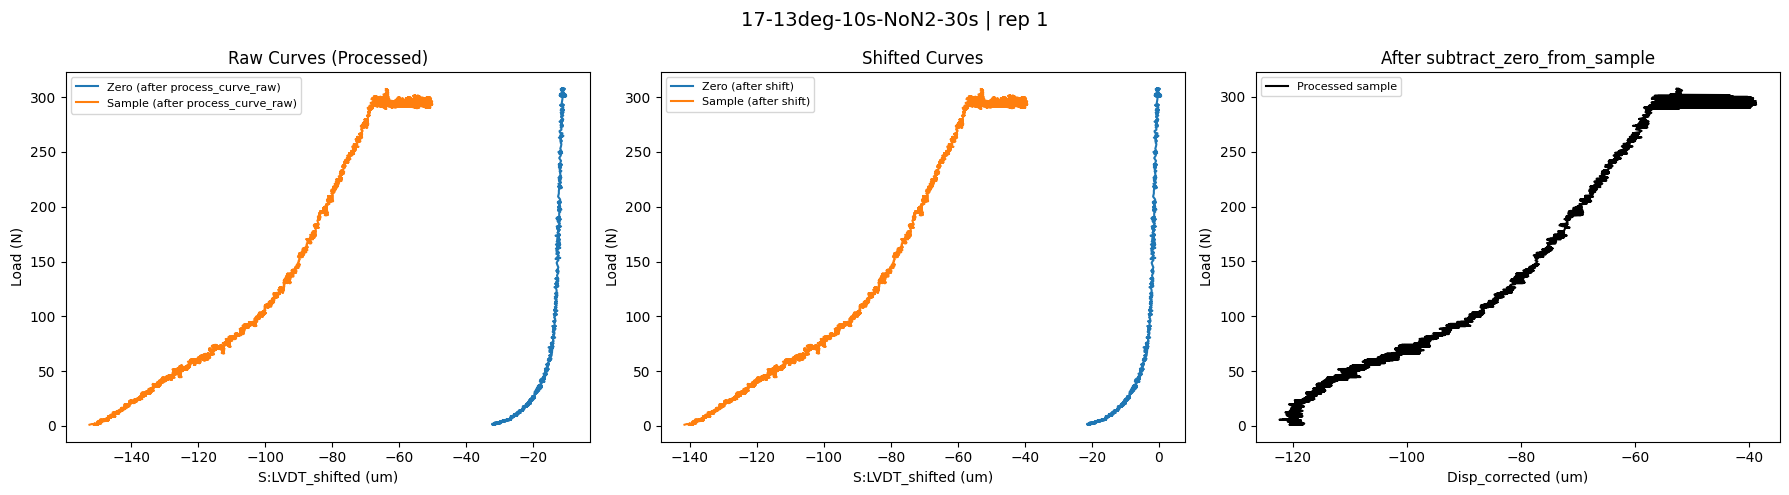

Average Standard Deviation: 54.58018795829937
Cutoff = 0.3
PW + Double: 0.03524960044440022
Piecewise Chosen! 0.024046322274612085 | Drop Calculation: 0.04598476491720862
Cutoff = 0.3
{'name': '17-13deg-10s-NoN2-30s | rep 1', 'Trial': 'sample 10', 'Thickness': np.float64(118.49099999999999), 'Elastic Modulus': np.float64(325.324486116805), 'Yield Strength': np.float64(17.01150844916016), 'Changepoint': np.float64(0.28555482234191115), 'Slope Plateau': np.float64(128.29970551856422), 'Slope Densification': np.float64(397.2160275183437), 'Creep Strain': np.float64(0.14723665038996203), 'Strain at 50 bar': 0.2502975046682572, 'Strain at 80 bar': 0.3569056454157684, 'Strain at 150 bar': 0.5316682886633308, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(54.58018795829937)}


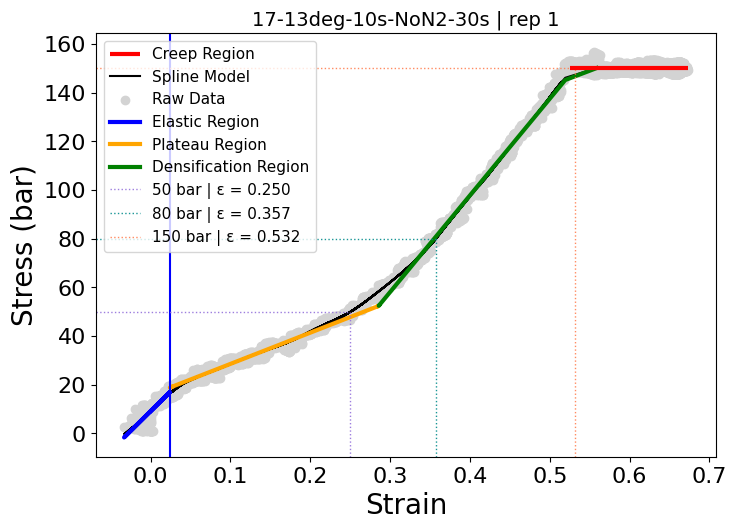

Score: 72/100 → PASS
  elastic_r2                     10/15  R²=0.698
  yield_accuracy                  7/10  |linear-GAM|=0.50 bar (3.0%)
  elastic_modulus                 5/5  E=325.3 bar
  junction_continuity             0/15  gap=10.9%
  plateau_flatness                1/5  slope/E=0.394
  plateau_r2_start                9/10  R²(first 40%)=0.877
  slope_ordering                  8/8  densif=397.2 > plateau=128.3
  densification_r2                2/2  R²=0.992
  elastic_vs_plateau             10/10  E=325.3 > slope=128.3
  breakpoint_order                5/5  bp1=0.024 < cp=0.286 < max=0.559
  densif_vs_elastic               5/5  densif/E=1.22
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=58.4 vs creep=150.2


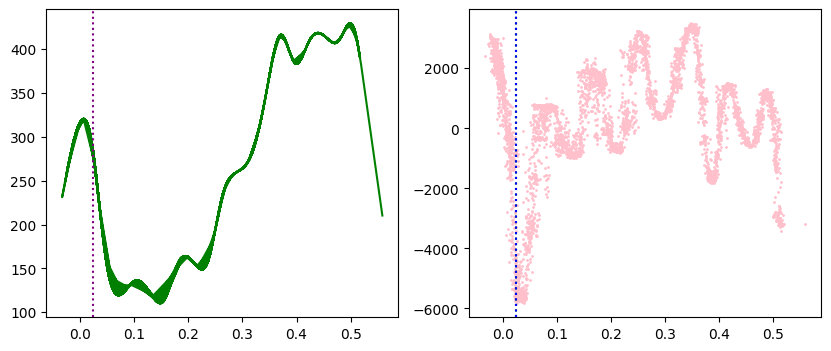

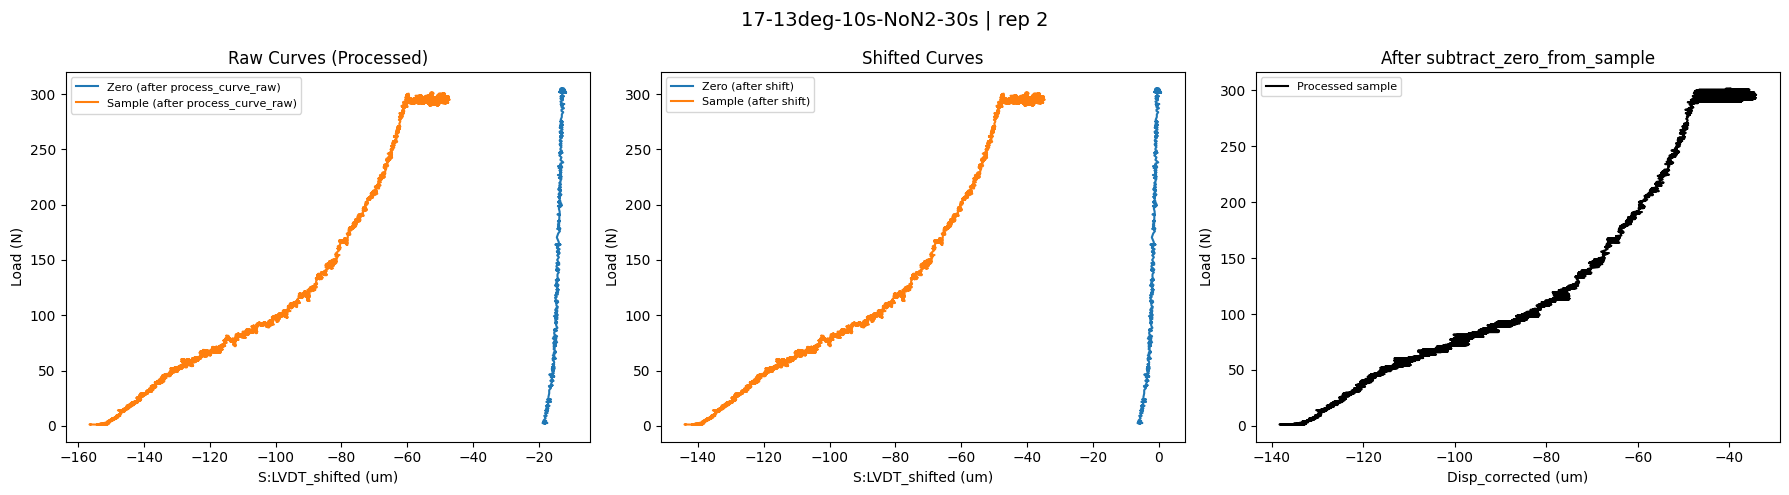

Average Standard Deviation: 53.634256682353985
Cutoff = 0.25193091354101904
PW + Double: 0.13011871415173534
Piecewise Chosen! 0.12927034284176048 | Drop Calculation: 0.12161641076940555
Cutoff = 0.25193091354101904
{'name': '17-13deg-10s-NoN2-30s | rep 2', 'Trial': 'sample 11', 'Thickness': np.float64(133.1722), 'Elastic Modulus': np.float64(187.0555680340289), 'Yield Strength': np.float64(25.576053633687422), 'Changepoint': np.float64(0.51032668631179), 'Slope Plateau': np.float64(107.79261048032214), 'Slope Densification': np.float64(623.6179148366942), 'Creep Strain': np.float64(0.09925851677425435), 'Strain at 50 bar': 0.360049641267316, 'Strain at 80 bar': 0.4928715907769331, 'Strain at 150 bar': 0.6414266641235931, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(53.634256682353985)}


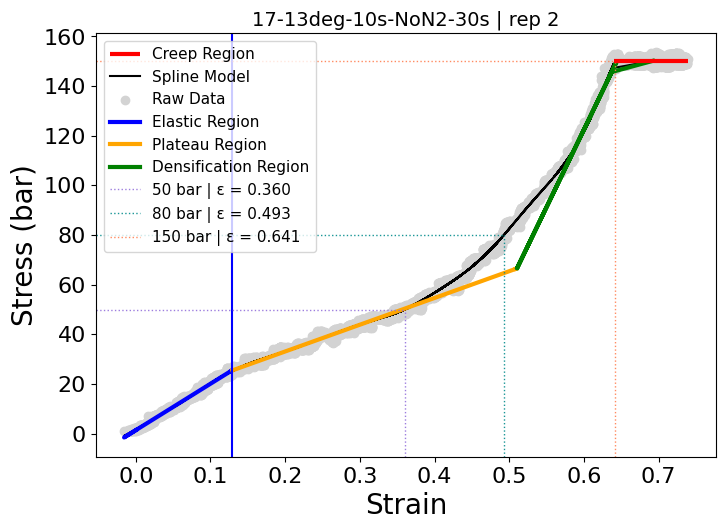

Score: 93/100 → PASS
  elastic_r2                     15/15  R²=0.988
  yield_accuracy                  9/10  |linear-GAM|=0.32 bar (1.3%)
  elastic_modulus                 5/5  E=187.1 bar
  junction_continuity            14/15  gap=0.4%
  plateau_flatness                1/5  slope/E=0.576
  plateau_r2_start                9/10  R²(first 40%)=0.949
  slope_ordering                  8/8  densif=623.6 > plateau=107.8
  densification_r2                2/2  R²=0.775
  elastic_vs_plateau             10/10  E=187.1 > slope=107.8
  breakpoint_order                5/5  bp1=0.129 < cp=0.510 < max=0.692
  densif_vs_elastic               5/5  densif/E=3.33
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=86.3 vs creep=150.2


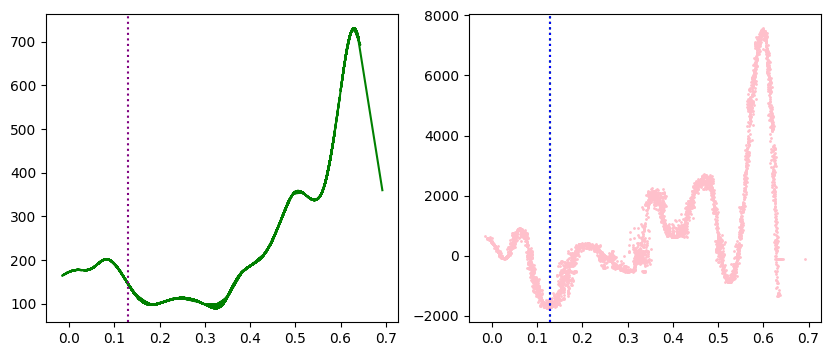

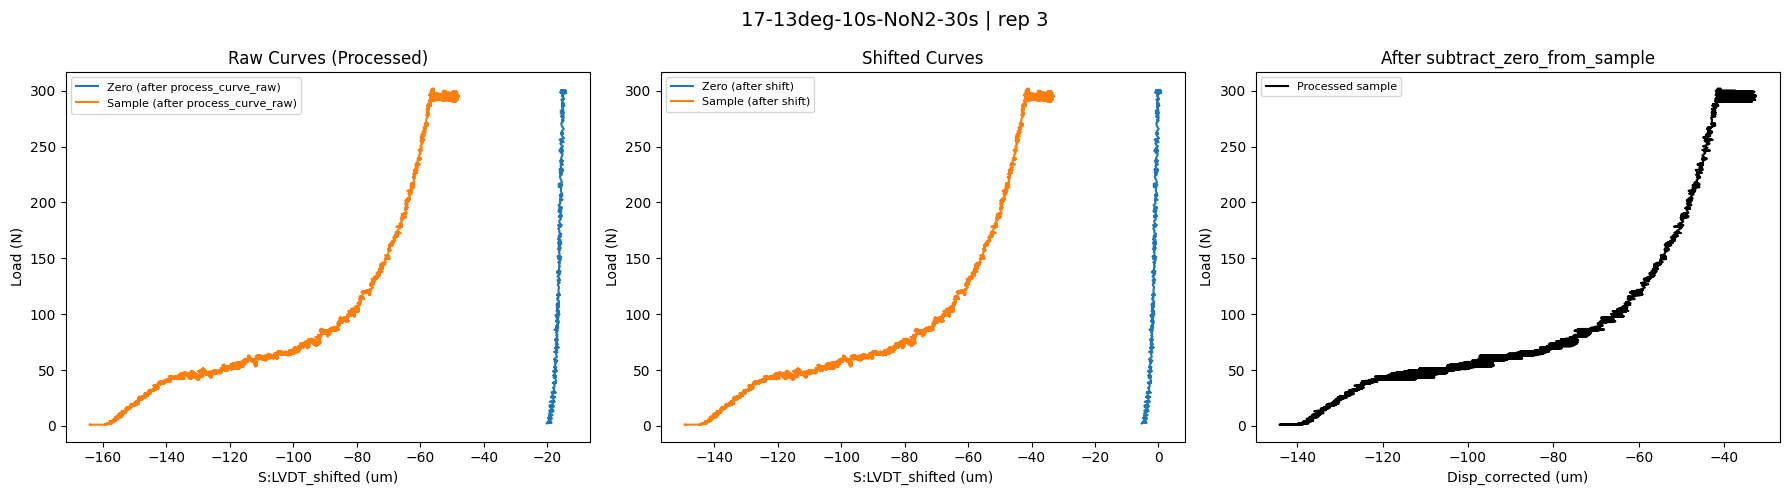

Average Standard Deviation: 57.7598379355945
Cutoff = 0.29375730994152044
PW + Double: 0.11567439818429202
Piecewise Chosen! 0.11082996621886118 | Drop Calculation: 0.11392870309506753
Cutoff = 0.29375730994152044
{'name': '17-13deg-10s-NoN2-30s | rep 3', 'Trial': 'sample 12', 'Thickness': np.float64(138.9888), 'Elastic Modulus': np.float64(174.52574872845736), 'Yield Strength': np.float64(20.518125883007833), 'Changepoint': np.float64(0.5742141296442357), 'Slope Plateau': np.float64(49.63592632120243), 'Slope Densification': np.float64(814.7795875557293), 'Creep Strain': np.float64(0.06631580873177745), 'Strain at 50 bar': 0.5218809161927742, 'Strain at 80 bar': 0.6119188702577159, 'Strain at 150 bar': 0.7017336681296844, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(57.7598379355945)}


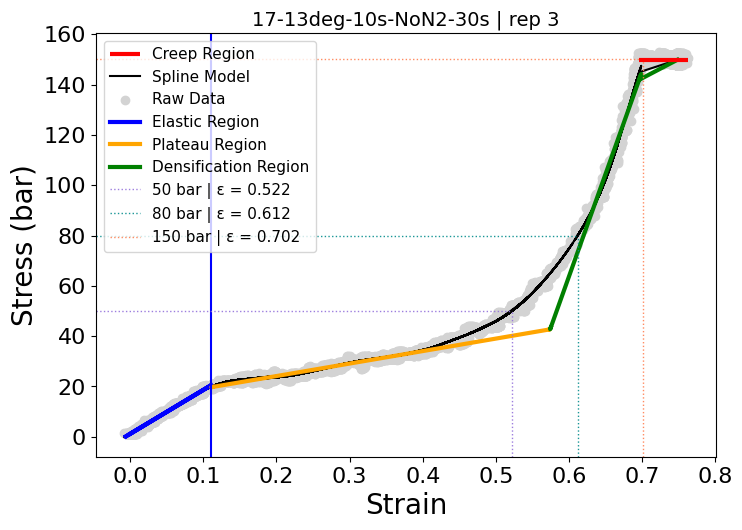

Score: 85/100 → PASS
  elastic_r2                     15/15  R²=0.986
  yield_accuracy                  7/10  |linear-GAM|=0.64 bar (3.2%)
  elastic_modulus                 5/5  E=174.5 bar
  junction_continuity             9/15  gap=3.9%
  plateau_flatness                1/5  slope/E=0.284
  plateau_r2_start                8/10  R²(first 40%)=0.814
  slope_ordering                  8/8  densif=814.8 > plateau=49.6
  densification_r2                2/2  R²=0.883
  elastic_vs_plateau             10/10  E=174.5 > slope=49.6
  breakpoint_order                5/5  bp1=0.111 < cp=0.574 < max=0.748
  densif_vs_elastic               5/5  densif/E=4.67
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=64.9 vs creep=149.9
Condition: 17-13deg-10s-NoN2-40s | pairs: 3


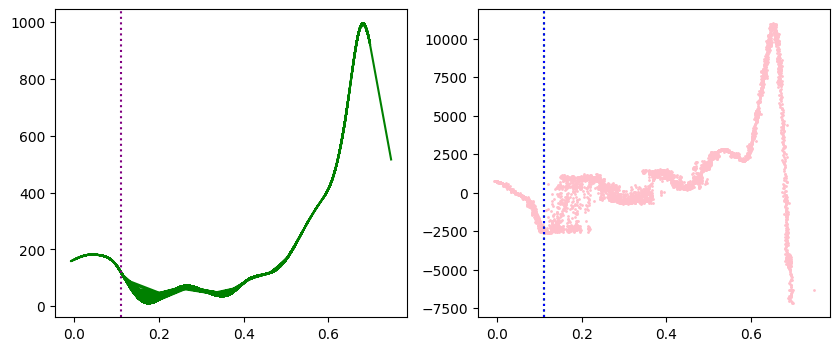

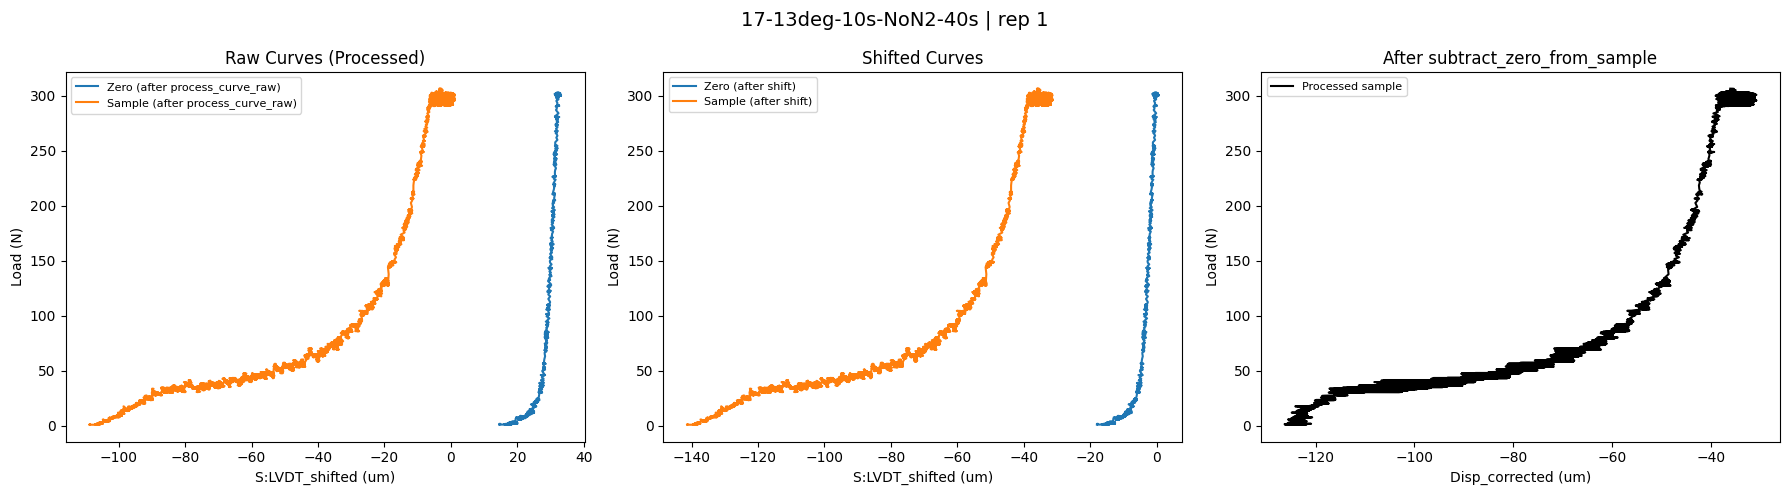

Average Standard Deviation: 60.95273249297729
Cutoff = 0.24772411836897035
PW + Double: 0.05879838702535231
Piecewise Chosen! 0.060780206327273816 | Drop Calculation: 0.10279808415381035
Cutoff = 0.24772411836897035
{'name': '17-13deg-10s-NoN2-40s | rep 1', 'Trial': 'sample 16', 'Thickness': np.float64(122.47245000000001), 'Elastic Modulus': np.float64(180.7688490265317), 'Yield Strength': np.float64(15.411330294923157), 'Changepoint': np.float64(0.578354823178592), 'Slope Plateau': np.float64(32.481498247272825), 'Slope Densification': np.float64(985.7633728840874), 'Creep Strain': np.float64(0.06532897806812876), 'Strain at 50 bar': 0.5460086778834308, 'Strain at 80 bar': 0.6240278018658139, 'Strain at 150 bar': 0.6937120451384846, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(60.95273249297729)}


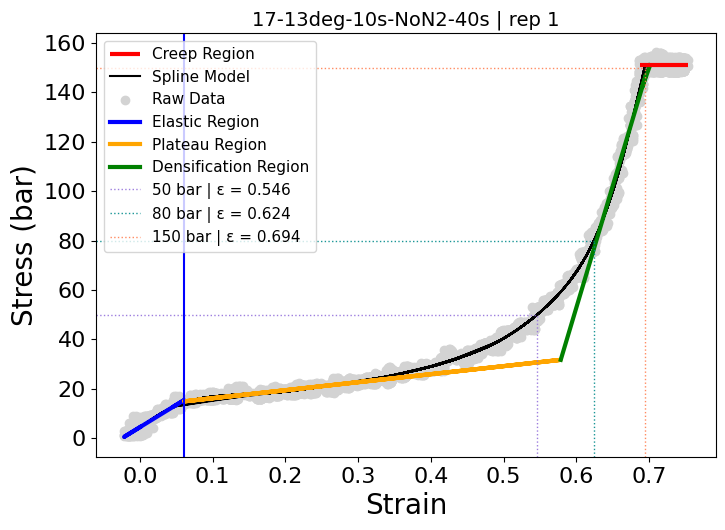

Score: 80/100 → PASS
  elastic_r2                     13/15  R²=0.857
  yield_accuracy                  3/10  |linear-GAM|=0.99 bar (6.8%)
  elastic_modulus                 5/5  E=180.8 bar
  junction_continuity            10/15  gap=3.3%
  plateau_flatness                2/5  slope/E=0.180
  plateau_r2_start                7/10  R²(first 40%)=0.689
  slope_ordering                  8/8  densif=985.8 > plateau=32.5
  densification_r2                2/2  R²=0.862
  elastic_vs_plateau             10/10  E=180.8 > slope=32.5
  breakpoint_order                5/5  bp1=0.061 < cp=0.578 < max=0.701
  densif_vs_elastic               5/5  densif/E=5.45
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=59.2 vs creep=150.9


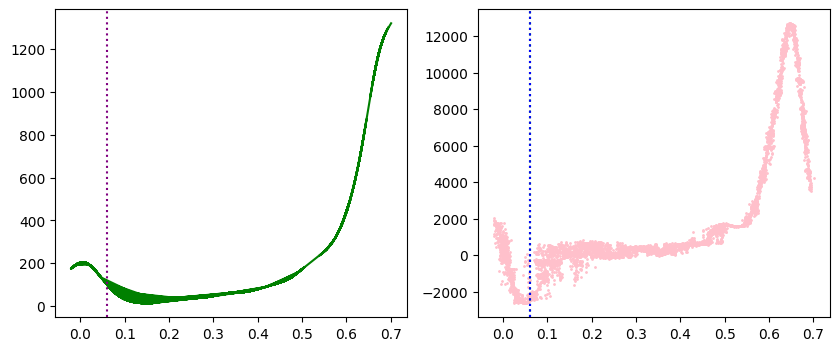

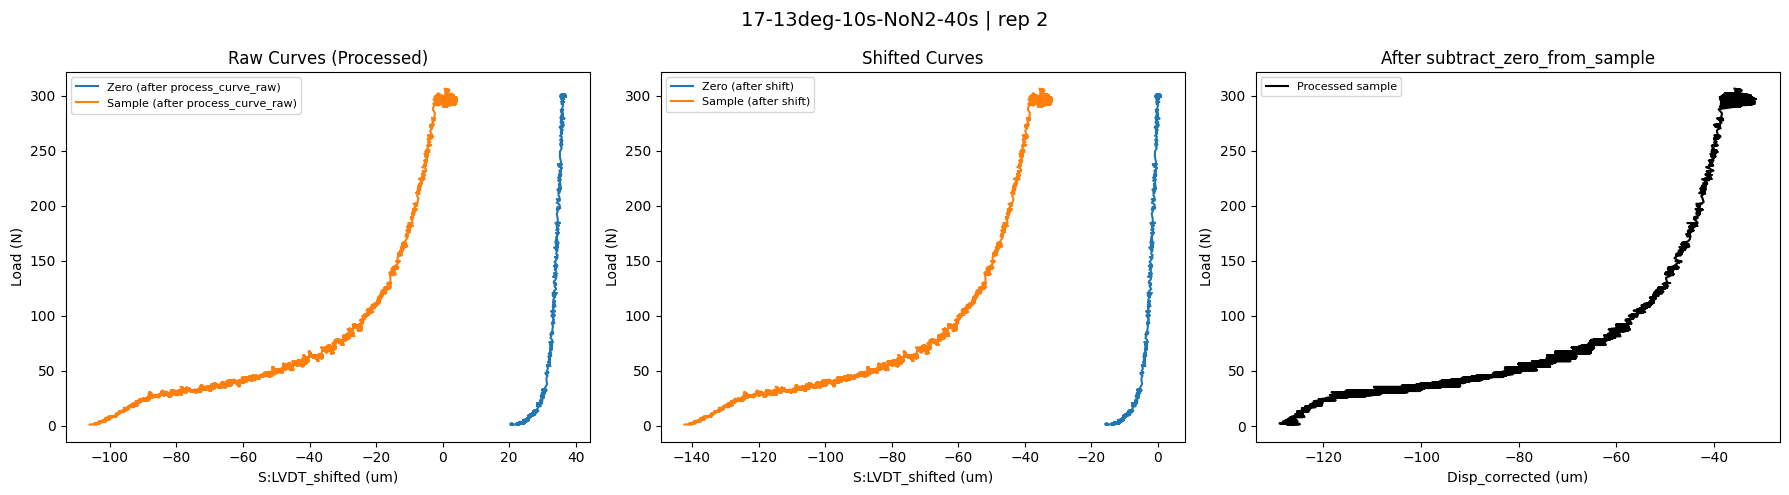

Average Standard Deviation: 60.99124154764453
Cutoff = 0.26620205951330034
PW + Double: 0.060168532721384484
Piecewise Chosen! 0.06172552308590915 | Drop Calculation: 0.05561527889673512
Cutoff = 0.26620205951330034
{'name': '17-13deg-10s-NoN2-40s | rep 2', 'Trial': 'sample 17', 'Thickness': np.float64(126.9863888256757), 'Elastic Modulus': np.float64(185.18759149649932), 'Yield Strength': np.float64(12.590792747383258), 'Changepoint': np.float64(0.5912228807343012), 'Slope Plateau': np.float64(39.652342986235446), 'Slope Densification': np.float64(948.4463789528362), 'Creep Strain': np.float64(0.05696145895995208), 'Strain at 50 bar': 0.5604903114864406, 'Strain at 80 bar': 0.6377131380314605, 'Strain at 150 bar': 0.7077206410576629, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(60.99124154764453)}


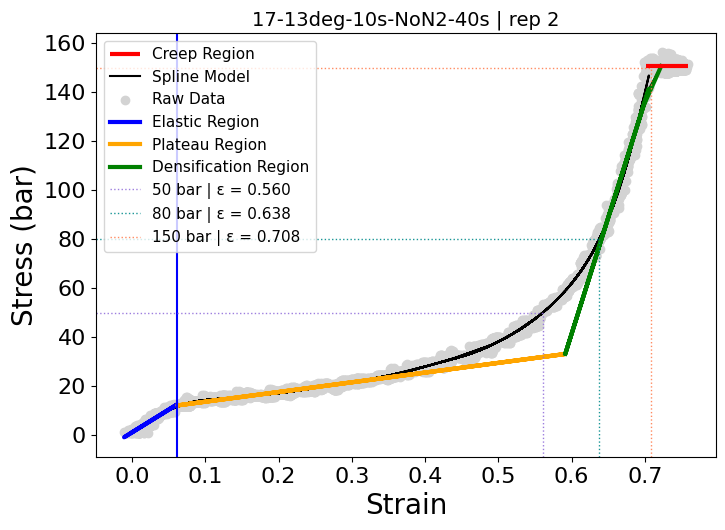

Score: 82/100 → PASS
  elastic_r2                     14/15  R²=0.921
  yield_accuracy                  2/10  |linear-GAM|=0.90 bar (7.7%)
  elastic_modulus                 5/5  E=185.2 bar
  junction_continuity            10/15  gap=3.4%
  plateau_flatness                2/5  slope/E=0.214
  plateau_r2_start                9/10  R²(first 40%)=0.872
  slope_ordering                  8/8  densif=948.4 > plateau=39.7
  densification_r2                2/2  R²=0.860
  elastic_vs_plateau             10/10  E=185.2 > slope=39.7
  breakpoint_order                5/5  bp1=0.062 < cp=0.591 < max=0.722
  densif_vs_elastic               5/5  densif/E=5.12
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=58.9 vs creep=150.6


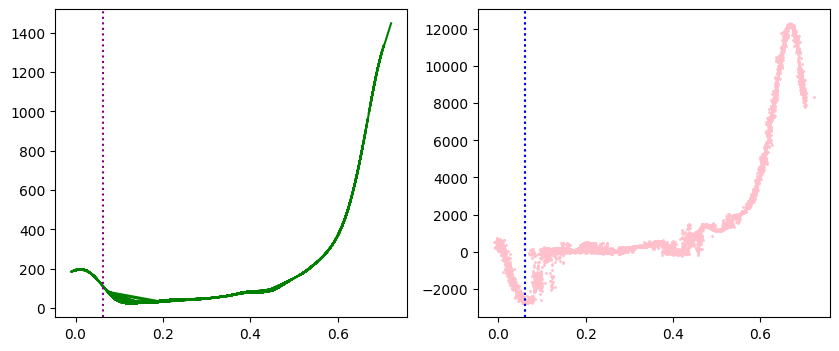

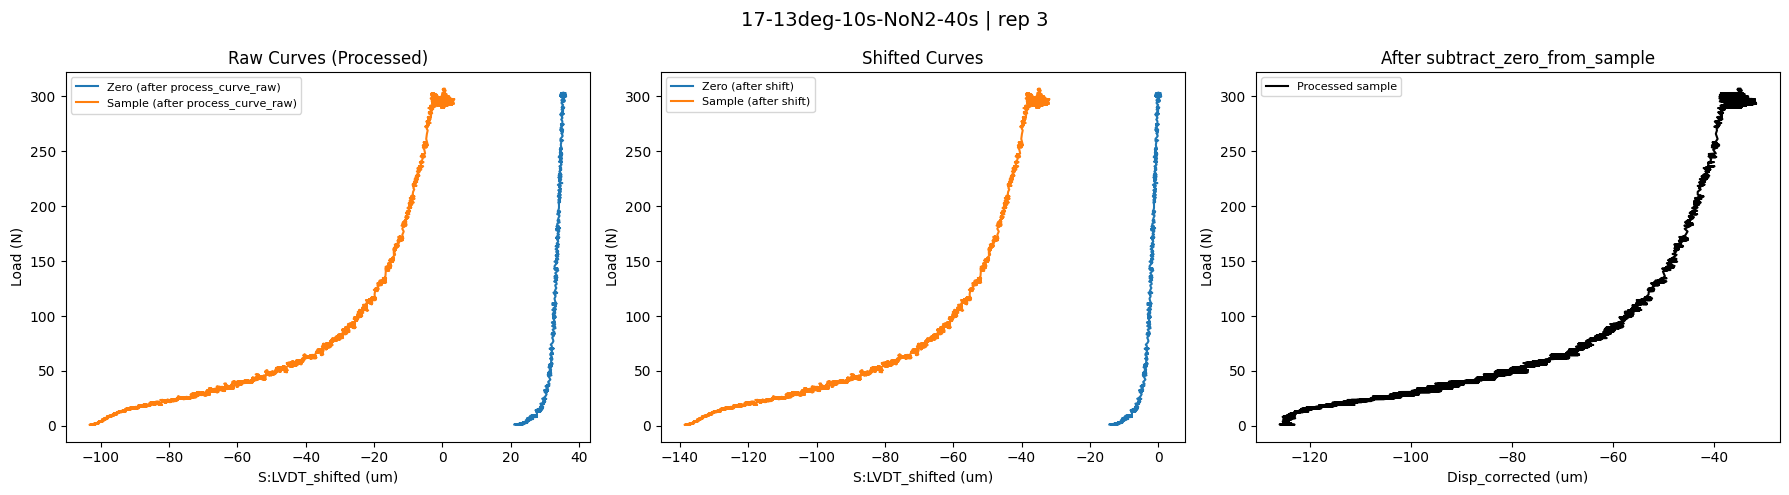

Average Standard Deviation: 61.12635132949657
Cutoff = 0.2488231185659861
PW + Double: 0.02040182367031997
Piecewise Chosen! 0.020888349075939956 | Drop Calculation: 0.027040426073179358
Cutoff = 0.2488231185659861
{'name': '17-13deg-10s-NoN2-40s | rep 3', 'Trial': 'sample 18', 'Thickness': np.float64(125.29820000000001), 'Elastic Modulus': np.float64(222.85150905647762), 'Yield Strength': np.float64(6.98601959084077), 'Changepoint': np.float64(0.5729986613626511), 'Slope Plateau': np.float64(51.44073370743427), 'Slope Densification': np.float64(915.0626540620663), 'Creep Strain': np.float64(0.05807643860397649), 'Strain at 50 bar': 0.5357953461456242, 'Strain at 80 bar': 0.6168885621327056, 'Strain at 150 bar': 0.694720705694693, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(61.12635132949657)}


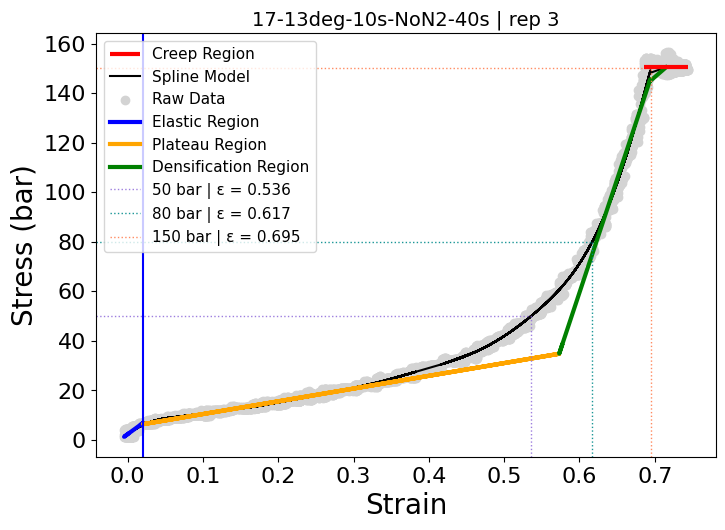

Score: 68/100 → PASS
  elastic_r2                      9/15  R²=0.625
  yield_accuracy                  0/10  |linear-GAM|=0.89 bar (14.5%)
  elastic_modulus                 5/5  E=222.9 bar
  junction_continuity             3/15  gap=8.3%
  plateau_flatness                2/5  slope/E=0.231
  plateau_r2_start                9/10  R²(first 40%)=0.950
  slope_ordering                  8/8  densif=915.1 > plateau=51.4
  densification_r2                2/2  R²=0.867
  elastic_vs_plateau             10/10  E=222.9 > slope=51.4
  breakpoint_order                5/5  bp1=0.021 < cp=0.573 < max=0.715
  densif_vs_elastic               5/5  densif/E=4.11
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=60.6 vs creep=150.4
Condition: 17-13deg-120s-NoN2-1800s | pairs: 3


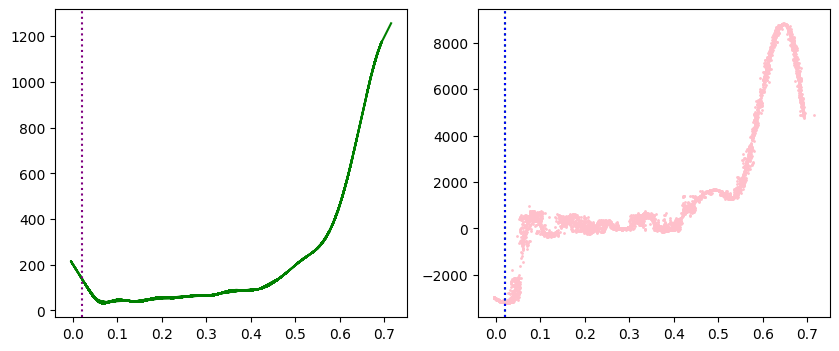

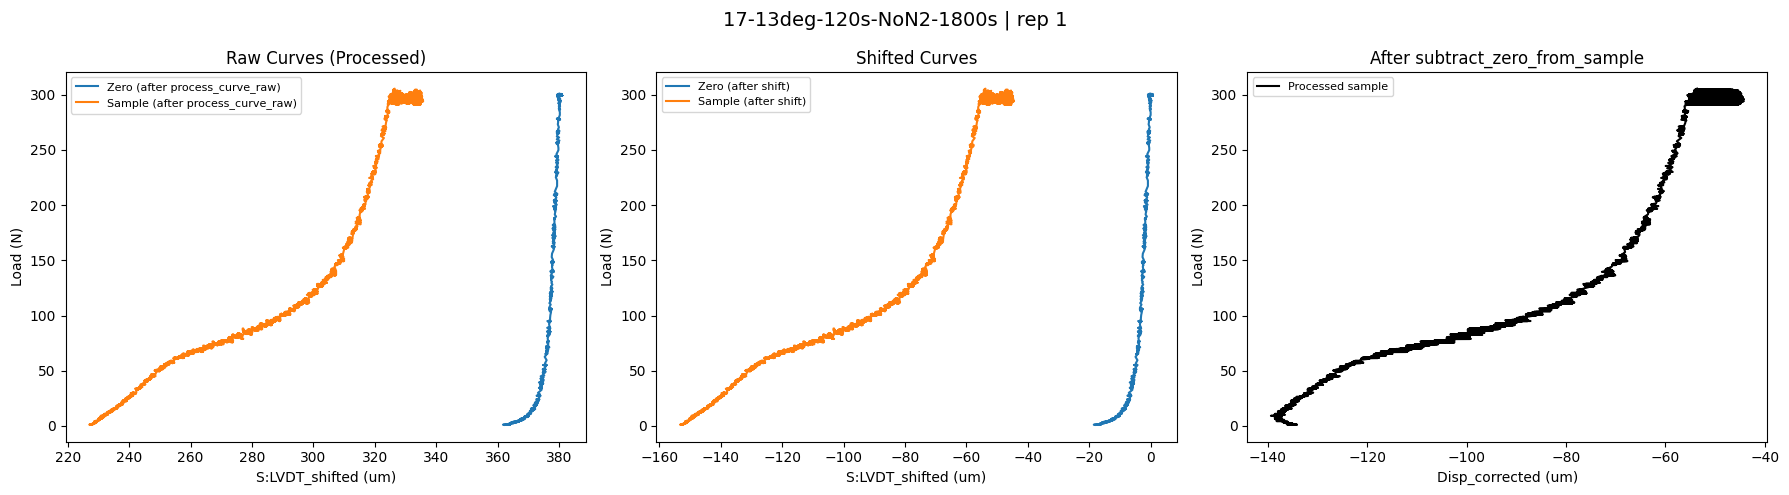

Average Standard Deviation: 55.37764259890968
Cutoff = 0.24128466497792433
PW + Double: 0.08364637429215971
Piecewise Chosen! 0.08901566811894954 | Drop Calculation: 0.11115229004526532
Cutoff = 0.24128466497792433
{'name': '17-13deg-120s-NoN2-1800s | rep 1', 'Trial': 'sample 4', 'Thickness': np.float64(134.2644), 'Elastic Modulus': np.float64(234.69353004559866), 'Yield Strength': np.float64(28.842938152429177), 'Changepoint': np.float64(0.4838813032654064), 'Slope Plateau': np.float64(73.82257917572386), 'Slope Densification': np.float64(725.6918558484136), 'Creep Strain': np.float64(0.08059023836549384), 'Strain at 50 bar': 0.35595098780244405, 'Strain at 80 bar': 0.5049586520137734, 'Strain at 150 bar': 0.6054133395715935, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(55.37764259890968)}


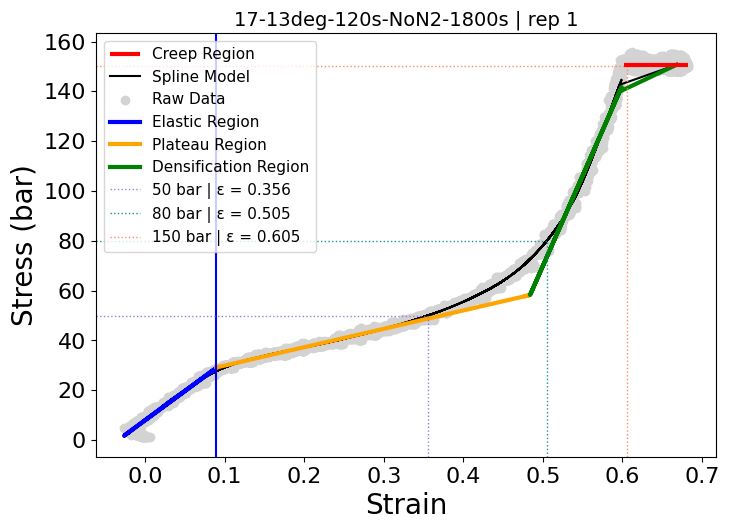

Score: 89/100 → PASS
  elastic_r2                     14/15  R²=0.957
  yield_accuracy                  5/10  |linear-GAM|=1.26 bar (4.6%)
  elastic_modulus                 5/5  E=234.7 bar
  junction_continuity            14/15  gap=0.8%
  plateau_flatness                1/5  slope/E=0.315
  plateau_r2_start               10/10  R²(first 40%)=0.960
  slope_ordering                  8/8  densif=725.7 > plateau=73.8
  densification_r2                2/2  R²=0.945
  elastic_vs_plateau             10/10  E=234.7 > slope=73.8
  breakpoint_order                5/5  bp1=0.089 < cp=0.484 < max=0.668
  densif_vs_elastic               5/5  densif/E=3.09
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=72.6 vs creep=150.7


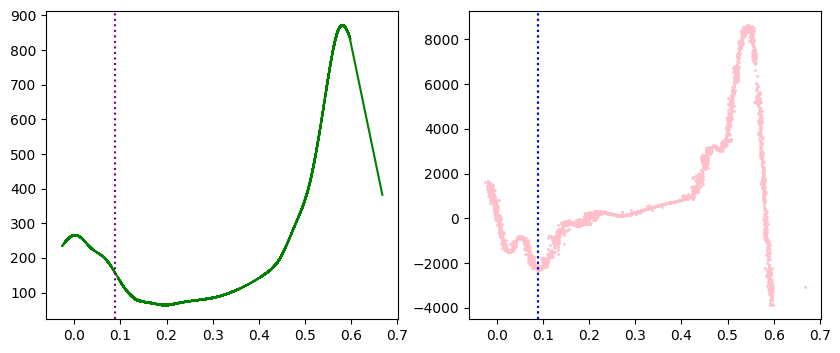

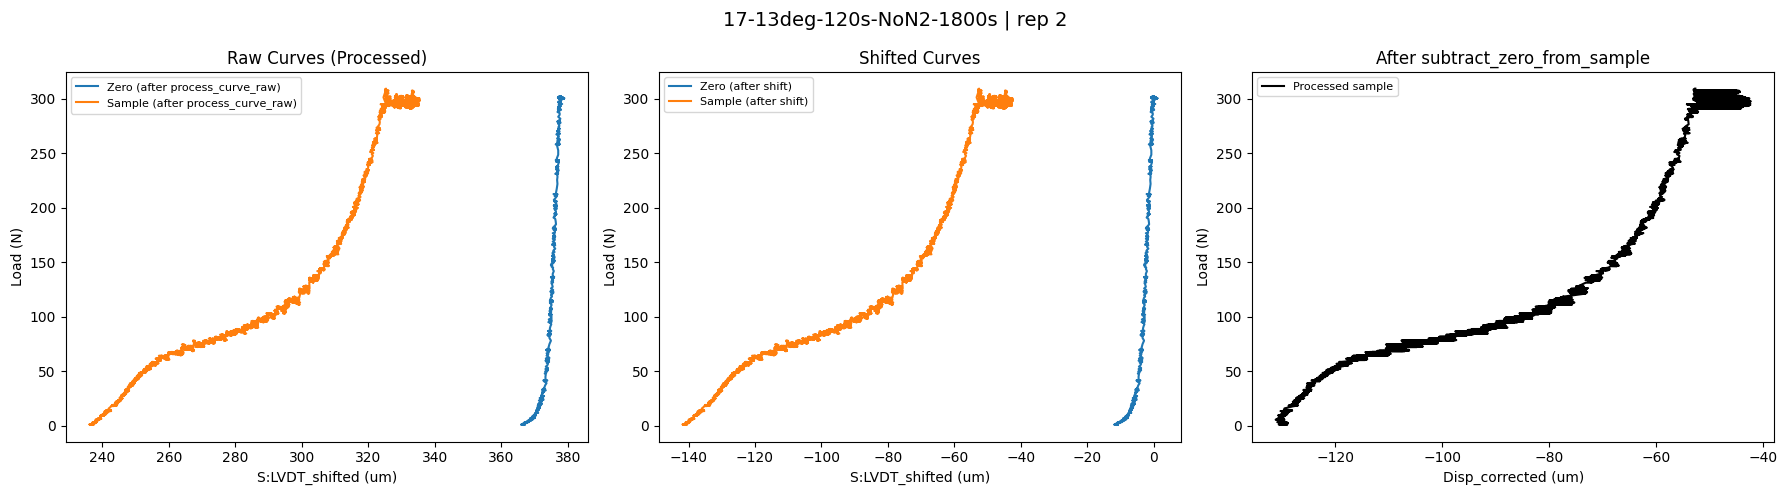

Average Standard Deviation: 53.84944972658823
Cutoff = 0.23199410534229642
PW + Double: 0.06782284024798597
Piecewise Chosen! 0.07364424599136467 | Drop Calculation: 0.08467432483753598
Cutoff = 0.23199410534229642
{'name': '17-13deg-120s-NoN2-1800s | rep 2', 'Trial': 'sample 5', 'Thickness': np.float64(129.87019999999998), 'Elastic Modulus': np.float64(325.26450161364596), 'Yield Strength': np.float64(28.356667295712345), 'Changepoint': np.float64(0.47278895275024624), 'Slope Plateau': np.float64(74.65150105075497), 'Slope Densification': np.float64(714.4471591653561), 'Creep Strain': np.float64(0.0825014372503845), 'Strain at 50 bar': 0.33841170968687573, 'Strain at 80 bar': 0.4867978552592269, 'Strain at 150 bar': 0.5971354200925193, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(53.84944972658823)}


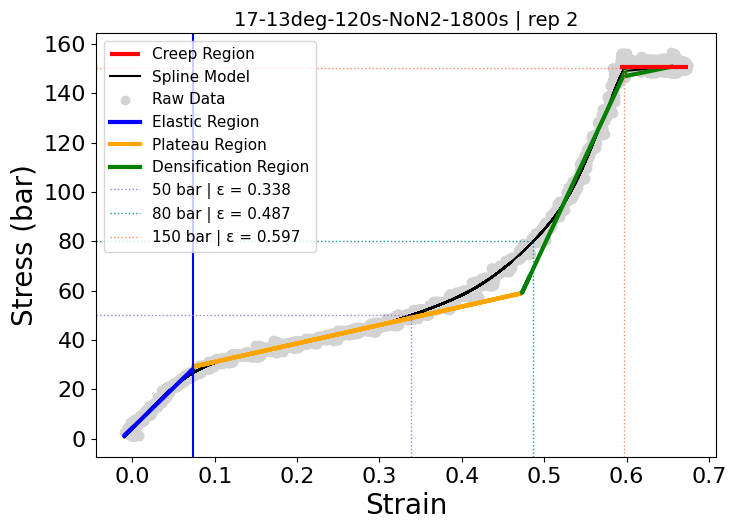

Score: 86/100 → PASS
  elastic_r2                     15/15  R²=0.969
  yield_accuracy                  4/10  |linear-GAM|=1.68 bar (6.3%)
  elastic_modulus                 5/5  E=325.3 bar
  junction_continuity            11/15  gap=2.9%
  plateau_flatness                2/5  slope/E=0.230
  plateau_r2_start                9/10  R²(first 40%)=0.922
  slope_ordering                  8/8  densif=714.4 > plateau=74.7
  densification_r2                2/2  R²=0.929
  elastic_vs_plateau             10/10  E=325.3 > slope=74.7
  breakpoint_order                5/5  bp1=0.074 < cp=0.473 < max=0.654
  densif_vs_elastic               5/5  densif/E=2.20
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=75.4 vs creep=150.7


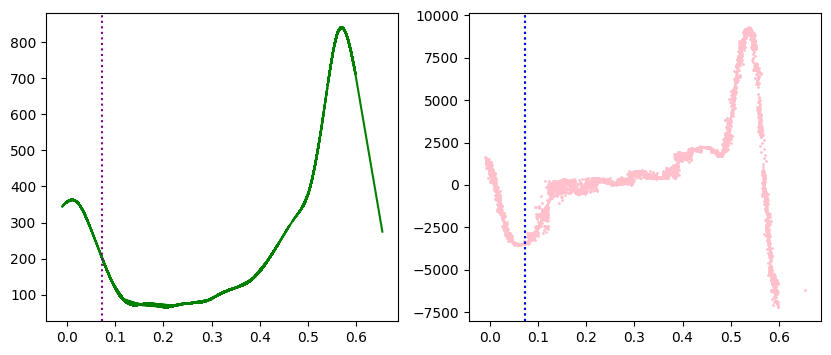

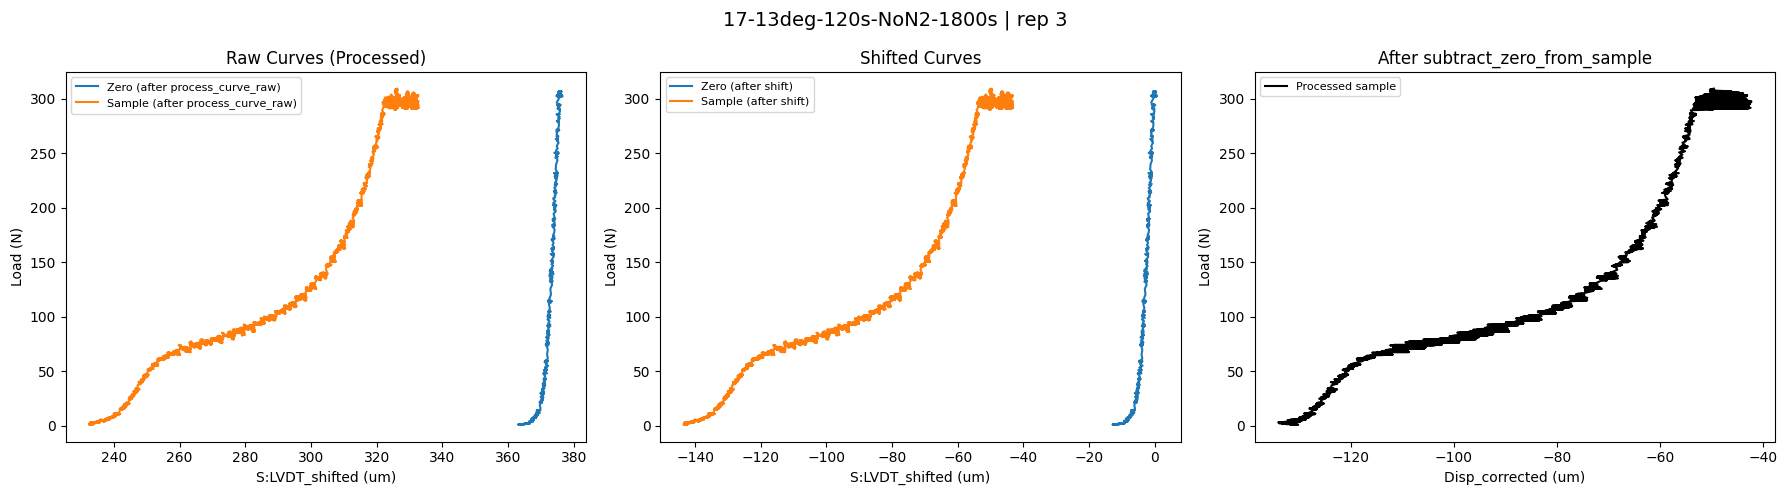

Average Standard Deviation: 54.896711781685454
Cutoff = 0.195937584656454
PW + Double: 0.10624642049160173
Piecewise Chosen! 0.11436290445839205 | Drop Calculation: 0.12088320149542202
Cutoff = 0.195937584656454
{'name': '17-13deg-120s-NoN2-1800s | rep 3', 'Trial': 'sample 6', 'Thickness': np.float64(130.9624), 'Elastic Modulus': np.float64(291.4979558264823), 'Yield Strength': np.float64(31.962454720339057), 'Changepoint': np.float64(0.4957719517634676), 'Slope Plateau': np.float64(69.00549865879239), 'Slope Densification': np.float64(803.2800645632137), 'Creep Strain': np.float64(0.08496114667339993), 'Strain at 50 bar': 0.3556170946178462, 'Strain at 80 bar': 0.5037127341239057, 'Strain at 150 bar': 0.6058575441265289, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(54.896711781685454)}


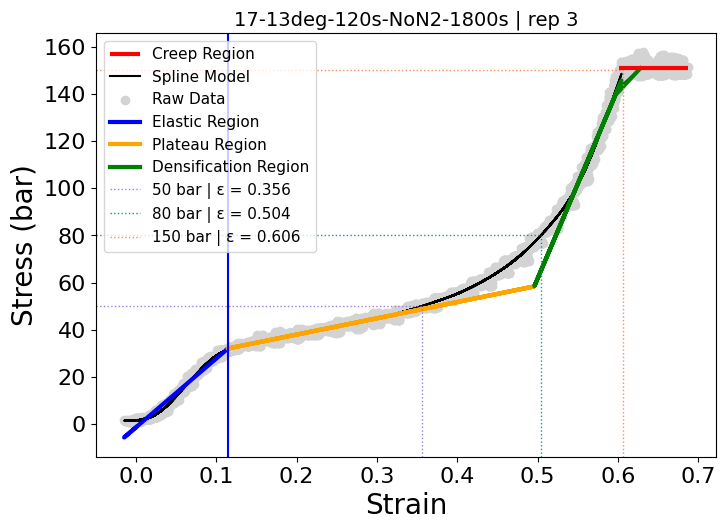

Score: 93/100 → PASS
  elastic_r2                     14/15  R²=0.960
  yield_accuracy                  9/10  |linear-GAM|=0.35 bar (1.1%)
  elastic_modulus                 5/5  E=291.5 bar
  junction_continuity            14/15  gap=0.3%
  plateau_flatness                2/5  slope/E=0.237
  plateau_r2_start                9/10  R²(first 40%)=0.914
  slope_ordering                  8/8  densif=803.3 > plateau=69.0
  densification_r2                2/2  R²=0.895
  elastic_vs_plateau             10/10  E=291.5 > slope=69.0
  breakpoint_order                5/5  bp1=0.114 < cp=0.496 < max=0.628
  densif_vs_elastic               5/5  densif/E=2.76
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=77.0 vs creep=150.8
Condition: 17-13deg-120s-NoN2-1900s | pairs: 3


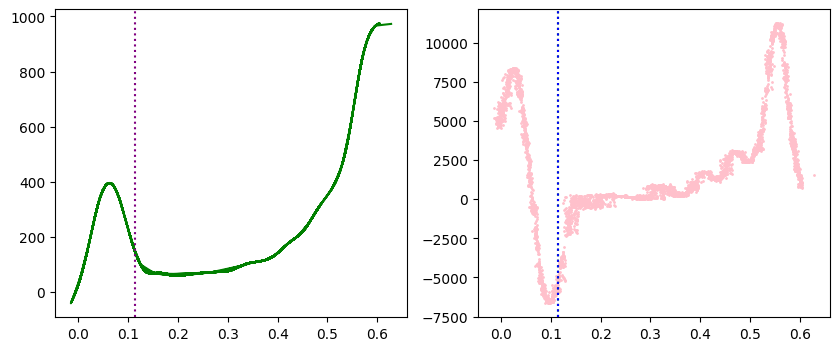

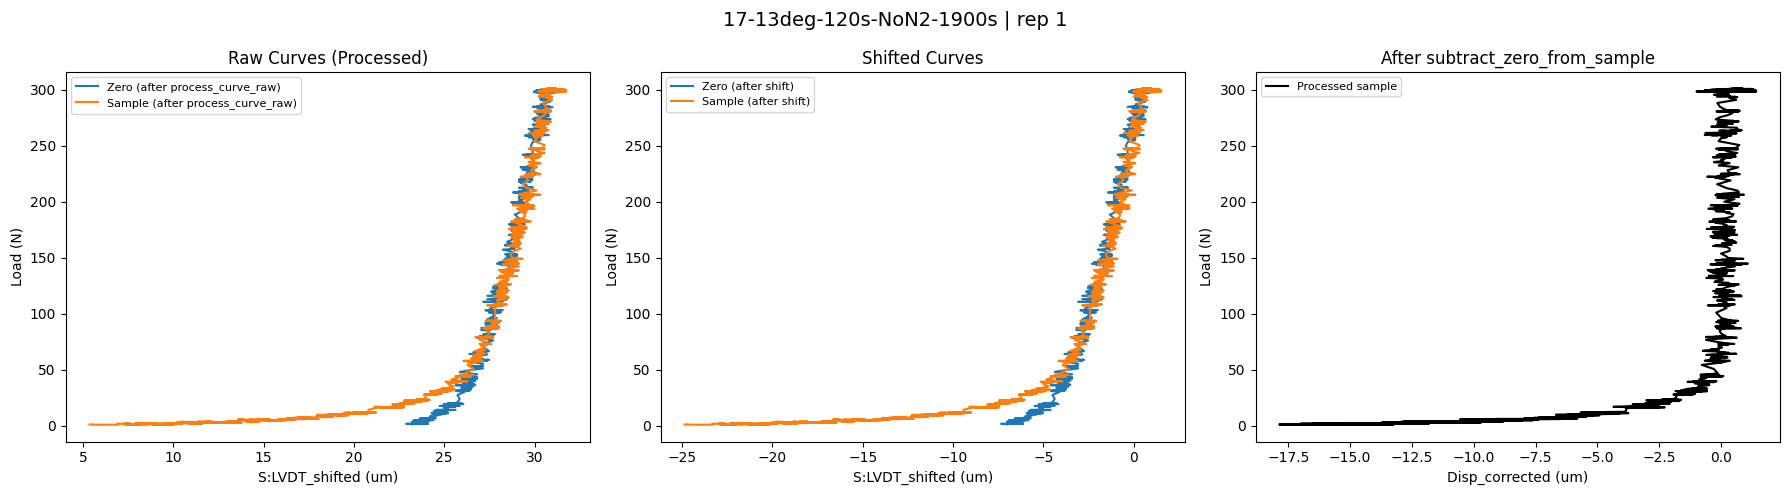

Average Standard Deviation: 51.34696841512007
Skipping GAM for 17-13deg-120s-NoN2-1900s | rep 1 (thickness=17.2 µm — no membrane)


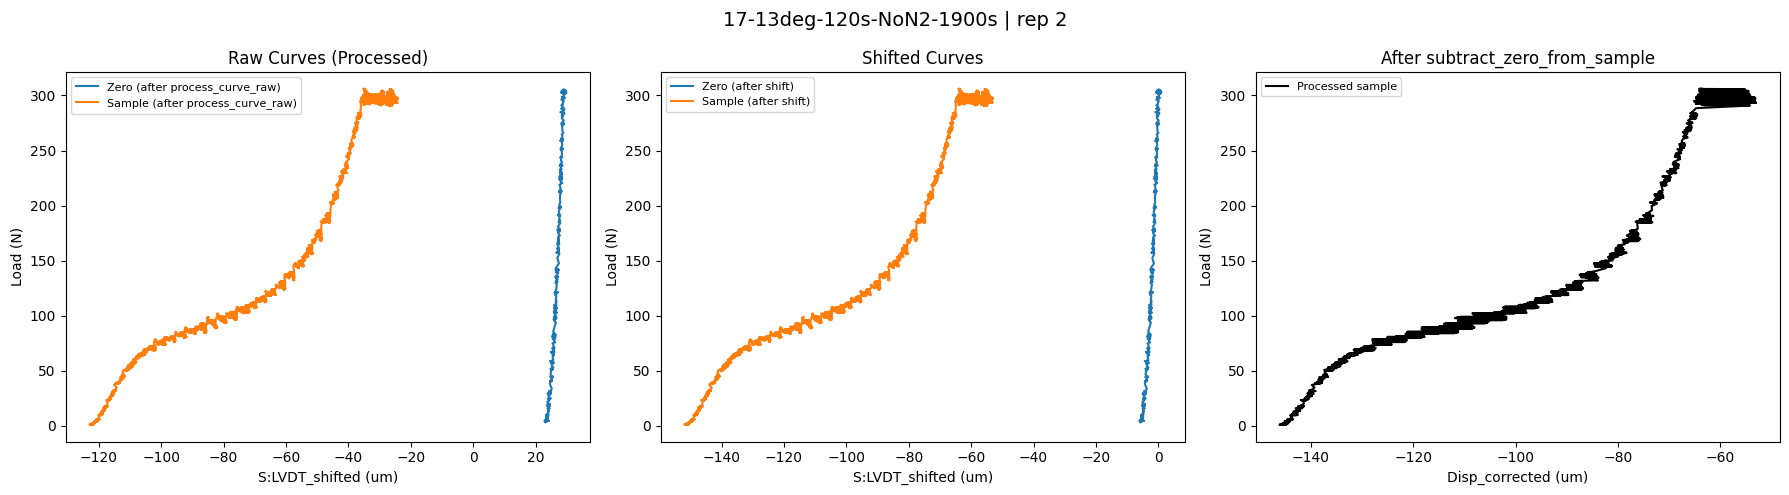

Average Standard Deviation: 51.39437127959587
Cutoff = 0.2208999949656782
PW + Double: 0.07431644588189931
Piecewise Chosen! 0.07756089553723866 | Drop Calculation: 0.08662663075592773
Cutoff = 0.2208999949656782
{'name': '17-13deg-120s-NoN2-1900s | rep 2', 'Trial': 'sample 5', 'Thickness': np.float64(145.1102), 'Elastic Modulus': np.float64(400.26532041383985), 'Yield Strength': np.float64(32.872428960373625), 'Changepoint': np.float64(0.4318549080640577), 'Slope Plateau': np.float64(81.98017358655483), 'Slope Densification': np.float64(659.7874147253804), 'Creep Strain': np.float64(0.07746547297980255), 'Strain at 50 bar': 0.2706067075269575, 'Strain at 80 bar': 0.44330941020913794, 'Strain at 150 bar': 0.5594547558370812, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(51.39437127959587)}


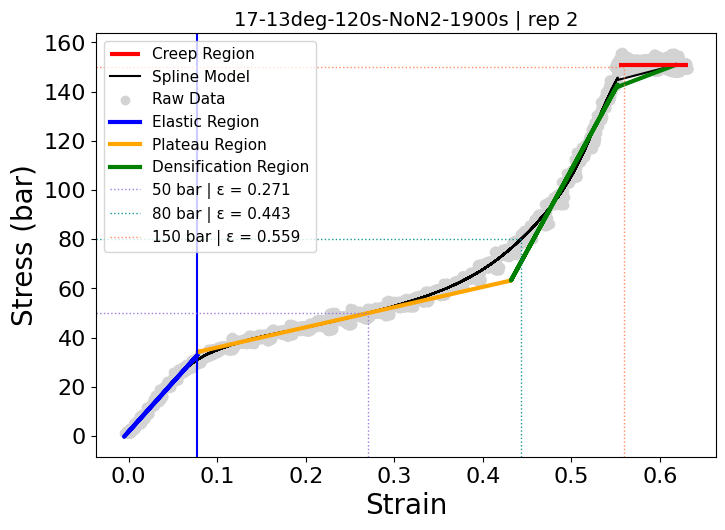

Score: 84/100 → PASS
  elastic_r2                     15/15  R²=0.985
  yield_accuracy                  4/10  |linear-GAM|=1.86 bar (6.0%)
  elastic_modulus                 5/5  E=400.3 bar
  junction_continuity             9/15  gap=3.9%
  plateau_flatness                2/5  slope/E=0.205
  plateau_r2_start                9/10  R²(first 40%)=0.891
  slope_ordering                  8/8  densif=659.8 > plateau=82.0
  densification_r2                2/2  R²=0.945
  elastic_vs_plateau             10/10  E=400.3 > slope=82.0
  breakpoint_order                5/5  bp1=0.078 < cp=0.432 < max=0.617
  densif_vs_elastic               5/5  densif/E=1.65
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=76.3 vs creep=150.8


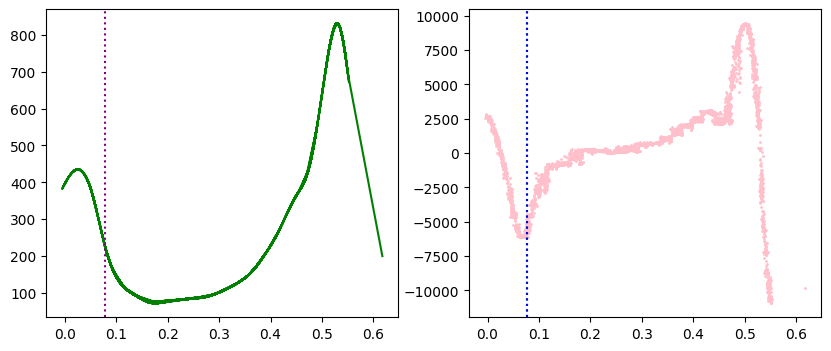

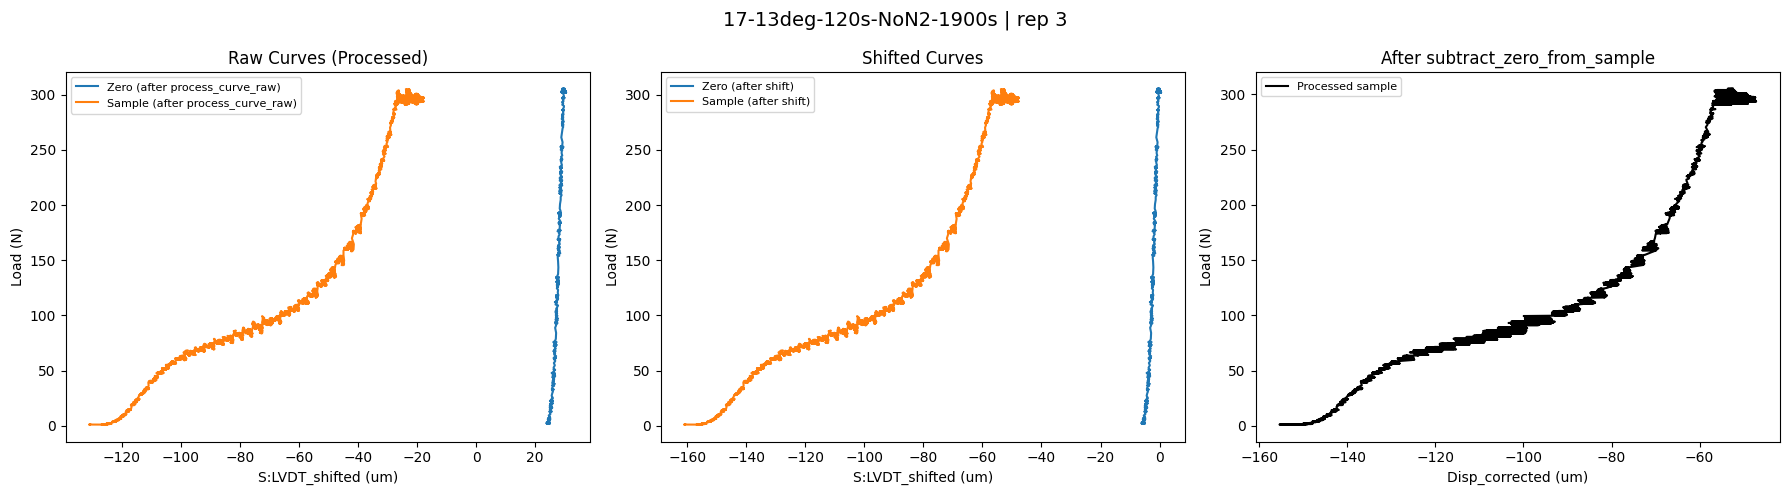

Average Standard Deviation: 54.07868413541773
Cutoff = 0.20013243042456325
PW + Double: 0.11789732378155618
Piecewise Chosen! 0.12102935236409675 | Drop Calculation: 0.12354090413954613
Cutoff = 0.20013243042456325
{'name': '17-13deg-120s-NoN2-1900s | rep 3', 'Trial': 'sample 6', 'Thickness': np.float64(149.91080000000002), 'Elastic Modulus': np.float64(247.8833511391556), 'Yield Strength': np.float64(28.275952165748688), 'Changepoint': np.float64(0.505180429798224), 'Slope Plateau': np.float64(84.38946000796739), 'Slope Densification': np.float64(751.4530843296126), 'Creep Strain': np.float64(0.06306854699204167), 'Strain at 50 bar': 0.36711391974552243, 'Strain at 80 bar': 0.5110718745364391, 'Strain at 150 bar': 0.6192500900000677, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(54.07868413541773)}


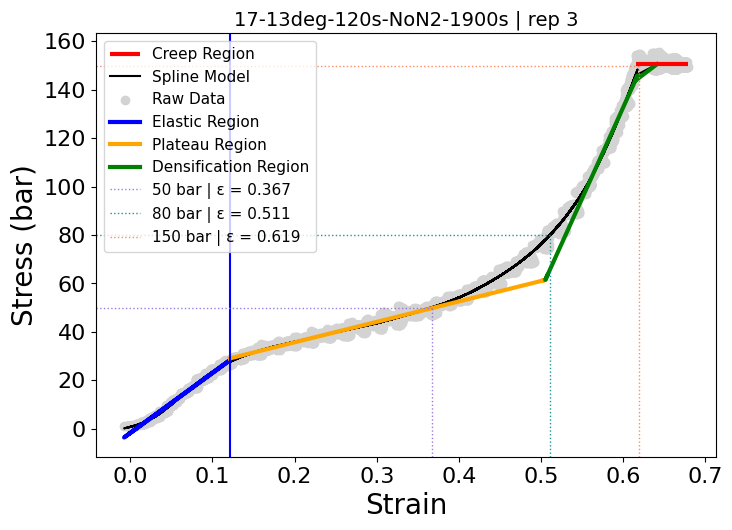

Score: 88/100 → PASS
  elastic_r2                     15/15  R²=0.987
  yield_accuracy                  7/10  |linear-GAM|=0.69 bar (2.5%)
  elastic_modulus                 5/5  E=247.9 bar
  junction_continuity            11/15  gap=2.7%
  plateau_flatness                1/5  slope/E=0.340
  plateau_r2_start                9/10  R²(first 40%)=0.934
  slope_ordering                  8/8  densif=751.5 > plateau=84.4
  densification_r2                2/2  R²=0.905
  elastic_vs_plateau             10/10  E=247.9 > slope=84.4
  breakpoint_order                5/5  bp1=0.121 < cp=0.505 < max=0.641
  densif_vs_elastic               5/5  densif/E=3.03
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=77.9 vs creep=150.5
Condition: 17-13deg-15s-NoN2-30s | pairs: 3


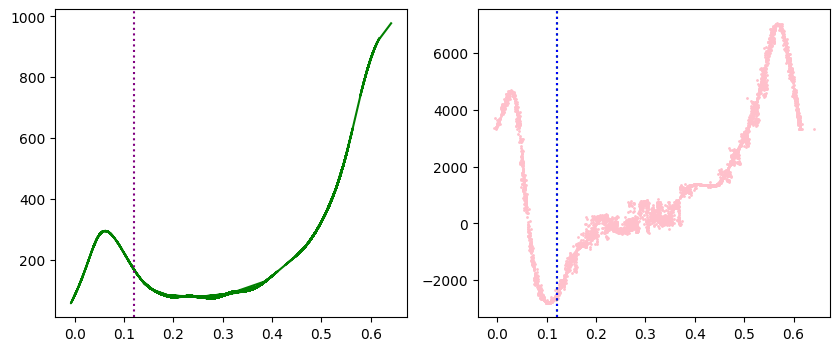

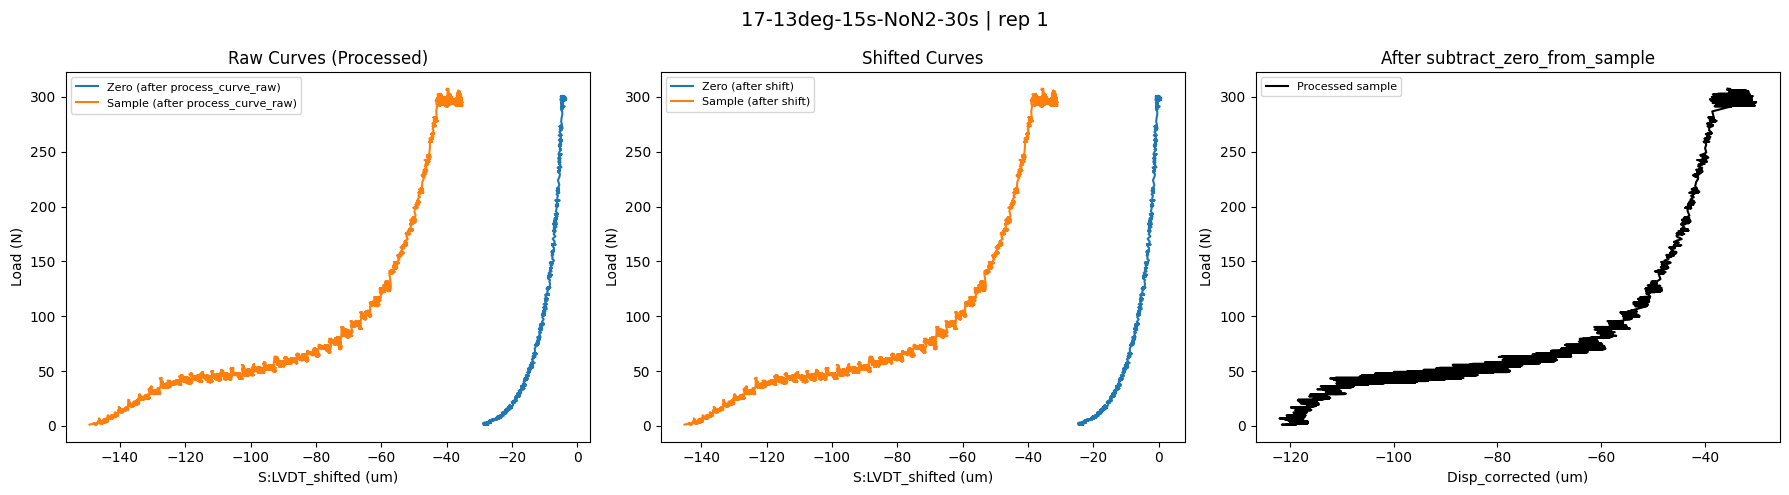

Average Standard Deviation: 59.86672153100582
Cutoff = 0.2252951609110191
PW + Double: 0.06477283023727408
Piecewise Chosen! 0.0702663867067874 | Drop Calculation: 0.09794309373997827
Cutoff = 0.2252951609110191
{'name': '17-13deg-15s-NoN2-30s | rep 1', 'Trial': 'sample 4', 'Thickness': np.float64(118.91932820308608), 'Elastic Modulus': np.float64(195.3665186329285), 'Yield Strength': np.float64(19.943025998553928), 'Changepoint': np.float64(0.548380045075711), 'Slope Plateau': np.float64(27.468915333274655), 'Slope Densification': np.float64(920.9765963429446), 'Creep Strain': np.float64(0.07103967400843081), 'Strain at 50 bar': 0.5235708559666077, 'Strain at 80 bar': 0.5980717945125391, 'Strain at 150 bar': 0.6703876919459517, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(59.86672153100582)}


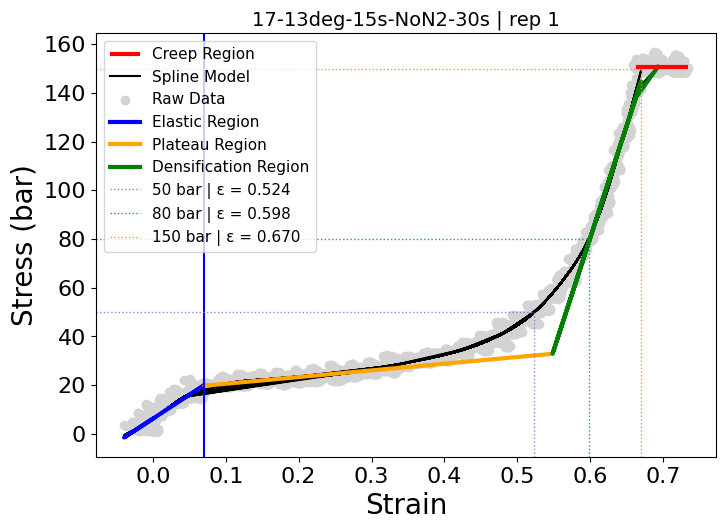

Score: 82/100 → PASS
  elastic_r2                     13/15  R²=0.849
  yield_accuracy                  3/10  |linear-GAM|=1.26 bar (6.7%)
  elastic_modulus                 5/5  E=195.4 bar
  junction_continuity            14/15  gap=1.0%
  plateau_flatness                2/5  slope/E=0.141
  plateau_r2_start                5/10  R²(first 40%)=0.526
  slope_ordering                  8/8  densif=921.0 > plateau=27.5
  densification_r2                2/2  R²=0.879
  elastic_vs_plateau             10/10  E=195.4 > slope=27.5
  breakpoint_order                5/5  bp1=0.070 < cp=0.548 < max=0.693
  densif_vs_elastic               5/5  densif/E=4.71
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=57.7 vs creep=150.7


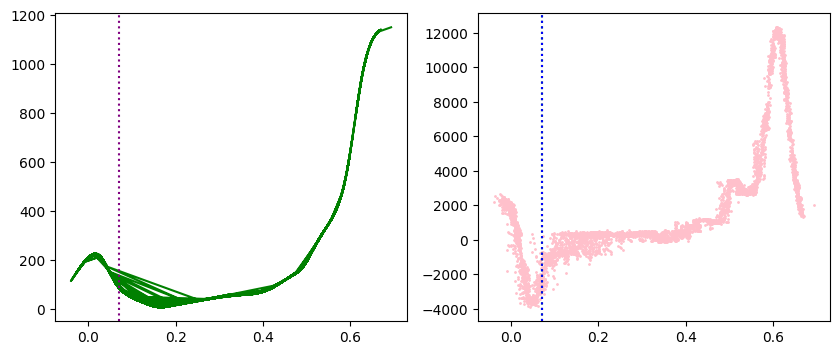

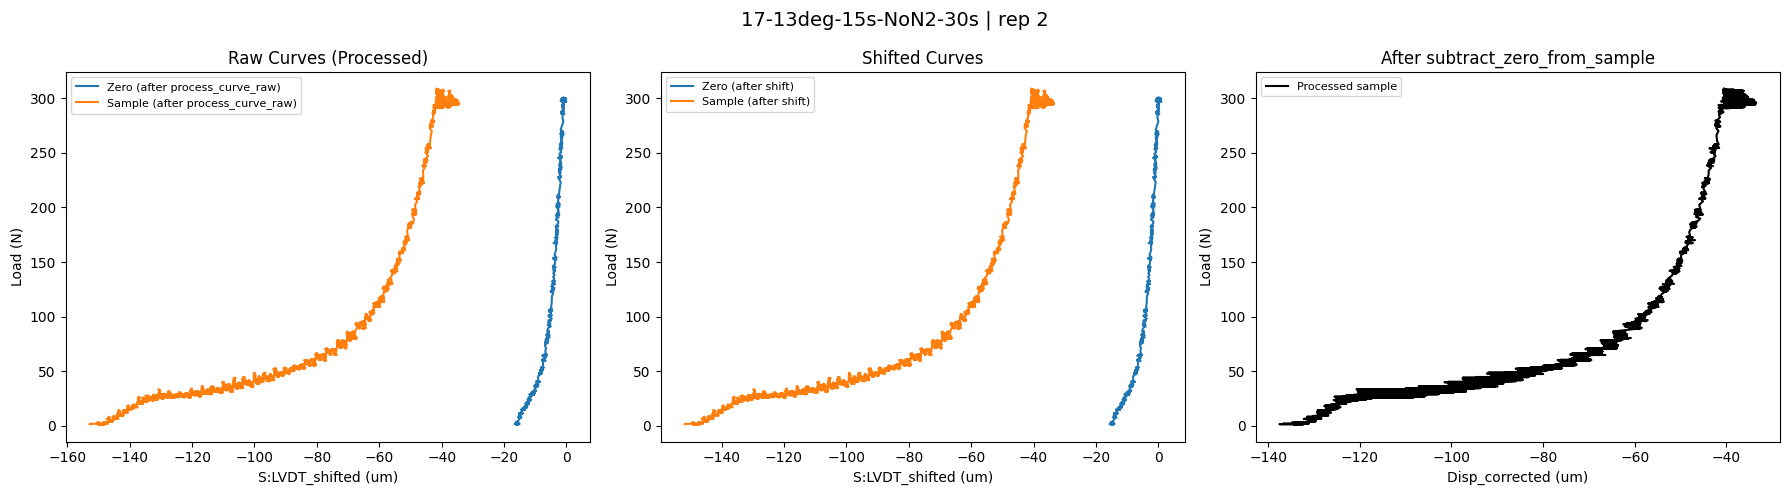

Average Standard Deviation: 61.47696987010362
Cutoff = 0.2545627376425855
PW + Double: 0.08244004660852439
Piecewise Chosen! 0.0797598283060672 | Drop Calculation: 0.09217089330302672
Cutoff = 0.2545627376425855
{'name': '17-13deg-15s-NoN2-30s | rep 2', 'Trial': 'sample 5', 'Thickness': np.float64(133.60399999999998), 'Elastic Modulus': np.float64(158.78181645075543), 'Yield Strength': np.float64(12.710933554325326), 'Changepoint': np.float64(0.5750284808883032), 'Slope Plateau': np.float64(33.979968873072806), 'Slope Densification': np.float64(1010.7932805678616), 'Creep Strain': np.float64(0.055296686721845956), 'Strain at 50 bar': 0.5548109571209644, 'Strain at 80 bar': 0.6231344774391403, 'Strain at 150 bar': 0.689443380925618, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(61.47696987010362)}


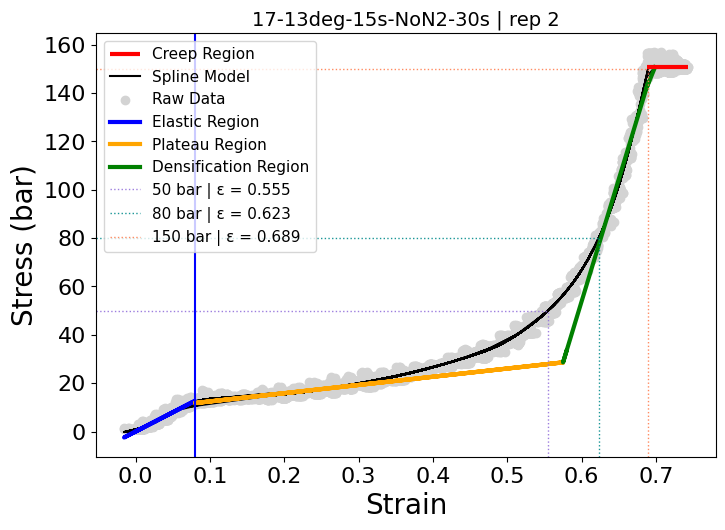

Score: 79/100 → PASS
  elastic_r2                     14/15  R²=0.928
  yield_accuracy                  7/10  |linear-GAM|=0.38 bar (3.0%)
  elastic_modulus                 5/5  E=158.8 bar
  junction_continuity             4/15  gap=7.2%
  plateau_flatness                2/5  slope/E=0.214
  plateau_r2_start                7/10  R²(first 40%)=0.714
  slope_ordering                  8/8  densif=1010.8 > plateau=34.0
  densification_r2                2/2  R²=0.855
  elastic_vs_plateau             10/10  E=158.8 > slope=34.0
  breakpoint_order                5/5  bp1=0.080 < cp=0.575 < max=0.699
  densif_vs_elastic               5/5  densif/E=6.37
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=56.4 vs creep=150.7


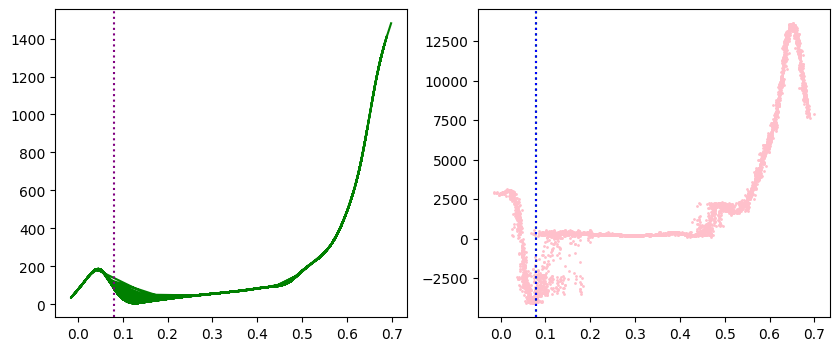

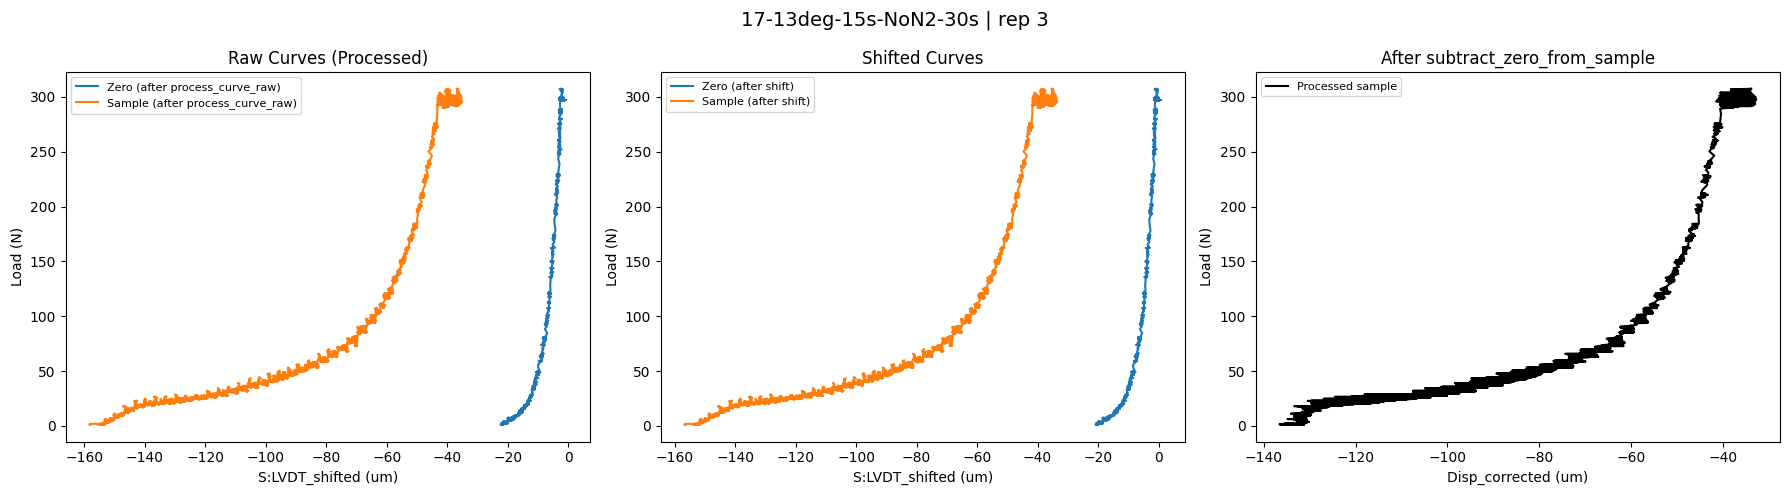

Average Standard Deviation: 62.127039661034495
Cutoff = 0.27584683869135185
PW + Double: 0.06279162633113645
Piecewise Chosen! 0.060882017188850786 | Drop Calculation: 0.06068194952802941
Cutoff = 0.27584683869135185
{'name': '17-13deg-15s-NoN2-30s | rep 3', 'Trial': 'sample 6', 'Thickness': np.float64(131.85139999999998), 'Elastic Modulus': np.float64(167.31576998308037), 'Yield Strength': np.float64(9.334561031545046), 'Changepoint': np.float64(0.6060663792835232), 'Slope Plateau': np.float64(37.64988113630532), 'Slope Densification': np.float64(989.6685076797545), 'Creep Strain': np.float64(0.0625439766910002), 'Strain at 50 bar': 0.5881568840859468, 'Strain at 80 bar': 0.6566309987651802, 'Strain at 150 bar': 0.722562945691424, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(62.127039661034495)}


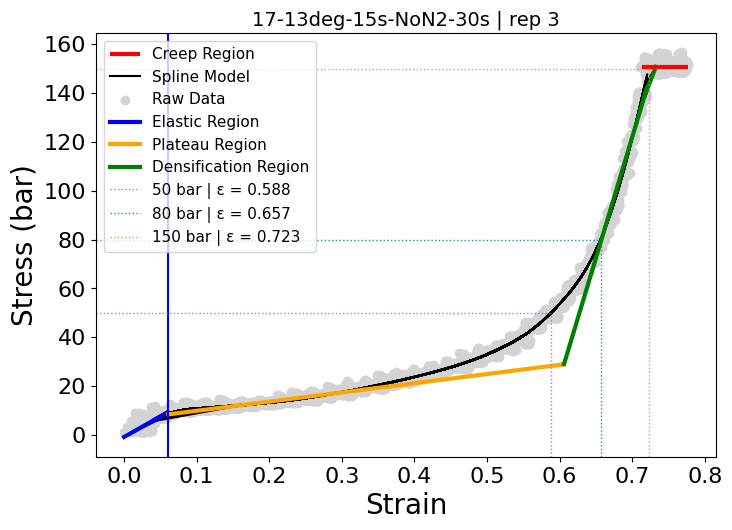

Score: 67/100 → PASS
  elastic_r2                      9/15  R²=0.625
  yield_accuracy                  3/10  |linear-GAM|=0.65 bar (7.5%)
  elastic_modulus                 5/5  E=167.3 bar
  junction_continuity             0/15  gap=10.1%
  plateau_flatness                2/5  slope/E=0.225
  plateau_r2_start                8/10  R²(first 40%)=0.816
  slope_ordering                  8/8  densif=989.7 > plateau=37.6
  densification_r2                2/2  R²=0.867
  elastic_vs_plateau             10/10  E=167.3 > slope=37.6
  breakpoint_order                5/5  bp1=0.061 < cp=0.606 < max=0.733
  densif_vs_elastic               5/5  densif/E=5.91
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=55.6 vs creep=150.8
Condition: 17-13deg-15s-NoN2-30s_run2 | pairs: 3


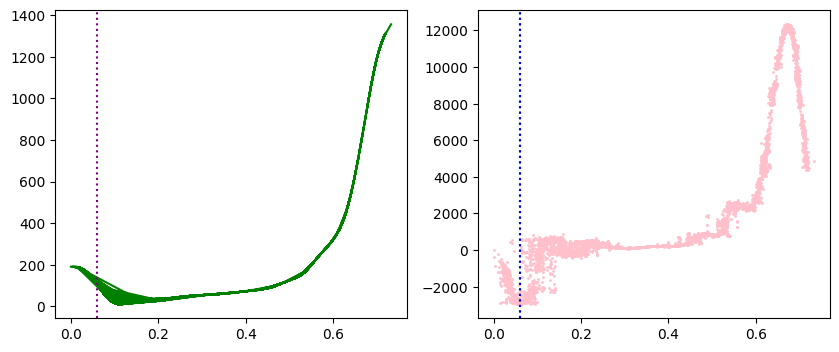

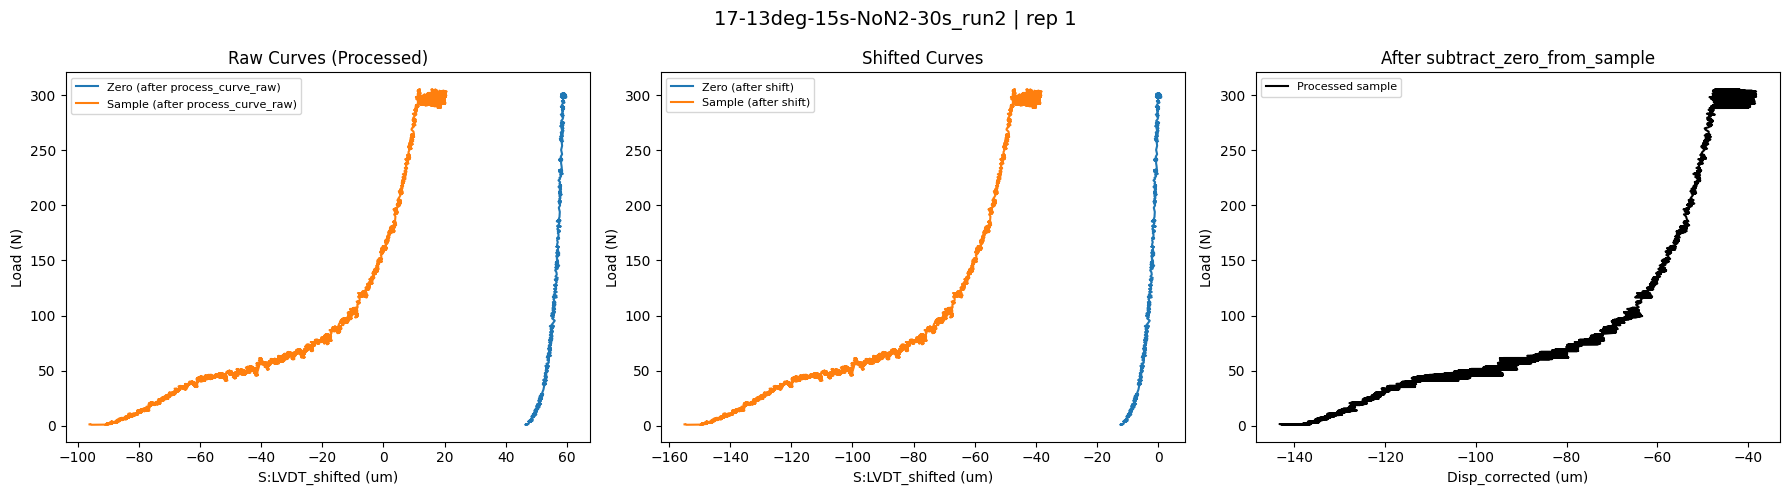

Average Standard Deviation: 59.58915423366913
Cutoff = 0.2409711054046313
PW + Double: 0.15482481413817956
Piecewise Chosen! 0.17610778449720674 | Drop Calculation: 0.19575360337173542
Cutoff = 0.2409711054046313
{'name': '17-13deg-15s-NoN2-30s_run2 | rep 1', 'Trial': 'sample 10', 'Thickness': np.float64(136.88060000000002), 'Elastic Modulus': np.float64(122.39380469062893), 'Yield Strength': np.float64(21.82591873764205), 'Changepoint': np.float64(0.538409443330182), 'Slope Plateau': np.float64(38.42819377365452), 'Slope Densification': np.float64(930.3812881288371), 'Creep Strain': np.float64(0.06928765780460033), 'Strain at 50 bar': 0.5087688979900923, 'Strain at 80 bar': 0.5829080749689524, 'Strain at 150 bar': 0.655899301830817, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(59.58915423366913)}


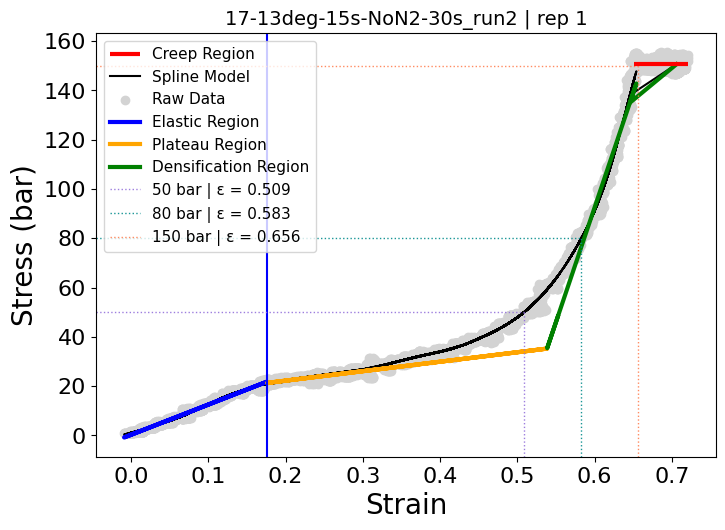

Score: 87/100 → PASS
  elastic_r2                     15/15  R²=0.980
  yield_accuracy                  7/10  |linear-GAM|=0.70 bar (3.3%)
  elastic_modulus                 5/5  E=122.4 bar
  junction_continuity            11/15  gap=2.4%
  plateau_flatness                1/5  slope/E=0.314
  plateau_r2_start                8/10  R²(first 40%)=0.765
  slope_ordering                  8/8  densif=930.4 > plateau=38.4
  densification_r2                2/2  R²=0.871
  elastic_vs_plateau             10/10  E=122.4 > slope=38.4
  breakpoint_order                5/5  bp1=0.176 < cp=0.538 < max=0.706
  densif_vs_elastic               5/5  densif/E=7.60
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=59.1 vs creep=150.6


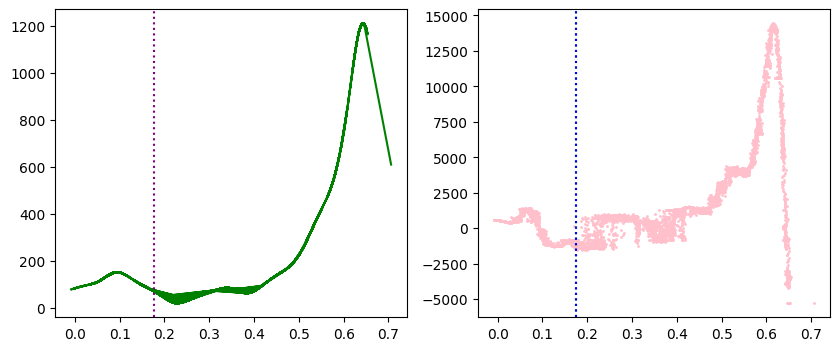

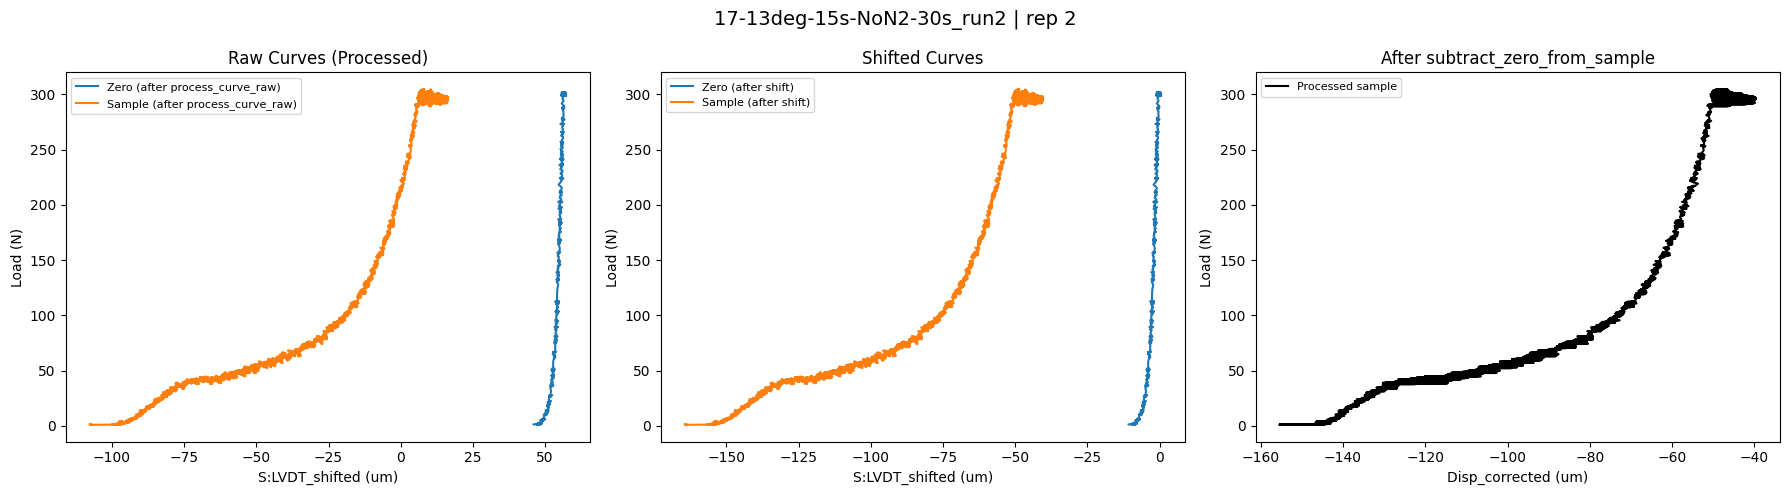

Average Standard Deviation: 58.93085045664295
Cutoff = 0.2181987173757196
PW + Double: 0.09009753010965892
Piecewise Chosen! 0.08955033818489547 | Drop Calculation: 0.1272574707885132
Cutoff = 0.2181987173757196
{'name': '17-13deg-15s-NoN2-30s_run2 | rep 2', 'Trial': 'sample 11', 'Thickness': np.float64(155.3972), 'Elastic Modulus': np.float64(180.40526209857907), 'Yield Strength': np.float64(18.90385039460152), 'Changepoint': np.float64(0.4802183419494571), 'Slope Plateau': np.float64(49.4300757040746), 'Slope Densification': np.float64(896.6099315801788), 'Creep Strain': np.float64(0.06943848171811018), 'Strain at 50 bar': 0.4443704418577244, 'Strain at 80 bar': 0.5240074964317426, 'Strain at 150 bar': 0.5989619791172938, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(58.93085045664295)}


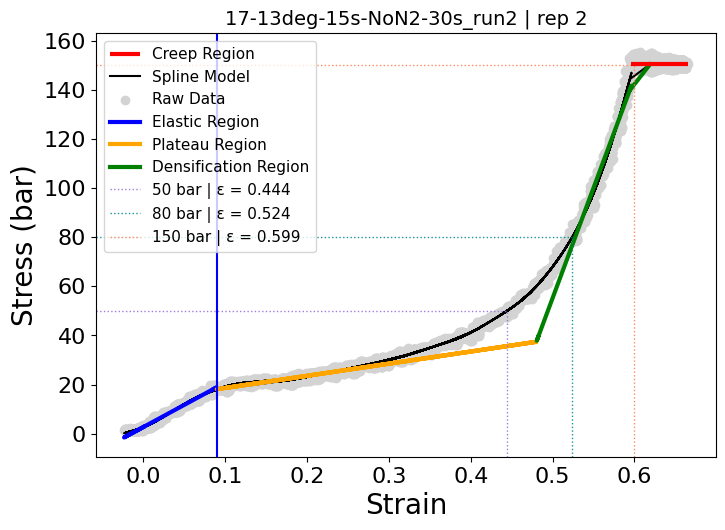

Score: 84/100 → PASS
  elastic_r2                     15/15  R²=0.975
  yield_accuracy                  6/10  |linear-GAM|=0.79 bar (4.4%)
  elastic_modulus                 5/5  E=180.4 bar
  junction_continuity             9/15  gap=4.2%
  plateau_flatness                1/5  slope/E=0.274
  plateau_r2_start                8/10  R²(first 40%)=0.814
  slope_ordering                  8/8  densif=896.6 > plateau=49.4
  densification_r2                2/2  R²=0.893
  elastic_vs_plateau             10/10  E=180.4 > slope=49.4
  breakpoint_order                5/5  bp1=0.090 < cp=0.480 < max=0.619
  densif_vs_elastic               5/5  densif/E=4.97
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=60.0 vs creep=150.3


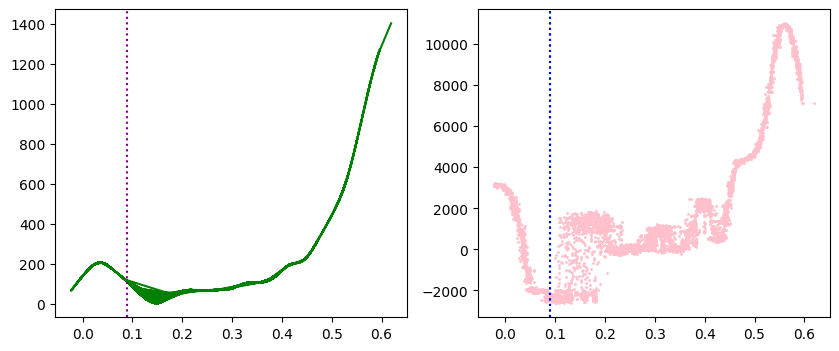

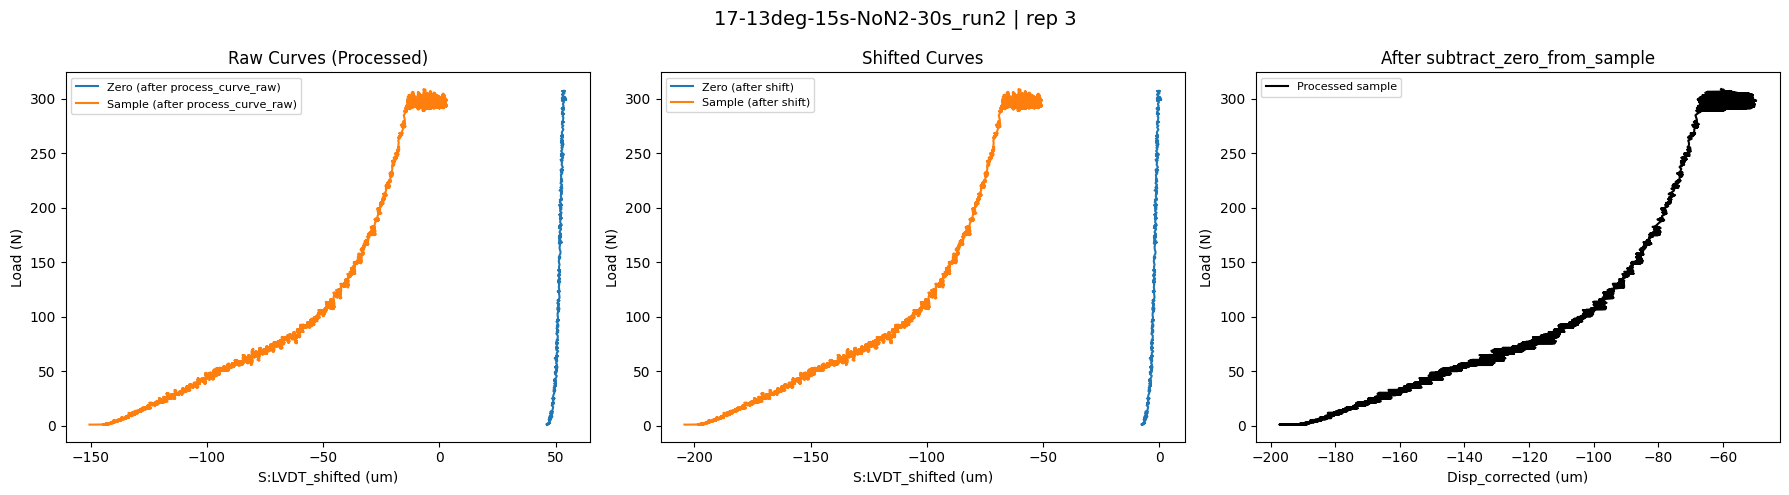

Average Standard Deviation: 59.04503243453197
Cutoff = 0.19821664306981585
PW + Double: None
Piecewise Chosen! 0.15331296116982976 | Drop Calculation: 0.07171400820565454
Cutoff = 0.19821664306981585
{'name': '17-13deg-15s-NoN2-30s_run2 | rep 3', 'Trial': 'sample 12', 'Thickness': np.float64(189.66180000000003), 'Elastic Modulus': np.float64(98.41167458023553), 'Yield Strength': np.float64(15.862734458458199), 'Changepoint': np.float64(0.5191064712690632), 'Slope Plateau': np.float64(100.51733320948848), 'Slope Densification': np.float64(713.0580941976333), 'Creep Strain': np.float64(0.08934537258143405), 'Strain at 50 bar': 0.44693770915925213, 'Strain at 80 bar': 0.546641480979968, 'Strain at 150 bar': 0.6495531011124994, 'Strain at 500 bar': nan, 'Good Fit': False, 'Average Standard Deviation': np.float64(59.04503243453197)}


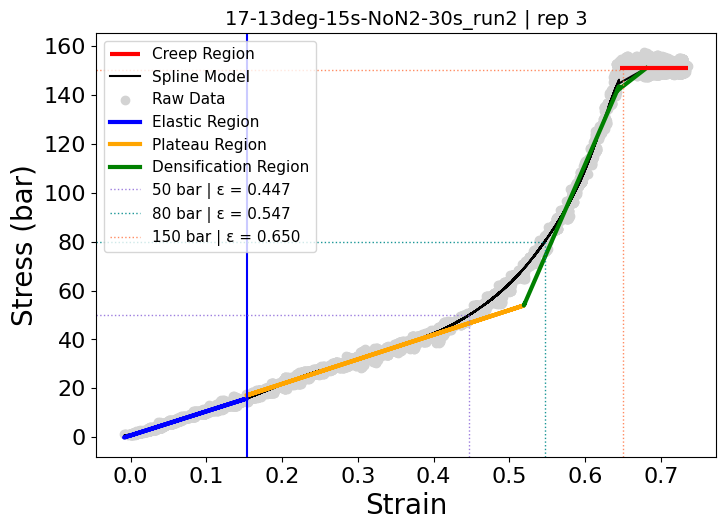

Score: 36/100 → FAIL
  elastic_r2                     15/15  R²=0.983
  yield_accuracy                 10/10  |linear-GAM|=0.07 bar (0.5%)
  elastic_modulus                 5/5  E=98.4 bar
  junction_continuity             3/15  gap=8.0%
  plateau_flatness                0/5  CATASTROPHIC: slope=100.5 > E=98.4
  plateau_r2_start                9/10  R²(first 40%)=0.939
  slope_ordering                  8/8  densif=713.1 > plateau=100.5
  densification_r2                2/2  R²=0.935
  elastic_vs_plateau              0/10  E=98.4 > slope=100.5
  breakpoint_order                5/5  bp1=0.153 < cp=0.519 < max=0.681
  densif_vs_elastic               5/5  densif/E=7.25
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=69.0 vs creep=150.9
  _catastrophic_penalty           0/0  slope > modulus — score halved
Condition: 17-13deg-18s-NoN2-50s | pairs: 3


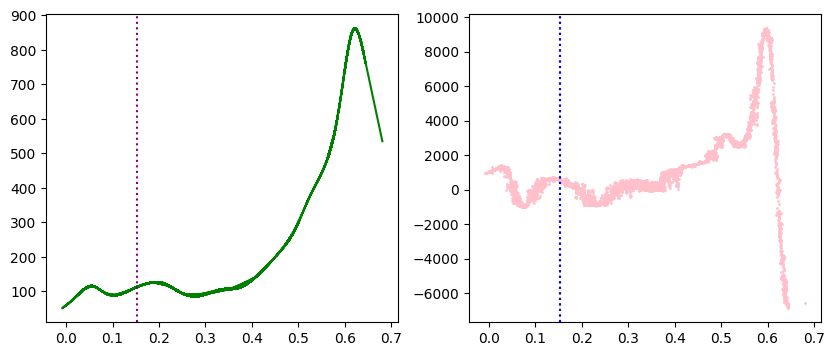

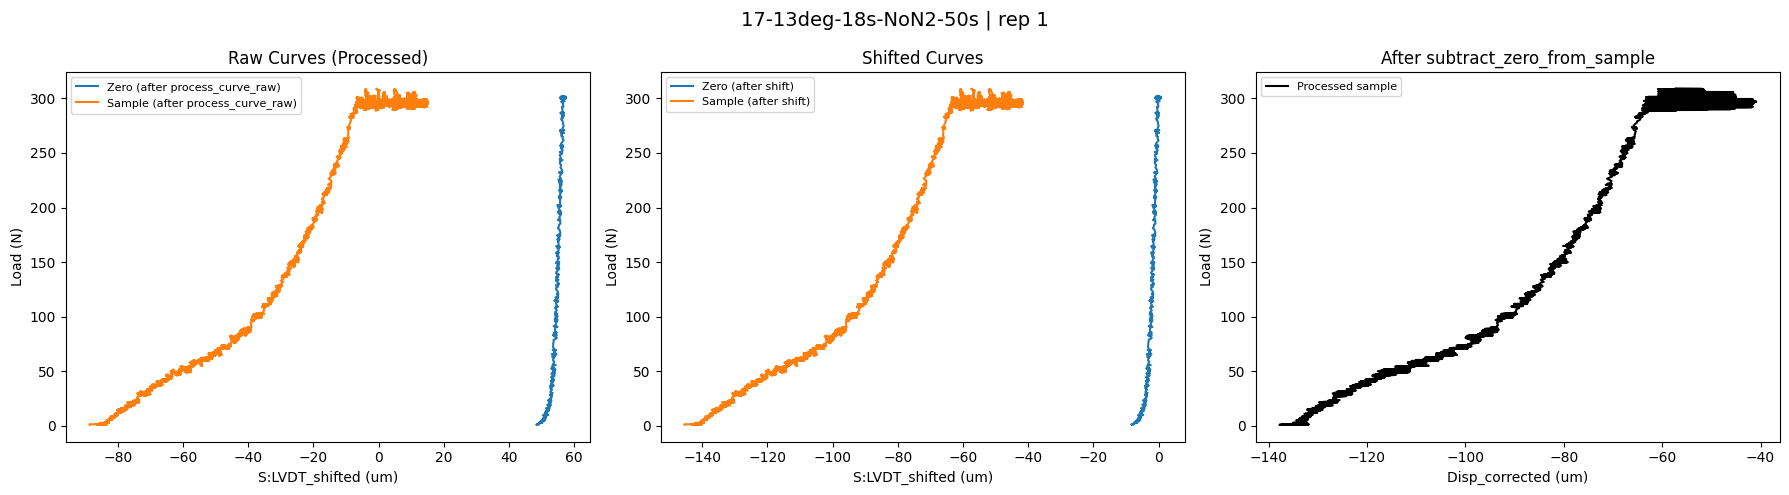

Average Standard Deviation: 54.81053775240917
Cutoff = 0.3
PW + Double: 0.09278253471758664
Piecewise Chosen! 0.07736612681923932 | Drop Calculation: 0.03521119717938048
Cutoff = 0.3
{'name': '17-13deg-18s-NoN2-50s | rep 1', 'Trial': 'sample 4', 'Thickness': np.float64(133.50240000000002), 'Elastic Modulus': np.float64(192.78215934360756), 'Yield Strength': np.float64(16.11443537822943), 'Changepoint': np.float64(0.3655292714390993), 'Slope Plateau': np.float64(110.62949682904474), 'Slope Densification': np.float64(585.0038299704989), 'Creep Strain': np.float64(0.16647550676341394), 'Strain at 50 bar': 0.31802141744509027, 'Strain at 80 bar': 0.4084707466518309, 'Strain at 150 bar': 0.5374693054272283, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(54.81053775240917)}


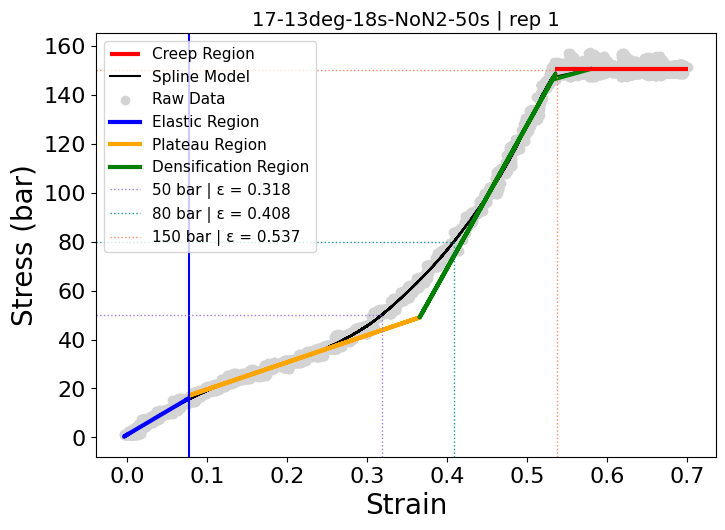

Score: 81/100 → PASS
  elastic_r2                     14/15  R²=0.944
  yield_accuracy                  7/10  |linear-GAM|=0.48 bar (3.1%)
  elastic_modulus                 5/5  E=192.8 bar
  junction_continuity             5/15  gap=6.5%
  plateau_flatness                1/5  slope/E=0.574
  plateau_r2_start                9/10  R²(first 40%)=0.935
  slope_ordering                  8/8  densif=585.0 > plateau=110.6
  densification_r2                2/2  R²=0.942
  elastic_vs_plateau             10/10  E=192.8 > slope=110.6
  breakpoint_order                5/5  bp1=0.077 < cp=0.366 < max=0.579
  densif_vs_elastic               5/5  densif/E=3.03
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=64.2 vs creep=150.5


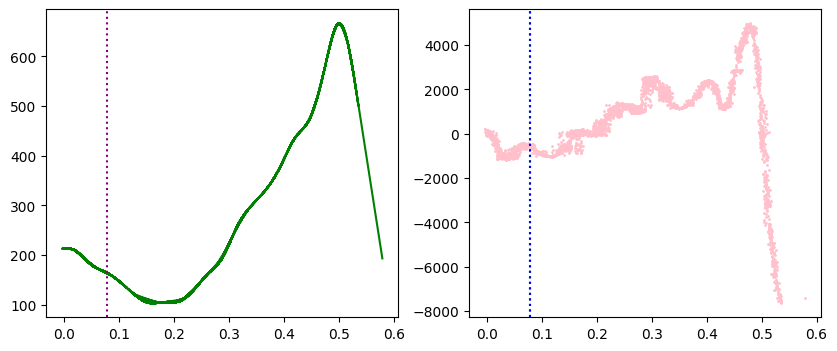

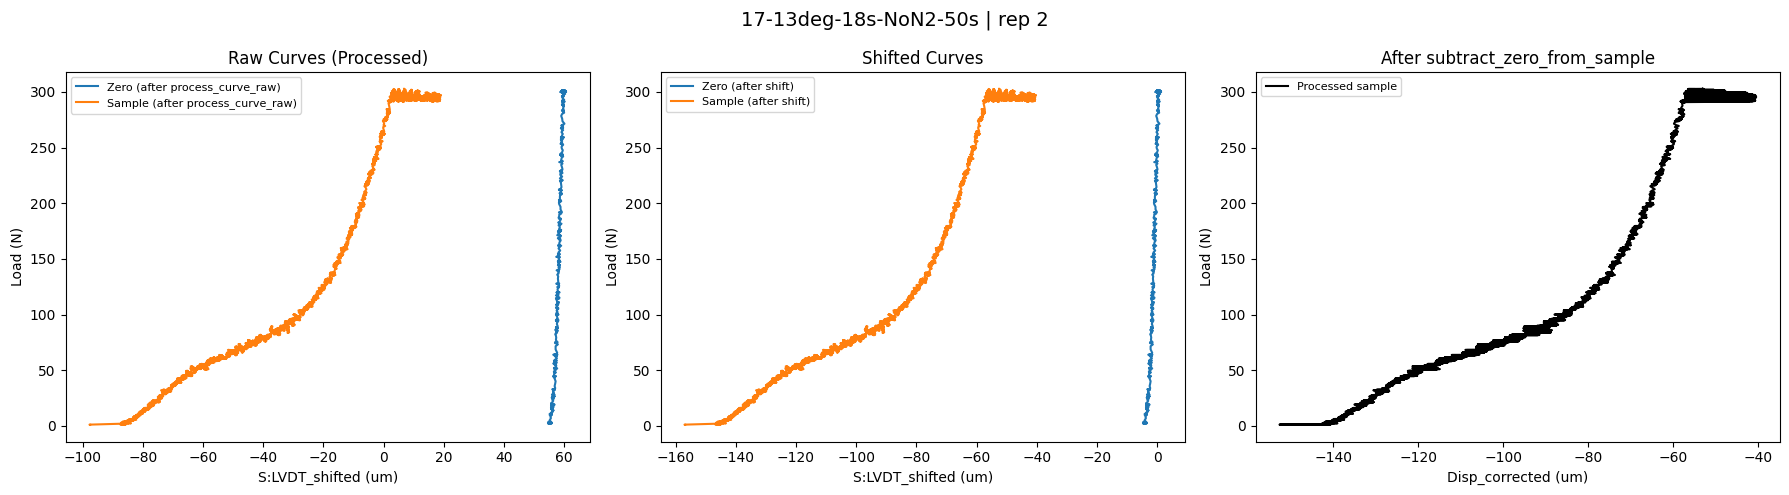

Average Standard Deviation: 55.574183482757924
Cutoff = 0.16767369148833206
PW + Double: 0.1332441904601364
Piecewise Chosen! 0.1260920092876827 | Drop Calculation: 0.15389581377818906
Cutoff = 0.16767369148833206
{'name': '17-13deg-18s-NoN2-50s | rep 2', 'Trial': 'sample 5', 'Thickness': np.float64(152.42540000000002), 'Elastic Modulus': np.float64(189.31694583554494), 'Yield Strength': np.float64(22.468688758826993), 'Changepoint': np.float64(0.4375901787598195), 'Slope Plateau': np.float64(104.86607626415748), 'Slope Densification': np.float64(742.1626120621205), 'Creep Strain': np.float64(0.1086929382641808), 'Strain at 50 bar': 0.36805677889730726, 'Strain at 80 bar': 0.4633728978486806, 'Strain at 150 bar': 0.5642099404655607, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(55.574183482757924)}


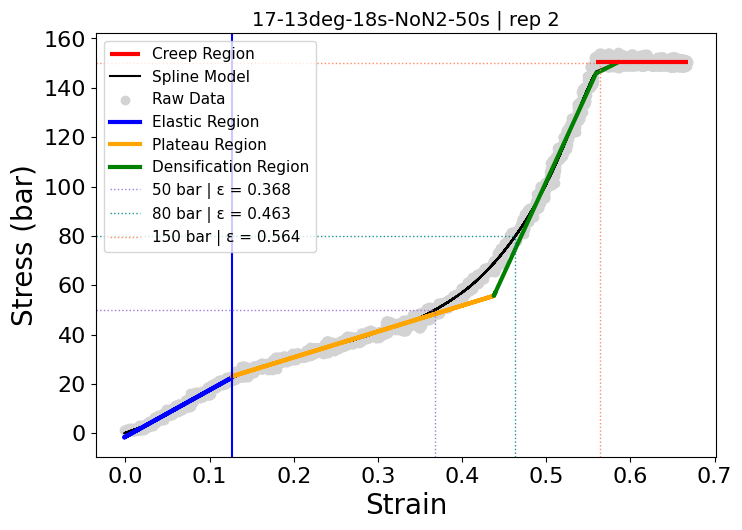

Score: 91/100 → PASS
  elastic_r2                     15/15  R²=0.984
  yield_accuracy                 10/10  |linear-GAM|=0.08 bar (0.3%)
  elastic_modulus                 5/5  E=189.3 bar
  junction_continuity            11/15  gap=2.5%
  plateau_flatness                1/5  slope/E=0.554
  plateau_r2_start                9/10  R²(first 40%)=0.943
  slope_ordering                  8/8  densif=742.2 > plateau=104.9
  densification_r2                2/2  R²=0.954
  elastic_vs_plateau             10/10  E=189.3 > slope=104.9
  breakpoint_order                5/5  bp1=0.126 < cp=0.438 < max=0.585
  densif_vs_elastic               5/5  densif/E=3.92
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=68.9 vs creep=150.3


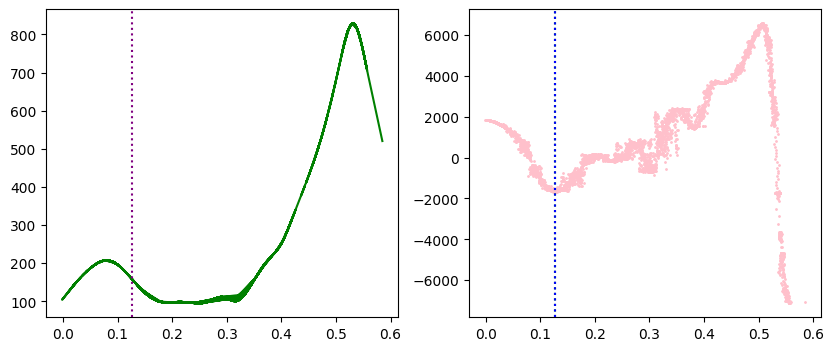

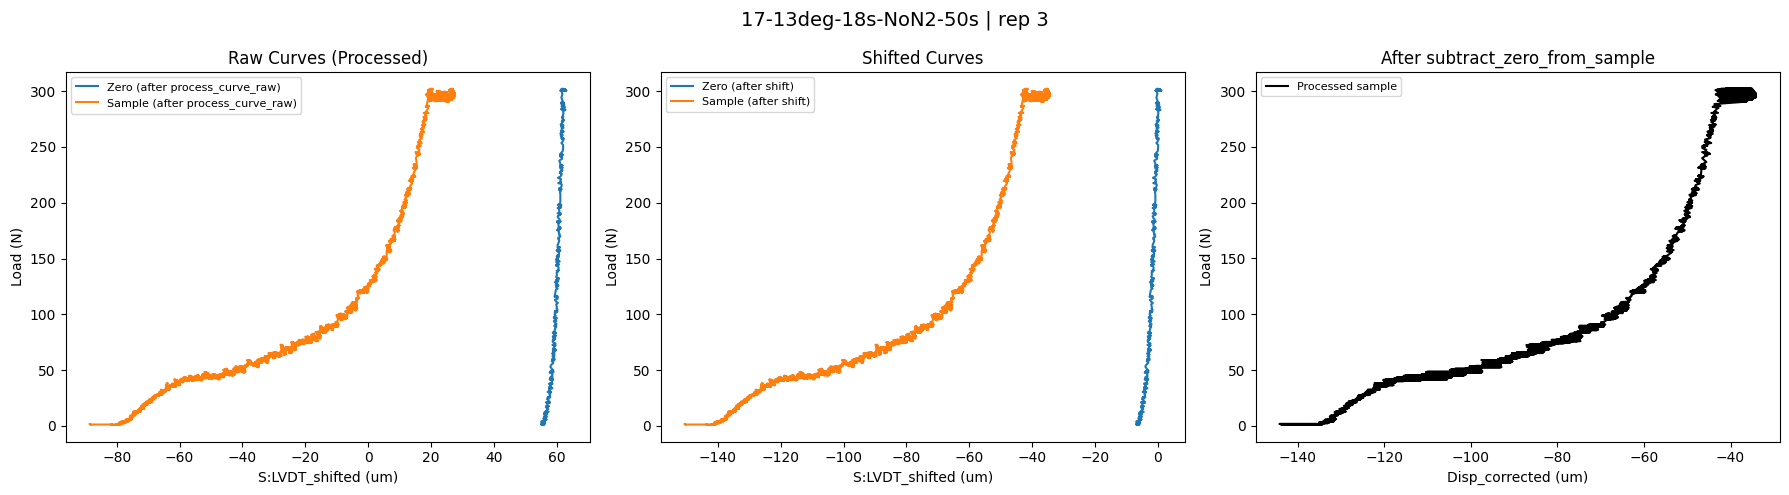

Average Standard Deviation: 57.55672077685494
Cutoff = 0.26701192089295783
PW + Double: 0.10114103566332872
Piecewise Chosen! 0.10035657558886808 | Drop Calculation: 0.11830978655280389
Cutoff = 0.26701192089295783
{'name': '17-13deg-18s-NoN2-50s | rep 3', 'Trial': 'sample 6', 'Thickness': np.float64(136.6774), 'Elastic Modulus': np.float64(183.5114141924834), 'Yield Strength': np.float64(19.614530129678755), 'Changepoint': np.float64(0.5340576318961263), 'Slope Plateau': np.float64(31.992534010683993), 'Slope Densification': np.float64(818.3706099419379), 'Creep Strain': np.float64(0.06313898213339653), 'Strain at 50 bar': 0.4841427776415855, 'Strain at 80 bar': 0.5831268813165444, 'Strain at 150 bar': 0.6714019639666269, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(57.55672077685494)}


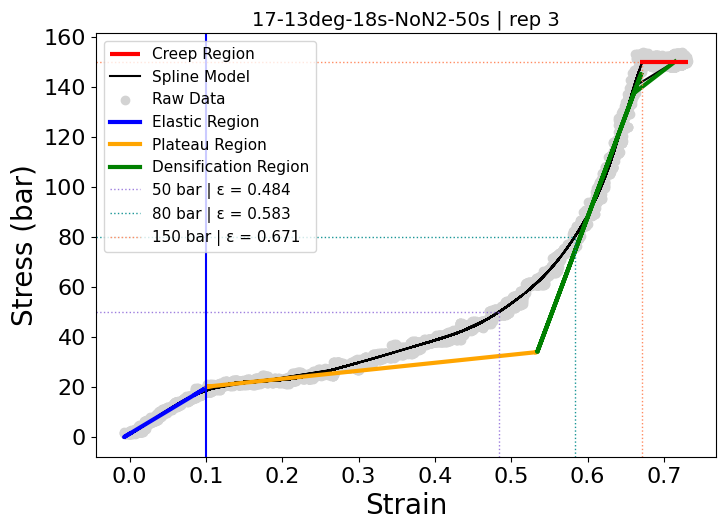

Score: 87/100 → PASS
  elastic_r2                     15/15  R²=0.977
  yield_accuracy                  5/10  |linear-GAM|=0.96 bar (5.1%)
  elastic_modulus                 5/5  E=183.5 bar
  junction_continuity            12/15  gap=2.1%
  plateau_flatness                2/5  slope/E=0.174
  plateau_r2_start                8/10  R²(first 40%)=0.819
  slope_ordering                  8/8  densif=818.4 > plateau=32.0
  densification_r2                2/2  R²=0.839
  elastic_vs_plateau             10/10  E=183.5 > slope=32.0
  breakpoint_order                5/5  bp1=0.100 < cp=0.534 < max=0.715
  densif_vs_elastic               5/5  densif/E=4.46
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=61.8 vs creep=150.2
Condition: 17-13deg-3s-NoN2-60s | pairs: 3


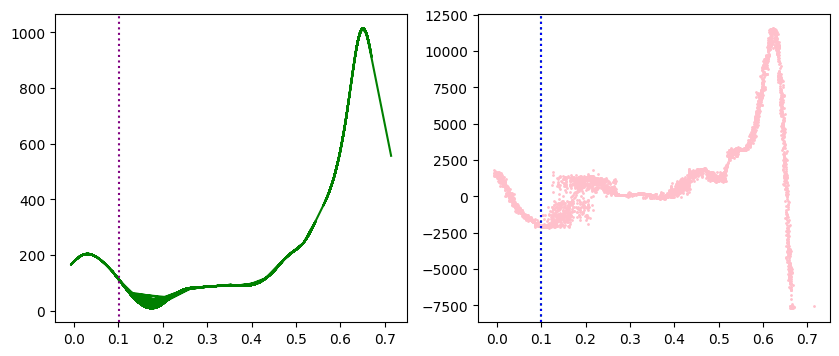

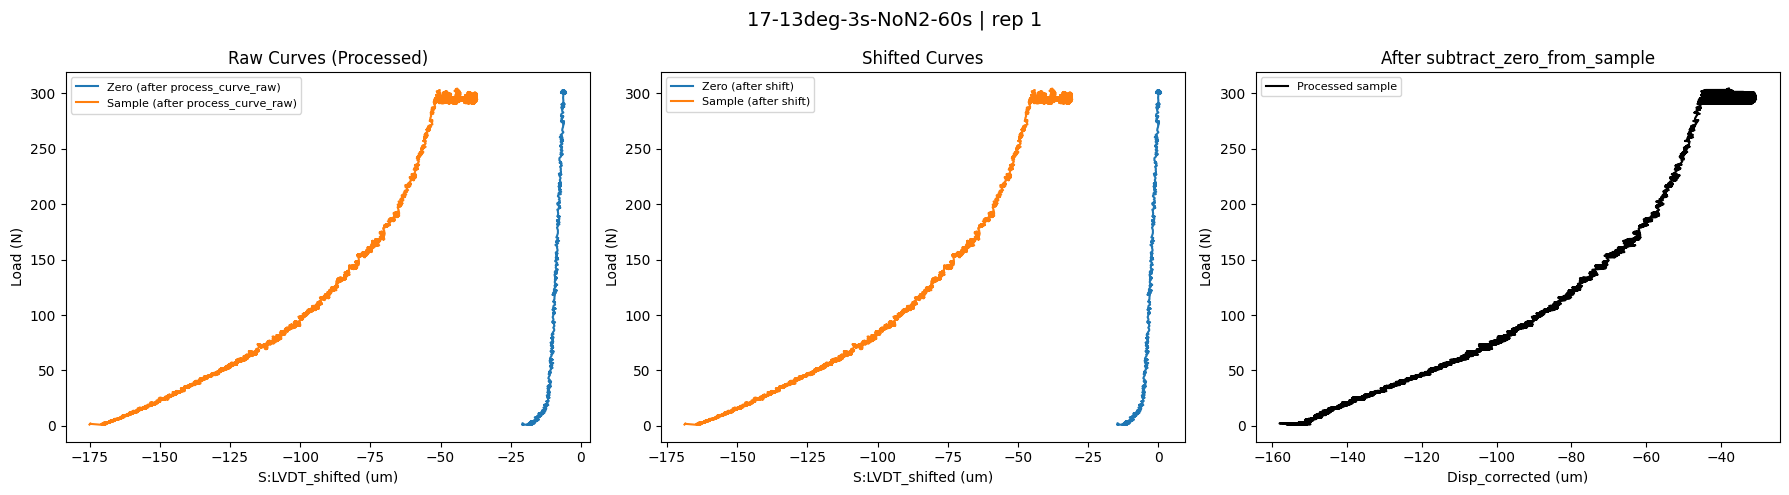

Average Standard Deviation: 57.67045309708247
Cutoff = 0.11497668105183073
PW + Double: 0.05247345717965863
Piecewise Chosen! 0.052775349867584684 | Drop Calculation: 0.048691480400165466
Cutoff = 0.11497668105183073
{'name': '17-13deg-3s-NoN2-60s | rep 1', 'Trial': 'sample 4', 'Thickness': np.float64(151.3586), 'Elastic Modulus': np.float64(119.46112863150101), 'Yield Strength': np.float64(7.758617814480913), 'Changepoint': np.float64(0.5682400718992494), 'Slope Plateau': np.float64(106.03776601208928), 'Slope Densification': np.float64(625.4666483557096), 'Creep Strain': np.float64(0.09490554159267905), 'Strain at 50 bar': 0.41199581095174875, 'Strain at 80 bar': 0.5543889912933543, 'Strain at 150 bar': 0.7078219605064124, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(57.67045309708247)}


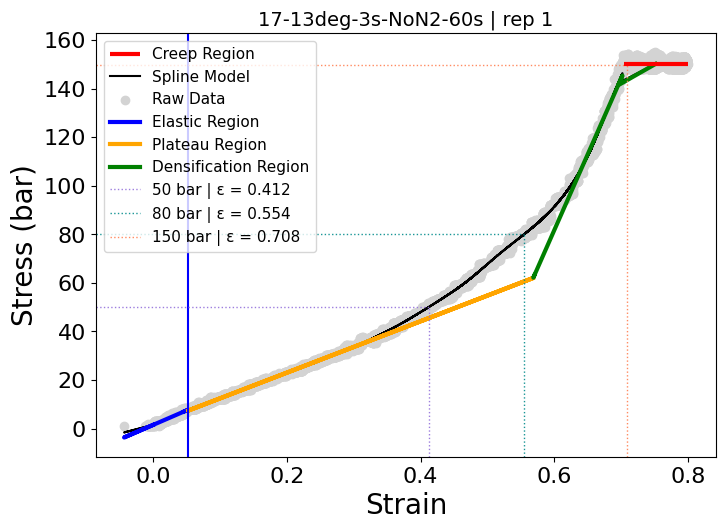

Score: 88/100 → PASS
  elastic_r2                     14/15  R²=0.929
  yield_accuracy                 10/10  |linear-GAM|=0.02 bar (0.3%)
  elastic_modulus                 5/5  E=119.5 bar
  junction_continuity             8/15  gap=4.8%
  plateau_flatness                1/5  slope/E=0.888
  plateau_r2_start               10/10  R²(first 40%)=0.992
  slope_ordering                  8/8  densif=625.5 > plateau=106.0
  densification_r2                2/2  R²=0.826
  elastic_vs_plateau             10/10  E=119.5 > slope=106.0
  breakpoint_order                5/5  bp1=0.053 < cp=0.568 < max=0.751
  densif_vs_elastic               5/5  densif/E=5.24
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=83.1 vs creep=150.3


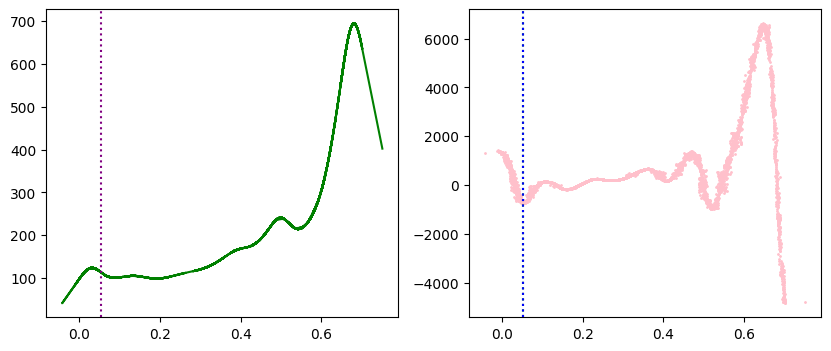

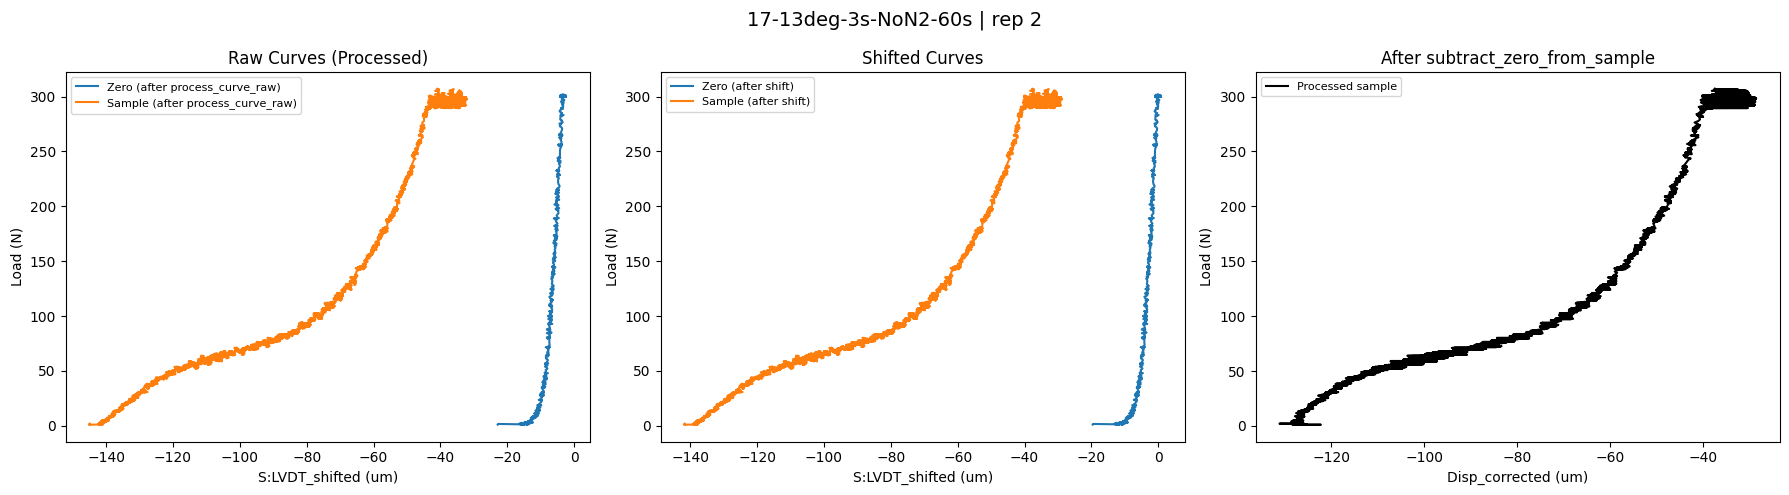

Average Standard Deviation: 55.67859368401564
Cutoff = 0.2592619365008387
PW + Double: 0.08745494985332926
Piecewise Chosen! 0.09705264195442667 | Drop Calculation: 0.06052149076131064
Cutoff = 0.2592619365008387
{'name': '17-13deg-3s-NoN2-60s | rep 2', 'Trial': 'sample 5', 'Thickness': np.float64(125.9902437896262), 'Elastic Modulus': np.float64(200.87701733075892), 'Yield Strength': np.float64(22.72876786636231), 'Changepoint': np.float64(0.5636662179621975), 'Slope Plateau': np.float64(63.89601354603746), 'Slope Densification': np.float64(698.4473785875736), 'Creep Strain': np.float64(0.08852438948767083), 'Strain at 50 bar': 0.4533800976814355, 'Strain at 80 bar': 0.5762265292141389, 'Strain at 150 bar': 0.6985421803145633, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(55.67859368401564)}


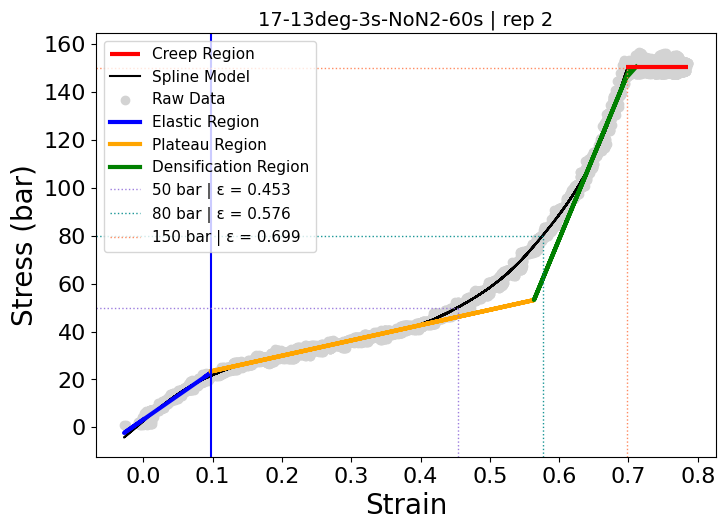

Score: 84/100 → PASS
  elastic_r2                     14/15  R²=0.964
  yield_accuracy                  4/10  |linear-GAM|=1.20 bar (5.6%)
  elastic_modulus                 5/5  E=200.9 bar
  junction_continuity            11/15  gap=2.5%
  plateau_flatness                1/5  slope/E=0.318
  plateau_r2_start                9/10  R²(first 40%)=0.928
  slope_ordering                  8/8  densif=698.4 > plateau=63.9
  densification_r2                2/2  R²=0.804
  elastic_vs_plateau             10/10  E=200.9 > slope=63.9
  breakpoint_order                5/5  bp1=0.097 < cp=0.564 < max=0.711
  densif_vs_elastic               5/5  densif/E=3.48
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=75.7 vs creep=150.5


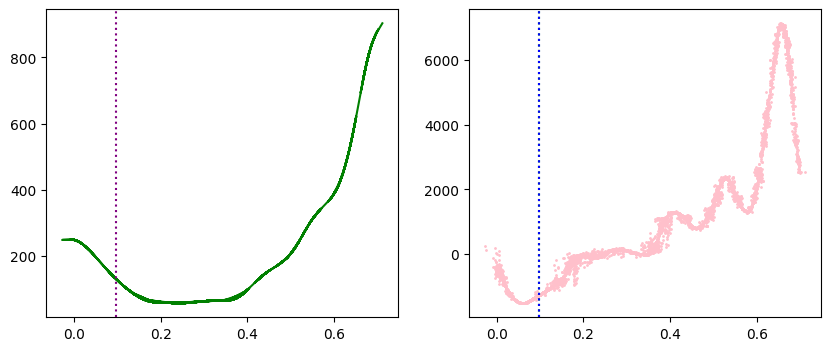

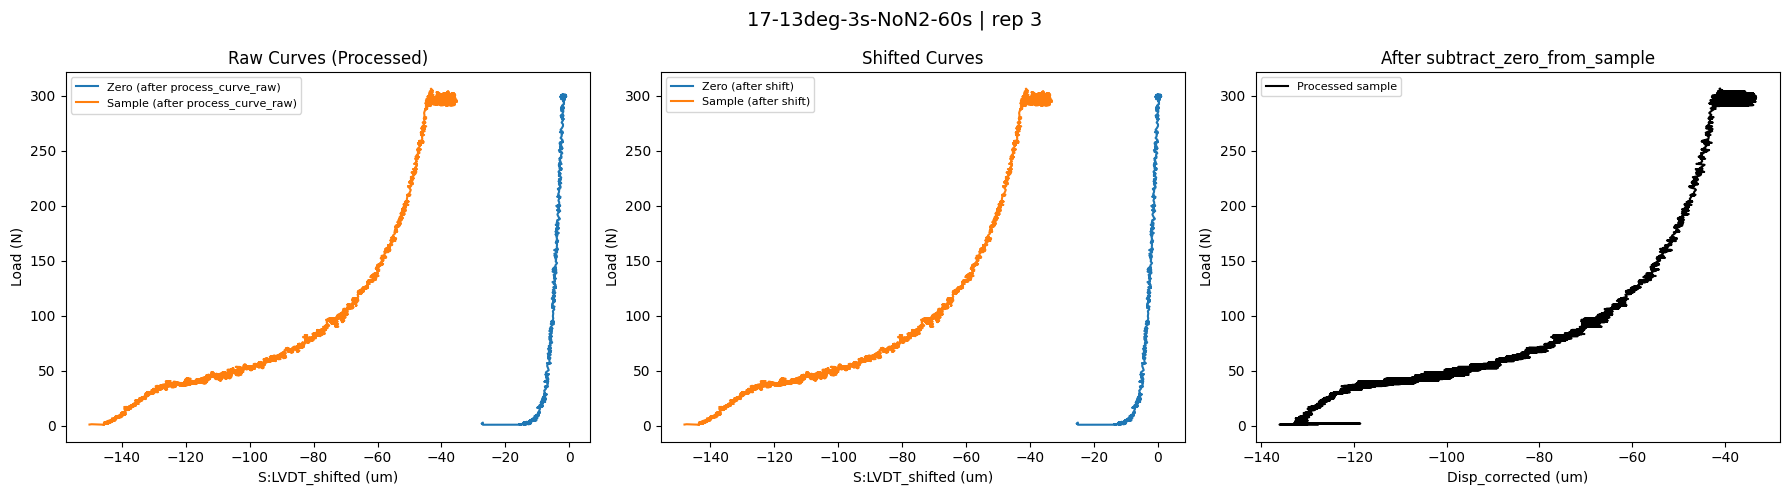

Average Standard Deviation: 58.59583057394552
Cutoff = 0.30929288646859027
PW + Double: 0.0722261941906484
Piecewise Chosen! 0.0707632537918037 | Drop Calculation: 0.06492183950624686
Cutoff = 0.30929288646859027
{'name': '17-13deg-3s-NoN2-60s | rep 3', 'Trial': 'sample 6', 'Thickness': np.float64(127.8711608118266), 'Elastic Modulus': np.float64(210.7609818748946), 'Yield Strength': np.float64(16.468590489333753), 'Changepoint': np.float64(0.5806639565829281), 'Slope Plateau': np.float64(47.59574580685483), 'Slope Densification': np.float64(822.8081744102319), 'Creep Strain': np.float64(0.07235184823316121), 'Strain at 50 bar': 0.509674073954816, 'Strain at 80 bar': 0.6186917867589548, 'Strain at 150 bar': 0.707189896151307, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(58.59583057394552)}


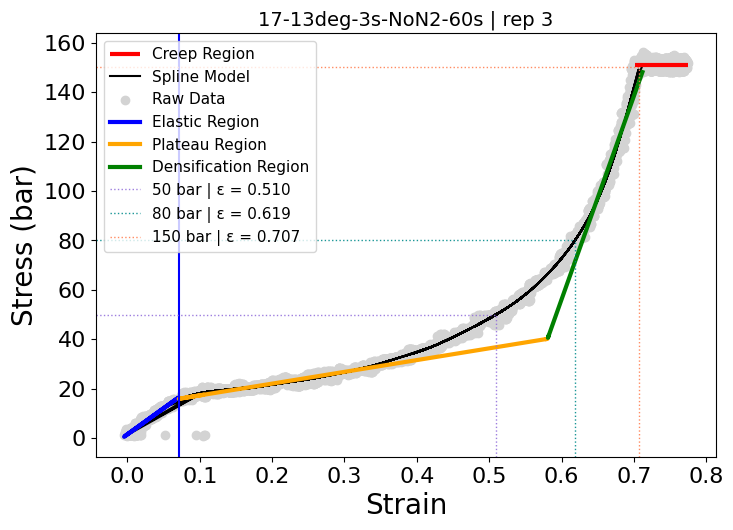

Score: 83/100 → PASS
  elastic_r2                     14/15  R²=0.936
  yield_accuracy                  4/10  |linear-GAM|=1.00 bar (6.5%)
  elastic_modulus                 5/5  E=210.8 bar
  junction_continuity            10/15  gap=3.4%
  plateau_flatness                2/5  slope/E=0.226
  plateau_r2_start                8/10  R²(first 40%)=0.760
  slope_ordering                  8/8  densif=822.8 > plateau=47.6
  densification_r2                2/2  R²=0.809
  elastic_vs_plateau             10/10  E=210.8 > slope=47.6
  breakpoint_order                5/5  bp1=0.071 < cp=0.581 < max=0.712
  densif_vs_elastic               5/5  densif/E=3.90
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=66.4 vs creep=150.8
Condition: 17-13deg-60s-N2-1800s | pairs: 3


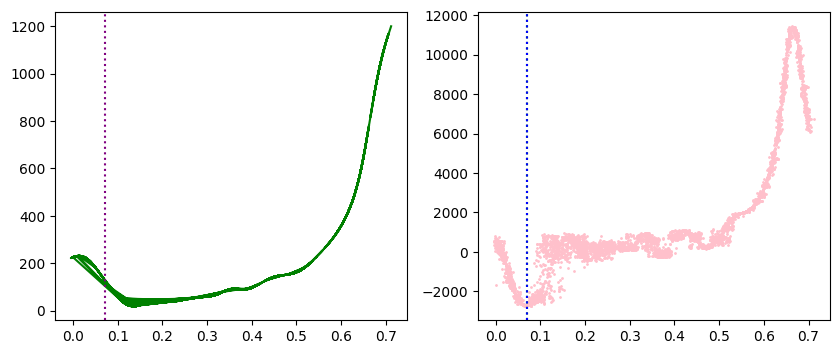

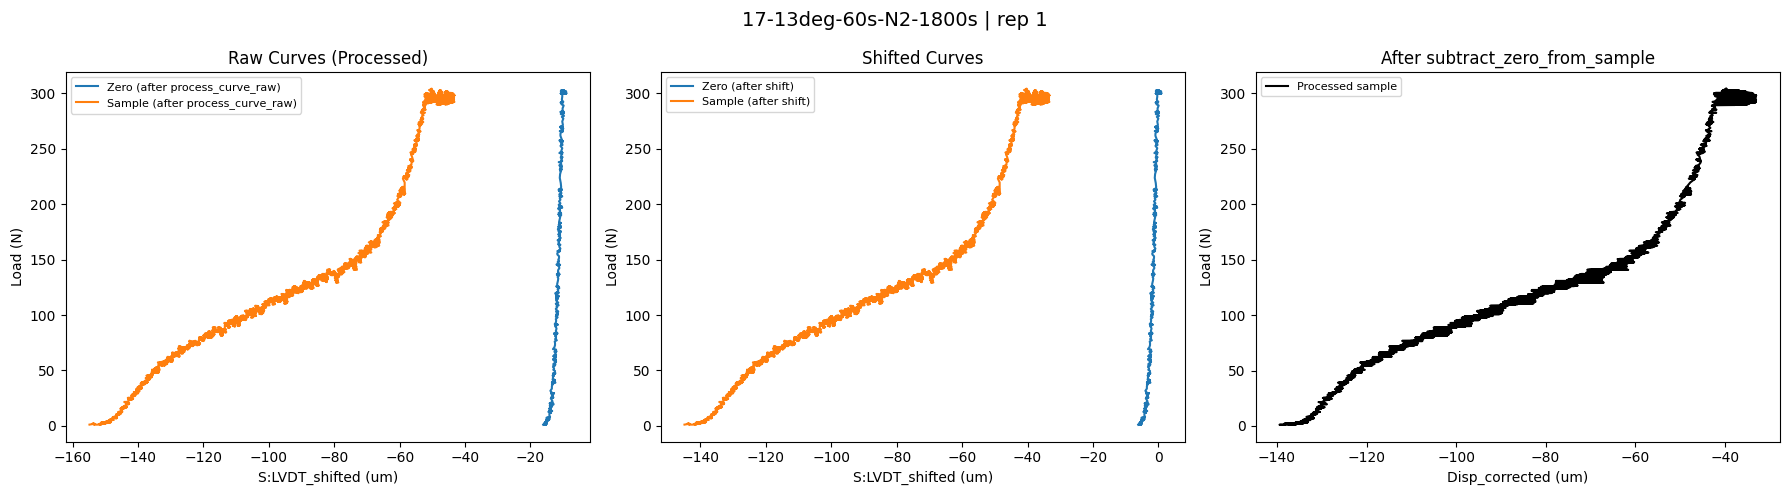

Average Standard Deviation: 52.071836724650815
Cutoff = 0.2534902427078042
PW + Double: 0.09966775188289363
Piecewise Chosen! 0.10555121280427589 | Drop Calculation: 0.10783254756809249
Cutoff = 0.2534902427078042
{'name': '17-13deg-60s-N2-1800s | rep 1', 'Trial': 'sample 4', 'Thickness': np.float64(138.32840000000002), 'Elastic Modulus': np.float64(269.06622792154366), 'Yield Strength': np.float64(28.958242350198454), 'Changepoint': np.float64(0.5896382523516778), 'Slope Plateau': np.float64(115.17020935273787), 'Slope Densification': np.float64(717.4428249652138), 'Creep Strain': np.float64(0.0632607648436373), 'Strain at 50 bar': 0.2818257809738963, 'Strain at 80 bar': 0.5462431657145798, 'Strain at 150 bar': 0.6738715116938089, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(52.071836724650815)}


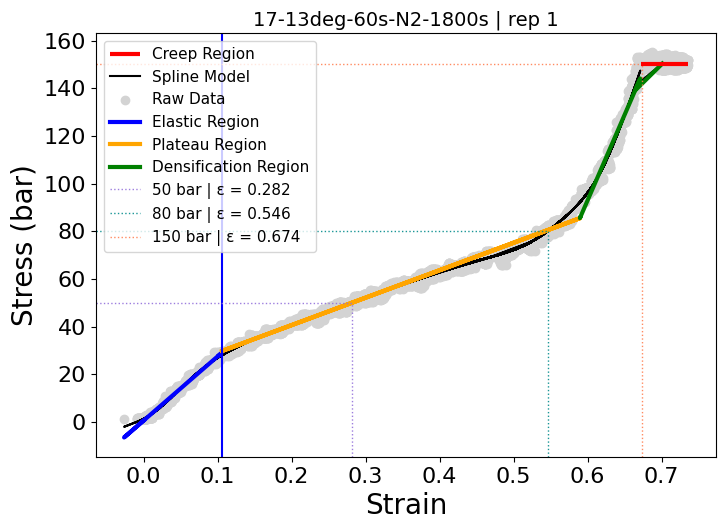

Score: 89/100 → PASS
  elastic_r2                     15/15  R²=0.985
  yield_accuracy                  7/10  |linear-GAM|=0.98 bar (3.5%)
  elastic_modulus                 5/5  E=269.1 bar
  junction_continuity            11/15  gap=2.6%
  plateau_flatness                1/5  slope/E=0.428
  plateau_r2_start               10/10  R²(first 40%)=0.971
  slope_ordering                  8/8  densif=717.4 > plateau=115.2
  densification_r2                2/2  R²=0.949
  elastic_vs_plateau             10/10  E=269.1 > slope=115.2
  breakpoint_order                5/5  bp1=0.106 < cp=0.590 < max=0.701
  densif_vs_elastic               5/5  densif/E=2.67
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=92.1 vs creep=150.3


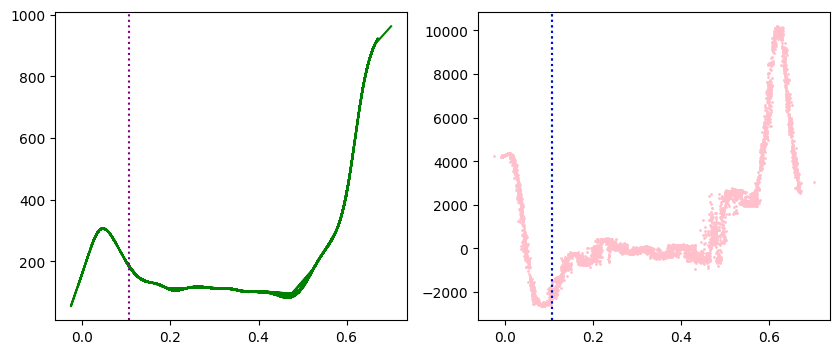

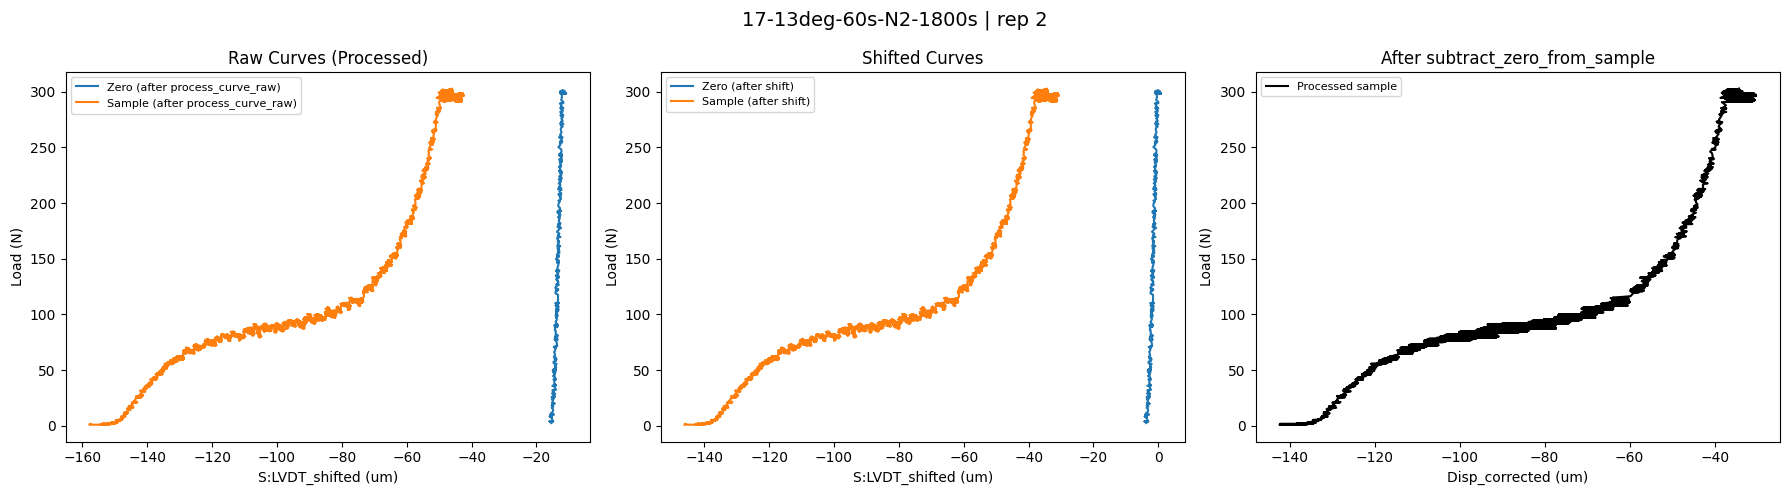

Average Standard Deviation: 53.823830851262265
Cutoff = 0.2567790399413704
PW + Double: 0.1086840632936779
Piecewise Chosen! 0.11872340706969121 | Drop Calculation: 0.10116594126267883
Cutoff = 0.2567790399413704
{'name': '17-13deg-60s-N2-1800s | rep 2', 'Trial': 'sample 5', 'Thickness': np.float64(138.63320000000002), 'Elastic Modulus': np.float64(247.95651170516373), 'Yield Strength': np.float64(29.39357816600371), 'Changepoint': np.float64(0.5950484096463167), 'Slope Plateau': np.float64(49.830257537407554), 'Slope Densification': np.float64(771.3810541291449), 'Creep Strain': np.float64(0.053865884939538256), 'Strain at 50 bar': 0.4555012946864735, 'Strain at 80 bar': 0.6146706135520158, 'Strain at 150 bar': 0.7080481335813045, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(53.823830851262265)}


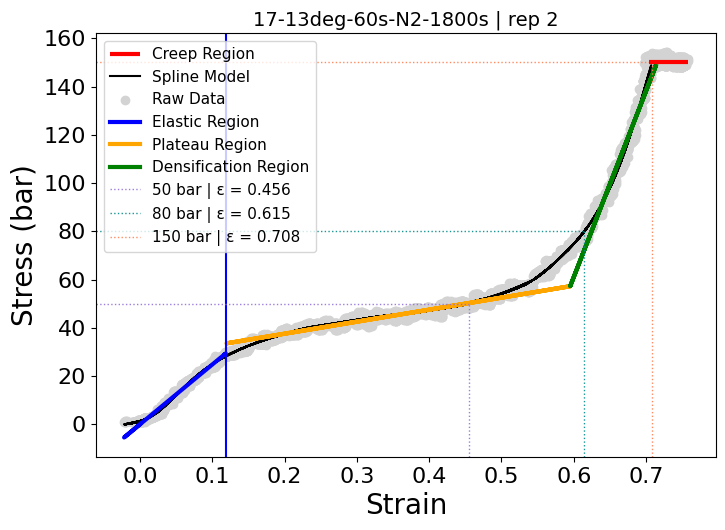

Score: 76/100 → PASS
  elastic_r2                     15/15  R²=0.981
  yield_accuracy                  6/10  |linear-GAM|=1.17 bar (4.1%)
  elastic_modulus                 5/5  E=248.0 bar
  junction_continuity             0/15  gap=13.9%
  plateau_flatness                2/5  slope/E=0.201
  plateau_r2_start                8/10  R²(first 40%)=0.778
  slope_ordering                  8/8  densif=771.4 > plateau=49.8
  densification_r2                2/2  R²=0.931
  elastic_vs_plateau             10/10  E=248.0 > slope=49.8
  breakpoint_order                5/5  bp1=0.119 < cp=0.595 < max=0.714
  densif_vs_elastic               5/5  densif/E=3.11
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=73.2 vs creep=150.0


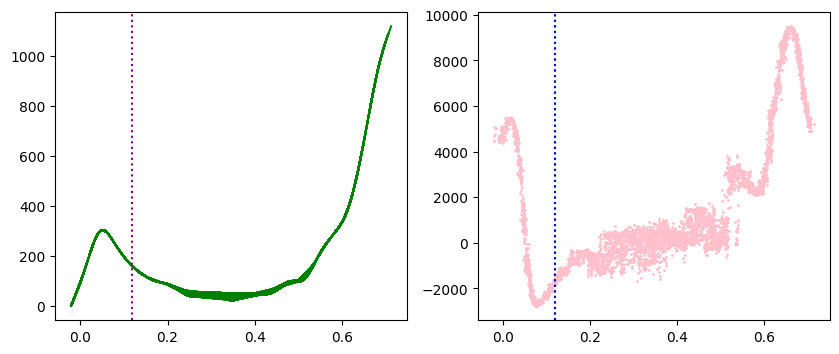

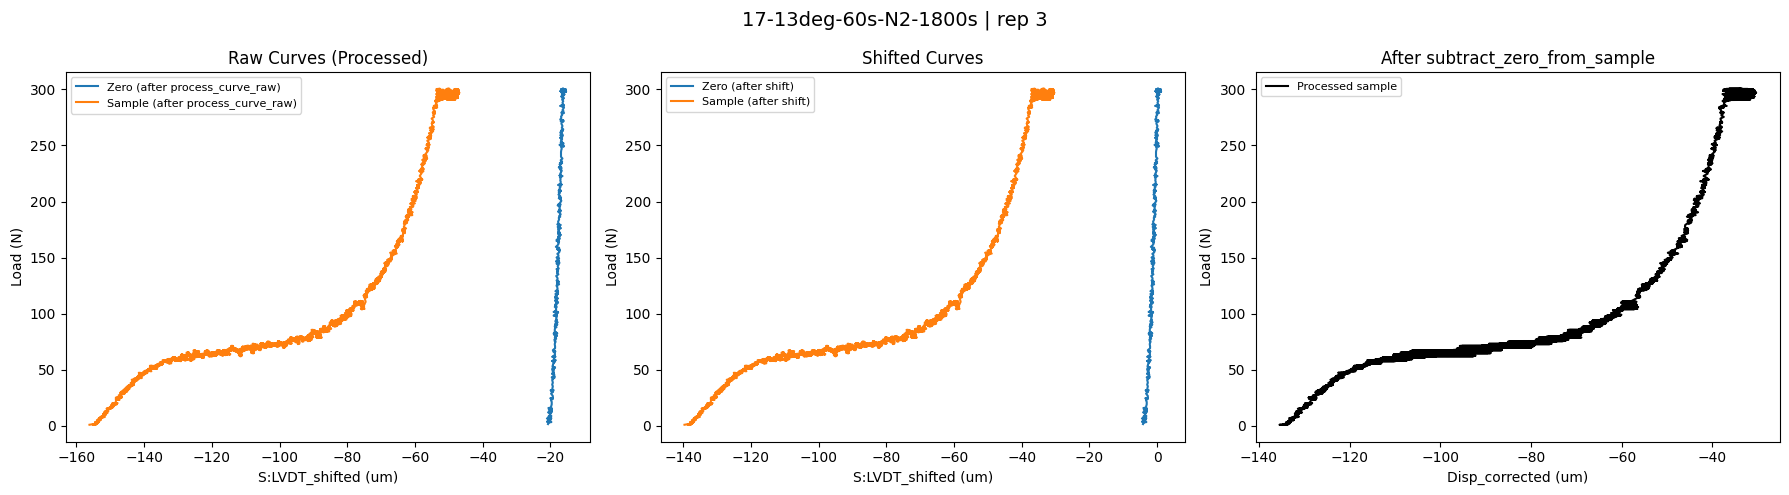

Average Standard Deviation: 55.68545742284196
Cutoff = 0.31128179984284793
PW + Double: 0.09760481670143917
Piecewise Chosen! 0.10990048526389003 | Drop Calculation: 0.08718014354789894
Cutoff = 0.31128179984284793
{'name': '17-13deg-60s-N2-1800s | rep 3', 'Trial': 'sample 6', 'Thickness': np.float64(134.36599999999999), 'Elastic Modulus': np.float64(234.09360661718551), 'Yield Strength': np.float64(27.953100071376035), 'Changepoint': np.float64(0.6103132439319218), 'Slope Plateau': np.float64(34.437756301274604), 'Slope Densification': np.float64(922.3887669863701), 'Creep Strain': np.float64(0.053390726594161664), 'Strain at 50 bar': 0.5311181668618365, 'Strain at 80 bar': 0.6356246547851481, 'Strain at 150 bar': 0.7196268708891174, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(55.68545742284196)}


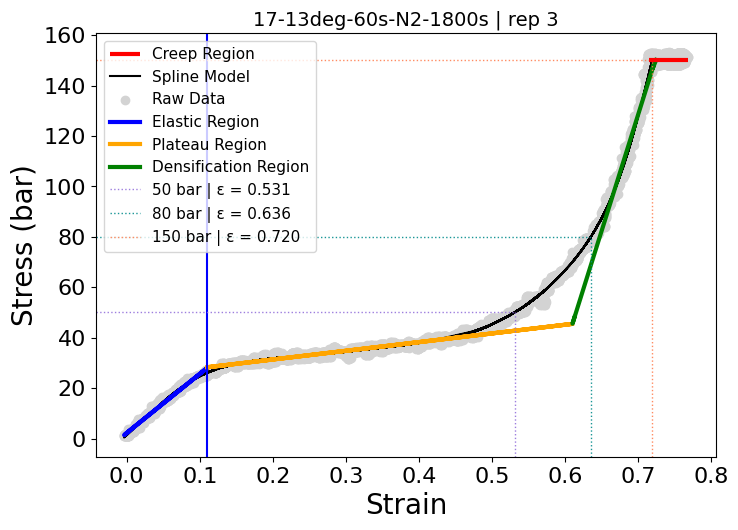

Score: 86/100 → PASS
  elastic_r2                     15/15  R²=0.985
  yield_accuracy                  3/10  |linear-GAM|=1.87 bar (7.2%)
  elastic_modulus                 5/5  E=234.1 bar
  junction_continuity            13/15  gap=1.1%
  plateau_flatness                2/5  slope/E=0.147
  plateau_r2_start                8/10  R²(first 40%)=0.803
  slope_ordering                  8/8  densif=922.4 > plateau=34.4
  densification_r2                2/2  R²=0.851
  elastic_vs_plateau             10/10  E=234.1 > slope=34.4
  breakpoint_order                5/5  bp1=0.110 < cp=0.610 < max=0.725
  densif_vs_elastic               5/5  densif/E=3.94
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=70.0 vs creep=150.2
Condition: 17-5deg-0s-N2-1800s | pairs: 3


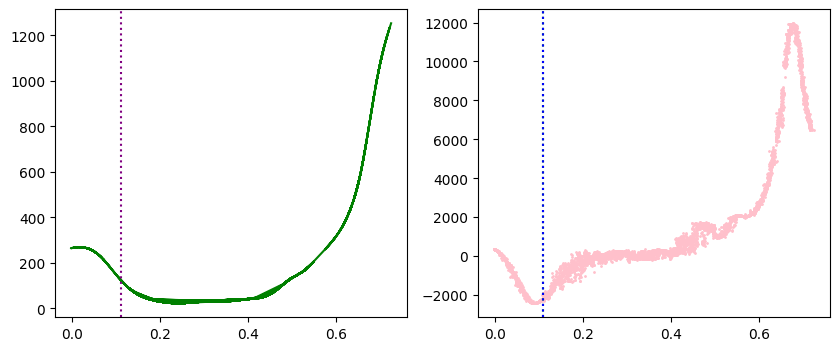

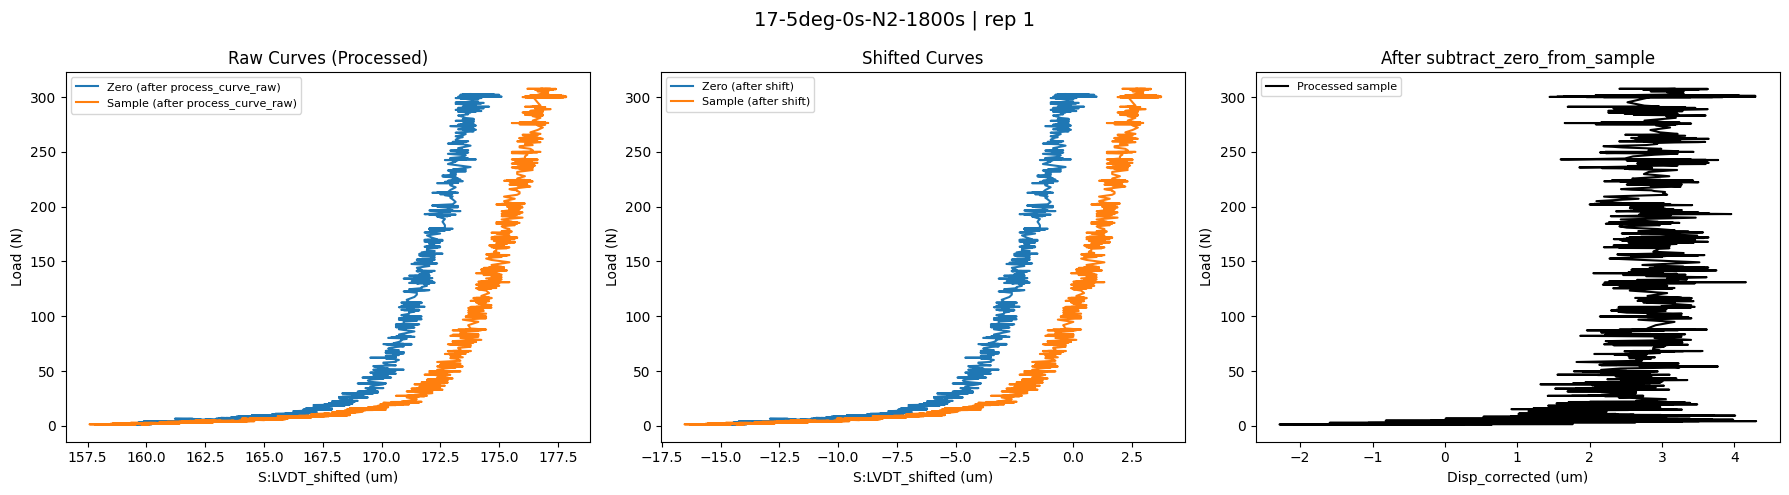

Average Standard Deviation: 49.49117825307869
Skipping GAM for 17-5deg-0s-N2-1800s | rep 1 (thickness=0.7 µm — no membrane)


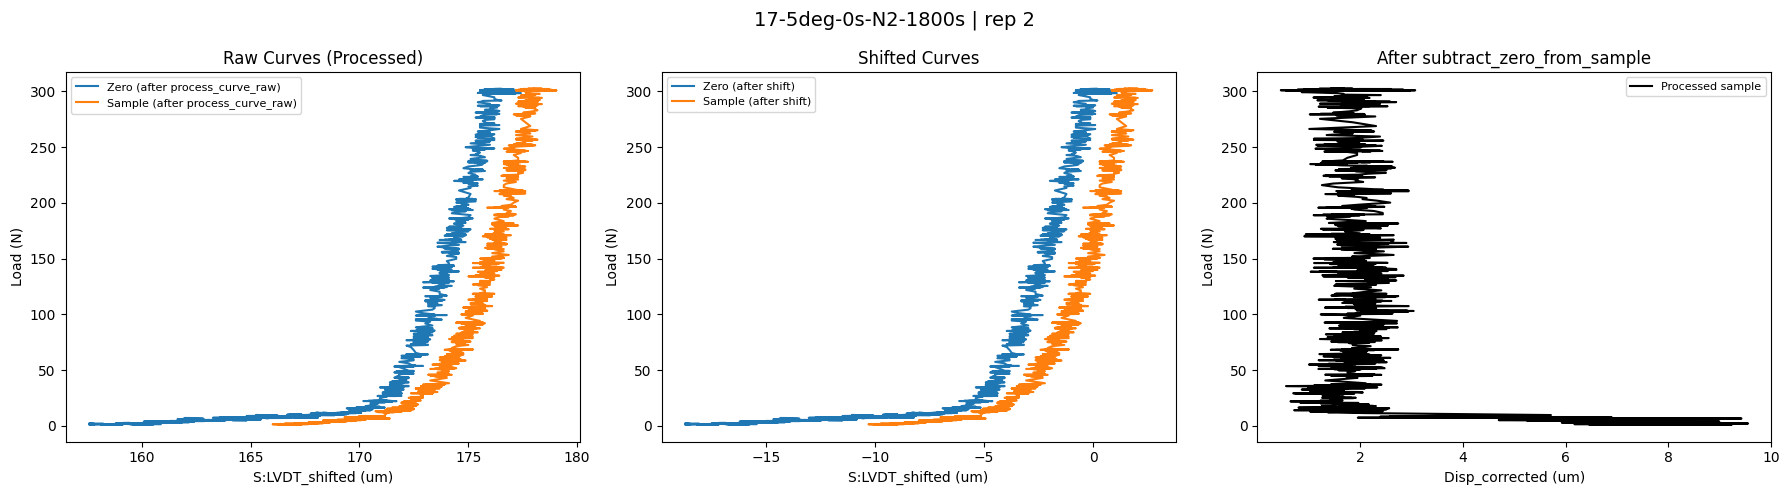

Average Standard Deviation: 41.92723441754036
Skipping GAM for 17-5deg-0s-N2-1800s | rep 2 (thickness=-7.7 µm — no membrane)


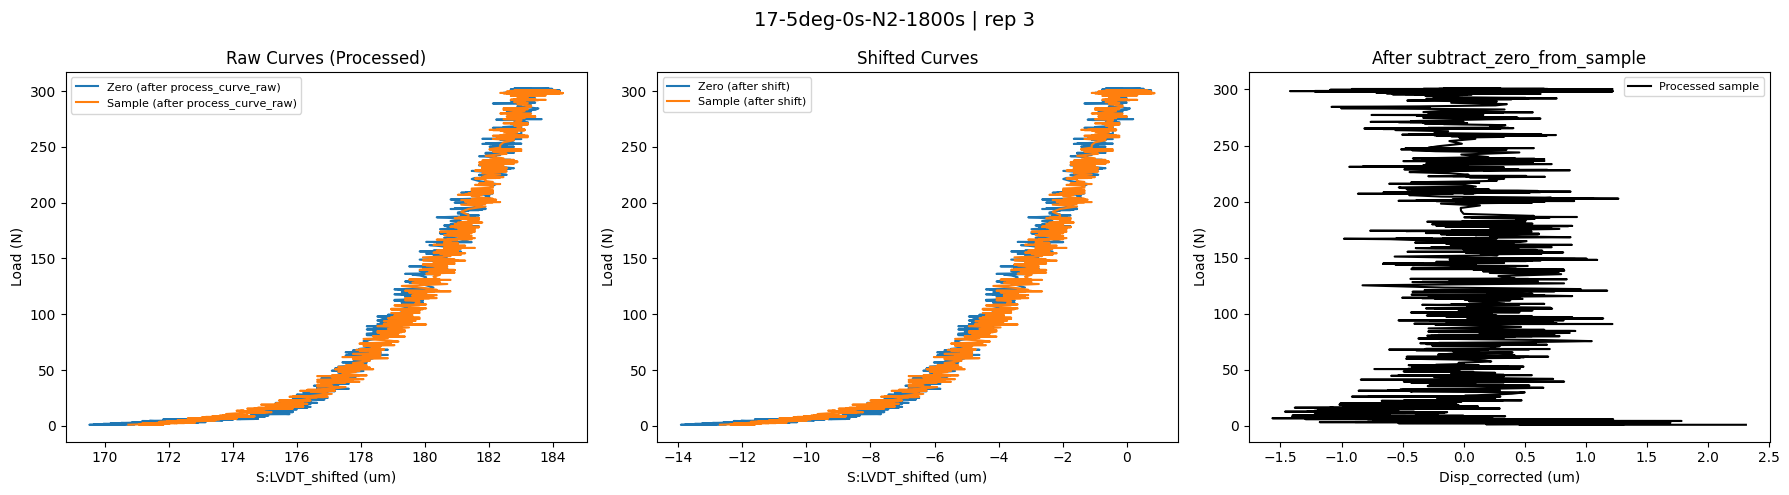

Average Standard Deviation: 41.32001331816768
Skipping GAM for 17-5deg-0s-N2-1800s | rep 3 (thickness=-2.3 µm — no membrane)
Condition: 17-5deg-4s-NoN2-60s | pairs: 3


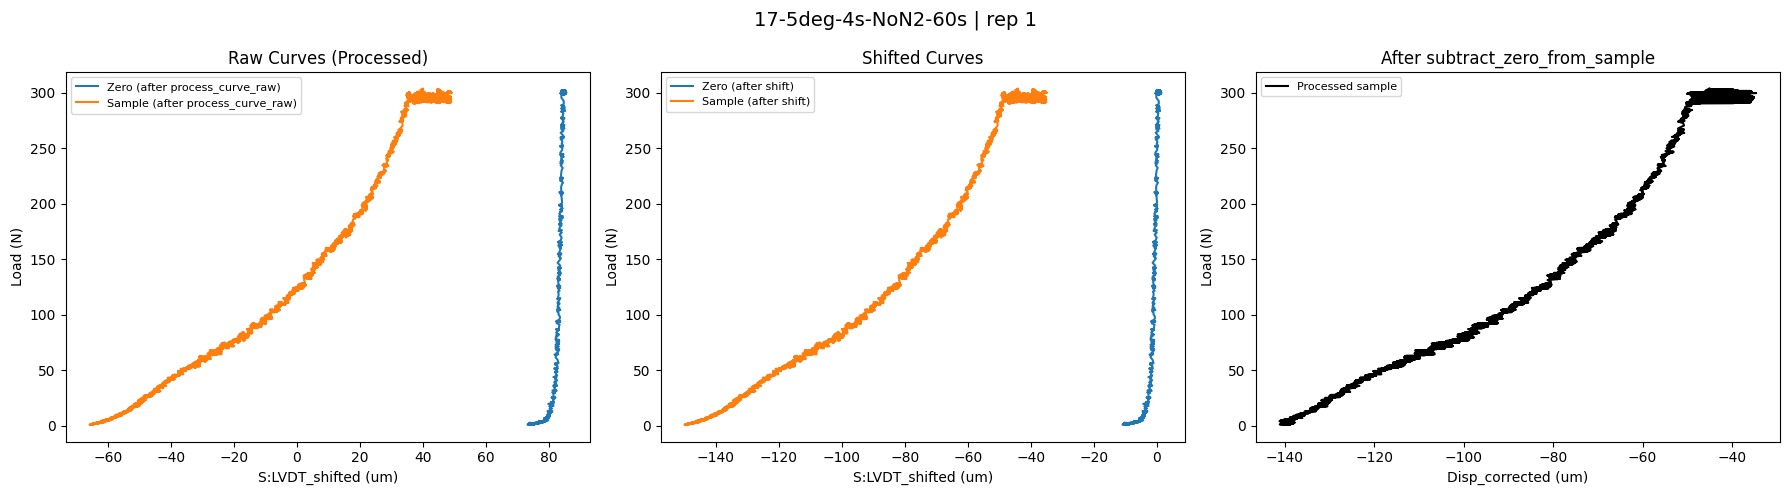

Average Standard Deviation: 55.45227669617775
Cutoff = -0.010348134899033079
PW + Double: None
Drop Chosen! 0.12866093407295387 | Piecewise Calculation: None
Cutoff = -0.010348134899033079
{'name': '17-5deg-4s-NoN2-60s | rep 1', 'Trial': 'sample 4', 'Thickness': np.float64(139.9794), 'Elastic Modulus': np.float64(158.69438667476828), 'Yield Strength': np.float64(22.575272695167143), 'Changepoint': np.float64(0.48259093914164436), 'Slope Plateau': np.float64(120.11444344270637), 'Slope Densification': np.float64(502.4447082424745), 'Creep Strain': np.float64(0.10636235355783774), 'Strain at 50 bar': 0.33262562155016606, 'Strain at 80 bar': 0.4662673730457204, 'Strain at 150 bar': 0.6440780776110118, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(55.45227669617775)}


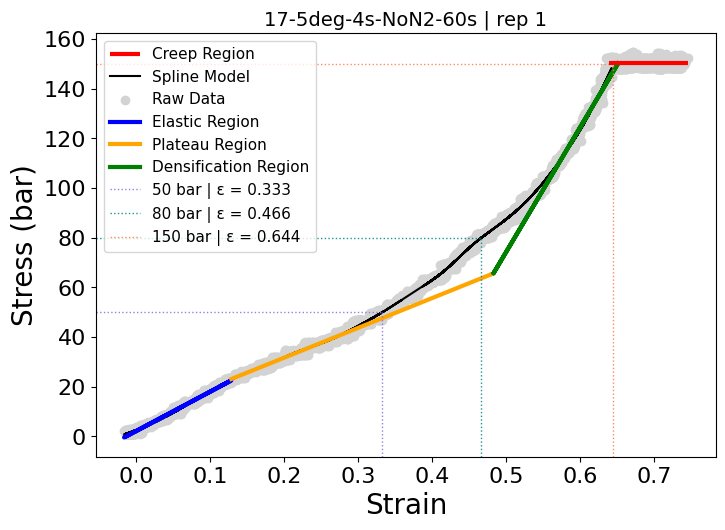

Score: 90/100 → PASS
  elastic_r2                     15/15  R²=0.985
  yield_accuracy                  8/10  |linear-GAM|=0.37 bar (1.6%)
  elastic_modulus                 5/5  E=158.7 bar
  junction_continuity            11/15  gap=2.5%
  plateau_flatness                1/5  slope/E=0.757
  plateau_r2_start               10/10  R²(first 40%)=0.971
  slope_ordering                  8/8  densif=502.4 > plateau=120.1
  densification_r2                2/2  R²=0.865
  elastic_vs_plateau             10/10  E=158.7 > slope=120.1
  breakpoint_order                5/5  bp1=0.129 < cp=0.483 < max=0.651
  densif_vs_elastic               5/5  densif/E=3.17
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=83.6 vs creep=150.3


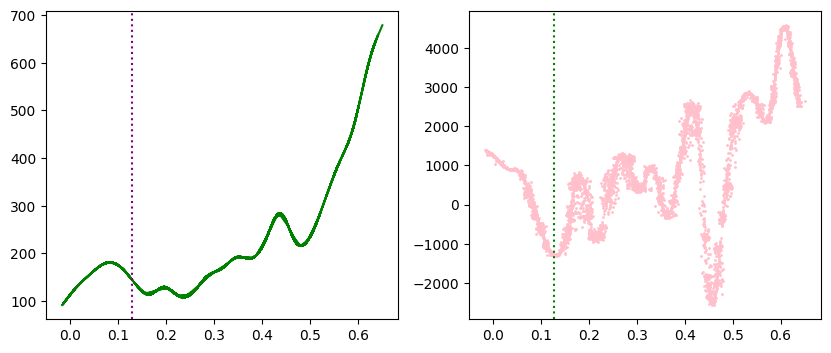

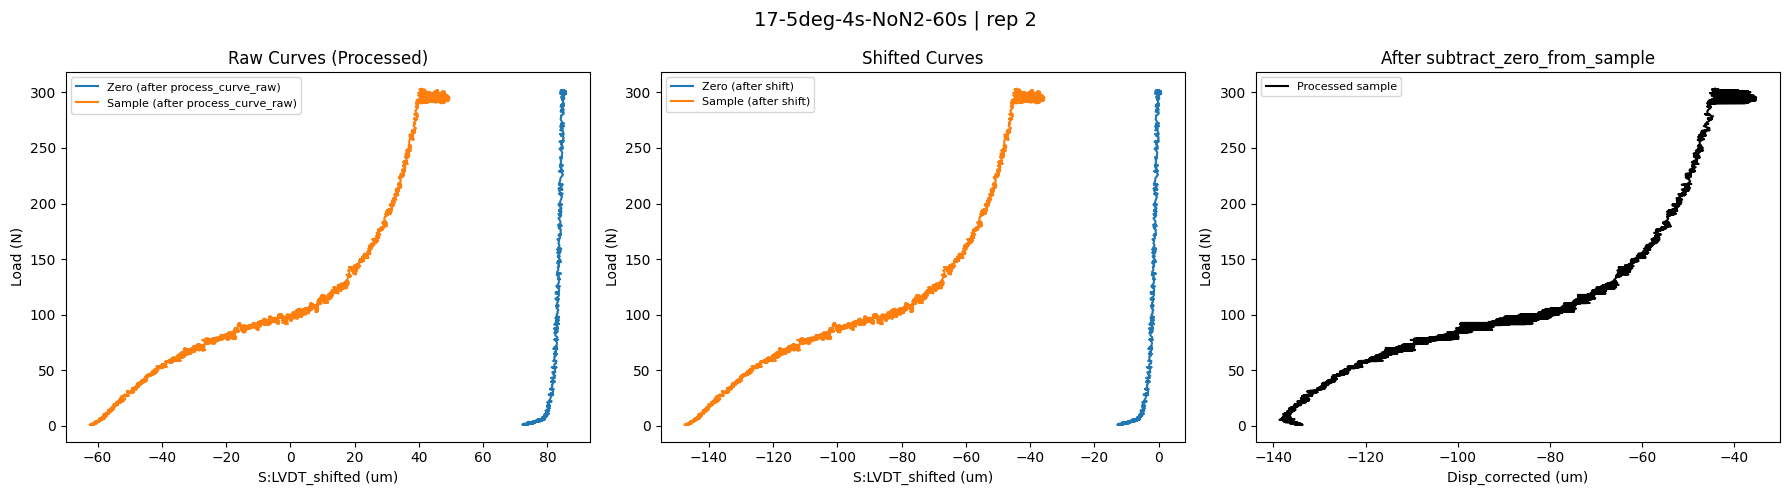

Average Standard Deviation: 54.19080846046553
Cutoff = 0.28285710300371925
PW + Double: 0.06968131187285845
Piecewise Chosen! 0.08304082710320027 | Drop Calculation: 0.04344866007565022
Cutoff = 0.28285710300371925
{'name': '17-5deg-4s-NoN2-60s | rep 2', 'Trial': 'sample 5', 'Thickness': np.float64(134.366), 'Elastic Modulus': np.float64(231.99262550562568), 'Yield Strength': np.float64(26.20889759638728), 'Changepoint': np.float64(0.5830606444905576), 'Slope Plateau': np.float64(100.16525124588237), 'Slope Densification': np.float64(713.7438623848227), 'Creep Strain': np.float64(0.07140645251586786), 'Strain at 50 bar': 0.3903591682419658, 'Strain at 80 bar': 0.5664231489720548, 'Strain at 150 bar': 0.6794255490442366, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(54.19080846046553)}


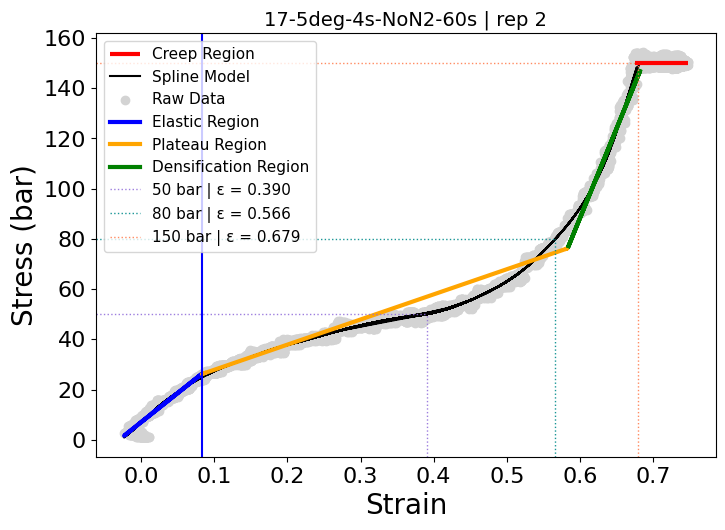

Score: 89/100 → PASS
  elastic_r2                     14/15  R²=0.933
  yield_accuracy                  5/10  |linear-GAM|=1.36 bar (5.5%)
  elastic_modulus                 5/5  E=232.0 bar
  junction_continuity            15/15  gap=0.3%
  plateau_flatness                1/5  slope/E=0.432
  plateau_r2_start                9/10  R²(first 40%)=0.941
  slope_ordering                  8/8  densif=713.7 > plateau=100.2
  densification_r2                2/2  R²=0.940
  elastic_vs_plateau             10/10  E=232.0 > slope=100.2
  breakpoint_order                5/5  bp1=0.083 < cp=0.583 < max=0.682
  densif_vs_elastic               5/5  densif/E=3.08
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=85.6 vs creep=150.2


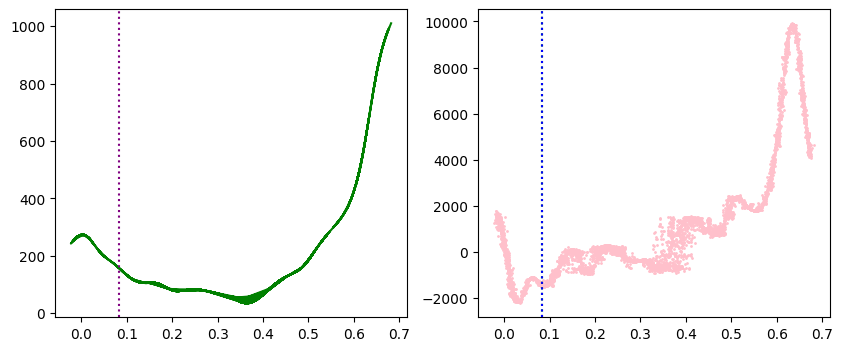

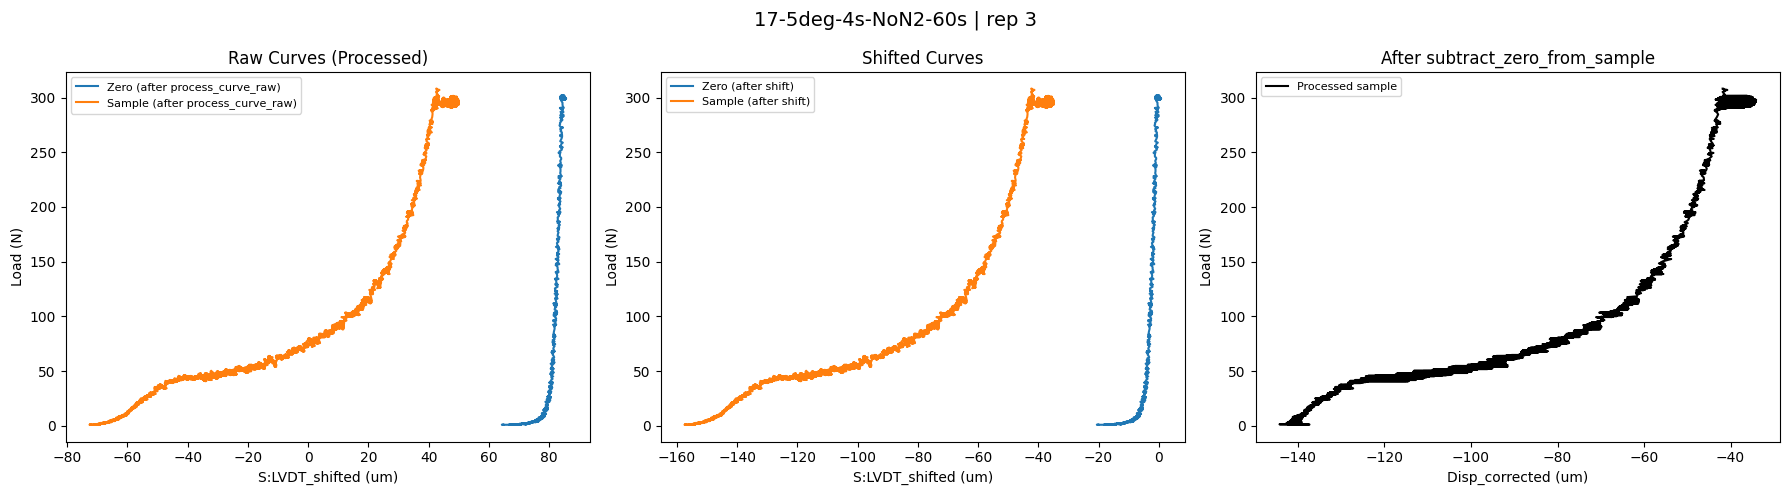

Average Standard Deviation: 59.04317554967603
Cutoff = 0.29637822075131587
PW + Double: 0.09226610753130896
Piecewise Chosen! 0.094536059010328 | Drop Calculation: 0.1419625479849979
Cutoff = 0.29637822075131587
{'name': '17-5deg-4s-NoN2-60s | rep 3', 'Trial': 'sample 6', 'Thickness': np.float64(140.6906), 'Elastic Modulus': np.float64(203.82327635288078), 'Yield Strength': np.float64(19.899986201986177), 'Changepoint': np.float64(0.577718131861163), 'Slope Plateau': np.float64(38.38790005770998), 'Slope Densification': np.float64(790.3277671882438), 'Creep Strain': np.float64(0.06228932025240297), 'Strain at 50 bar': 0.5202363625370071, 'Strain at 80 bar': 0.6232530283014039, 'Strain at 150 bar': 0.7110768957091813, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(59.04317554967603)}


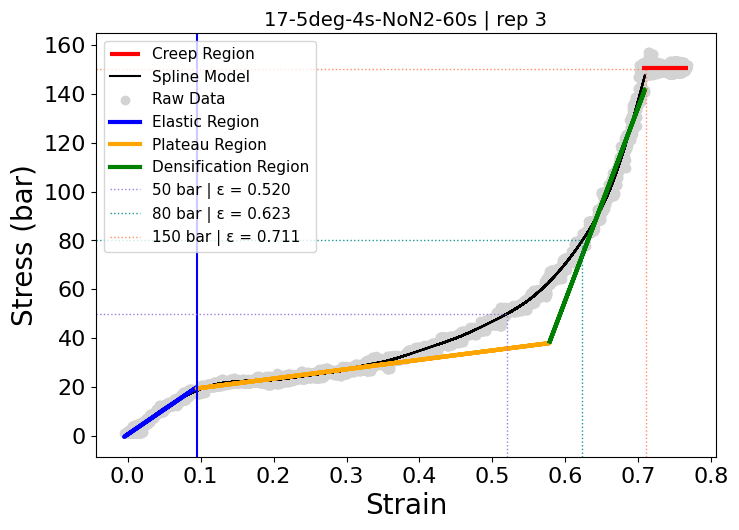

Score: 85/100 → PASS
  elastic_r2                     15/15  R²=0.969
  yield_accuracy                  3/10  |linear-GAM|=1.32 bar (7.1%)
  elastic_modulus                 5/5  E=203.8 bar
  junction_continuity            12/15  gap=2.3%
  plateau_flatness                2/5  slope/E=0.188
  plateau_r2_start                8/10  R²(first 40%)=0.767
  slope_ordering                  8/8  densif=790.3 > plateau=38.4
  densification_r2                2/2  R²=0.840
  elastic_vs_plateau             10/10  E=203.8 > slope=38.4
  breakpoint_order                5/5  bp1=0.095 < cp=0.578 < max=0.709
  densif_vs_elastic               5/5  densif/E=3.88
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=63.0 vs creep=150.4
Condition: 17-5deg-4s-NoN2-60s_run2 | pairs: 3


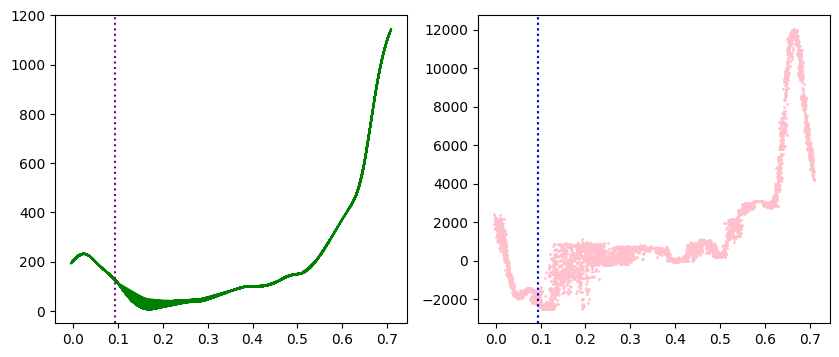

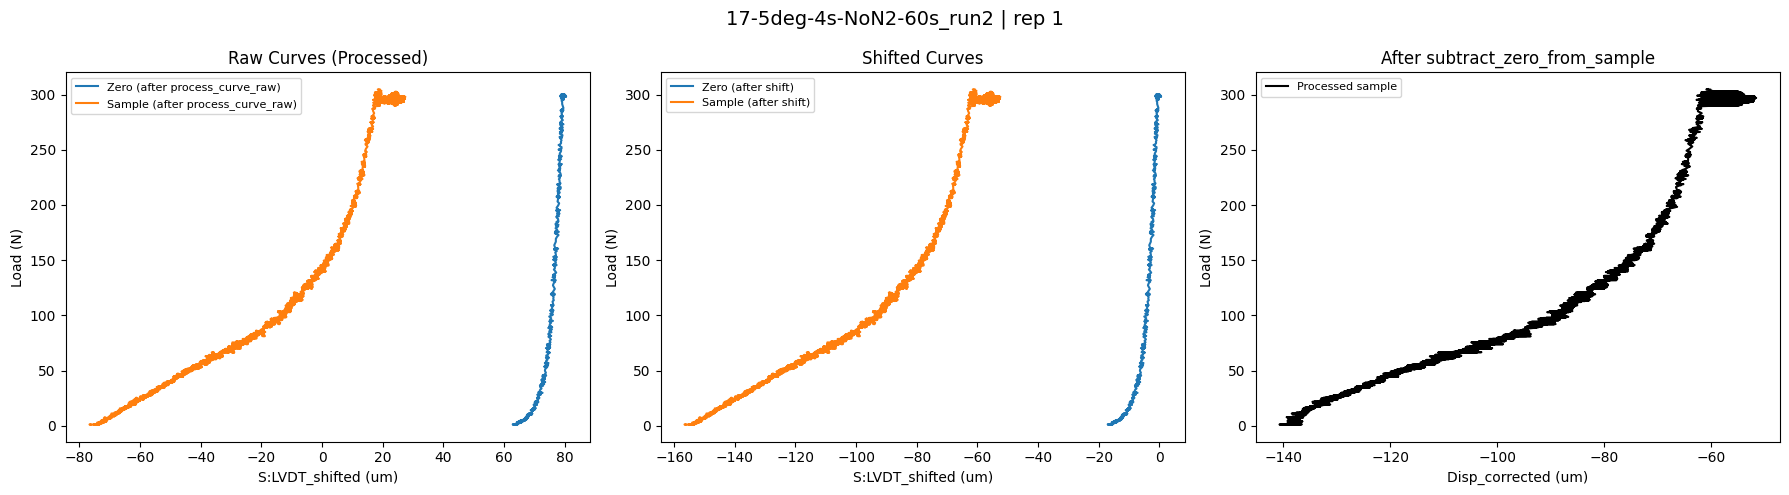

Average Standard Deviation: 56.114500656356235
Cutoff = 0.18583665187245885
PW + Double: None
Drop Chosen! 0.02544779053269397 | Piecewise Calculation: None
Cutoff = 0.18583665187245885
{'name': '17-5deg-4s-NoN2-60s_run2 | rep 1', 'Trial': 'sample 4', 'Thickness': np.float64(138.20139999999998), 'Elastic Modulus': np.float64(249.33681560181643), 'Yield Strength': np.float64(8.944469761189671), 'Changepoint': np.float64(0.47095339220834487), 'Slope Plateau': np.float64(141.47266101511187), 'Slope Densification': np.float64(867.3699328559815), 'Creep Strain': np.float64(0.0754446633964877), 'Strain at 50 bar': 0.3493894488524183, 'Strain at 80 bar': 0.4666251876883448, 'Strain at 150 bar': 0.5551162061074144, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(56.114500656356235)}


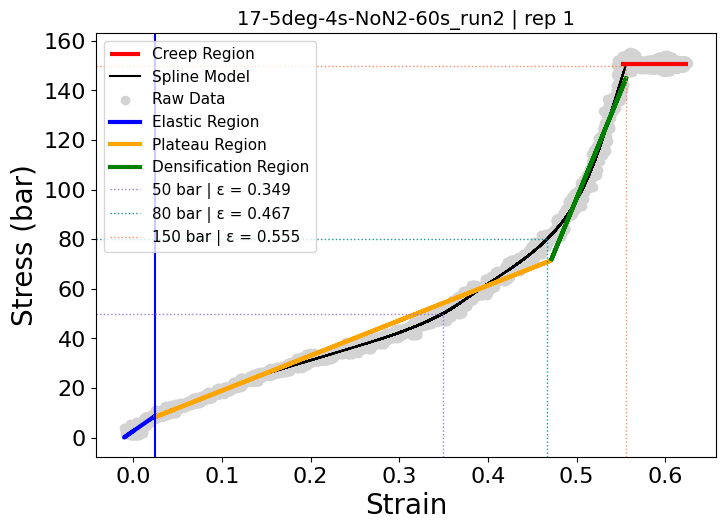

Score: 78/100 → PASS
  elastic_r2                     12/15  R²=0.776
  yield_accuracy                  4/10  |linear-GAM|=0.51 bar (6.0%)
  elastic_modulus                 5/5  E=249.3 bar
  junction_continuity             6/15  gap=6.2%
  plateau_flatness                1/5  slope/E=0.567
  plateau_r2_start               10/10  R²(first 40%)=0.970
  slope_ordering                  8/8  densif=867.4 > plateau=141.5
  densification_r2                2/2  R²=0.945
  elastic_vs_plateau             10/10  E=249.3 > slope=141.5
  breakpoint_order                5/5  bp1=0.025 < cp=0.471 < max=0.556
  densif_vs_elastic               5/5  densif/E=3.48
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=81.6 vs creep=150.5


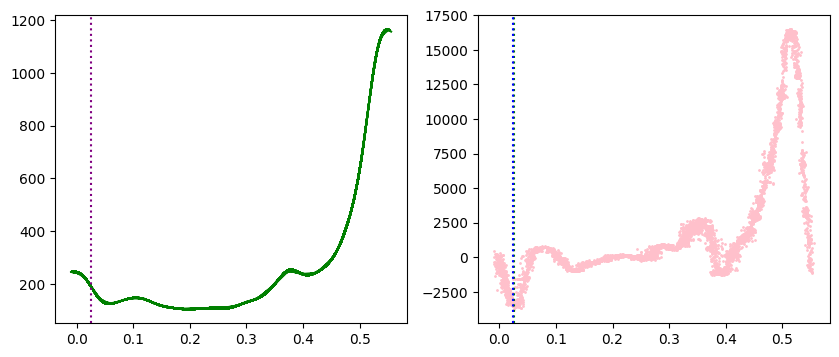

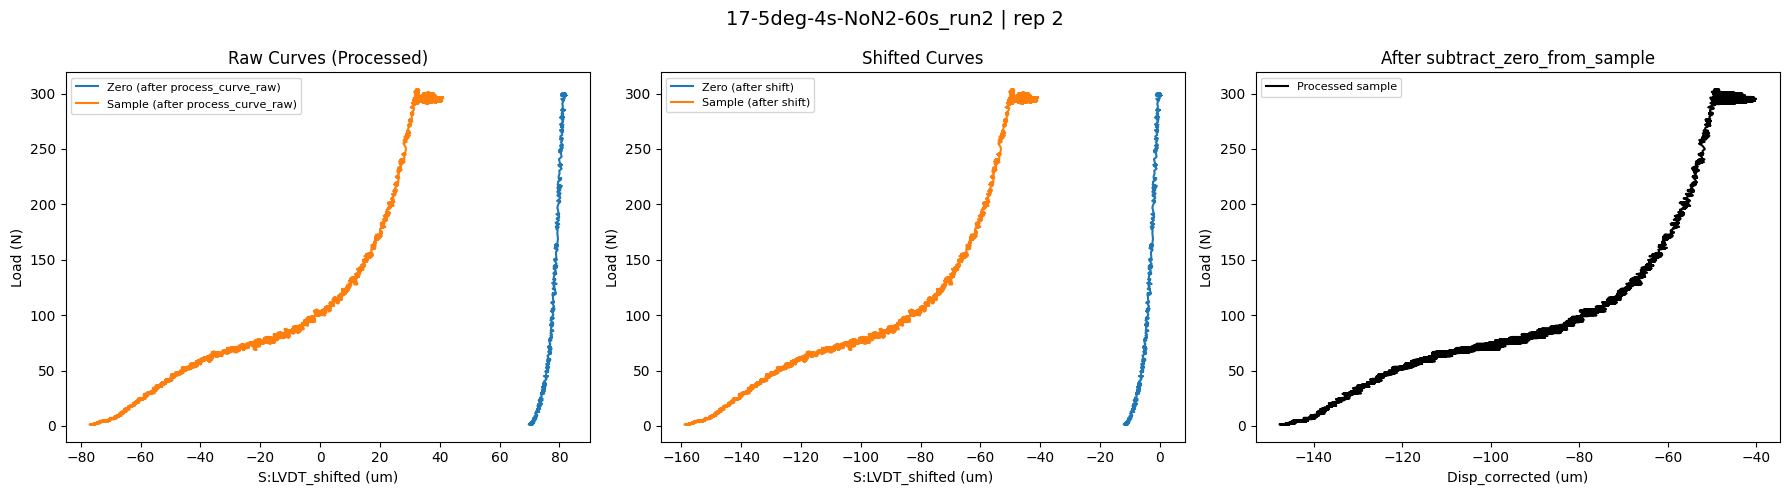

Average Standard Deviation: 57.08274392878563
Cutoff = 0.24963461287022232
PW + Double: 0.16795203715104895
Piecewise Chosen! 0.1691820423387429 | Drop Calculation: 0.17371612611508244
Cutoff = 0.24963461287022232
{'name': '17-5deg-4s-NoN2-60s_run2 | rep 2', 'Trial': 'sample 5', 'Thickness': np.float64(146.8628), 'Elastic Modulus': np.float64(162.97327352336112), 'Yield Strength': np.float64(26.27644559775721), 'Changepoint': np.float64(0.54872577880852), 'Slope Plateau': np.float64(65.1878573386652), 'Slope Densification': np.float64(834.5888398328125), 'Creep Strain': np.float64(0.06659378627289769), 'Strain at 50 bar': 0.4521424800387849, 'Strain at 80 bar': 0.5707438371170316, 'Strain at 150 bar': 0.6566345394932052, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(57.08274392878563)}


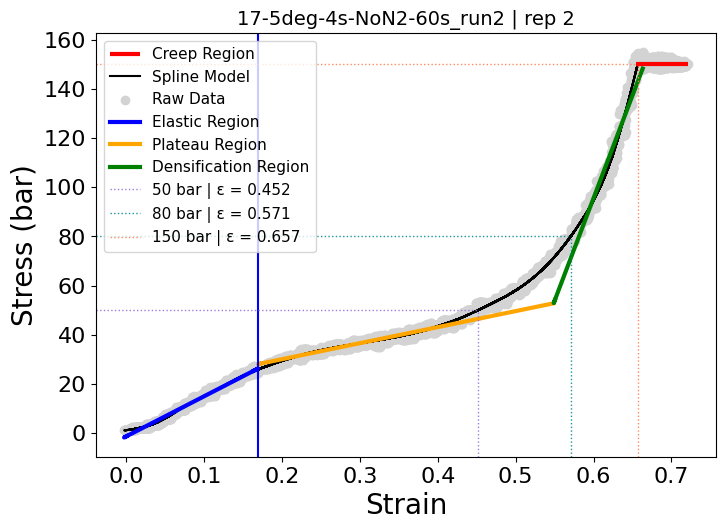

Score: 84/100 → PASS
  elastic_r2                     15/15  R²=0.987
  yield_accuracy                  9/10  |linear-GAM|=0.36 bar (1.4%)
  elastic_modulus                 5/5  E=163.0 bar
  junction_continuity             5/15  gap=6.8%
  plateau_flatness                1/5  slope/E=0.400
  plateau_r2_start                9/10  R²(first 40%)=0.906
  slope_ordering                  8/8  densif=834.6 > plateau=65.2
  densification_r2                2/2  R²=0.893
  elastic_vs_plateau             10/10  E=163.0 > slope=65.2
  breakpoint_order                5/5  bp1=0.169 < cp=0.549 < max=0.663
  densif_vs_elastic               5/5  densif/E=5.12
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=71.2 vs creep=150.3


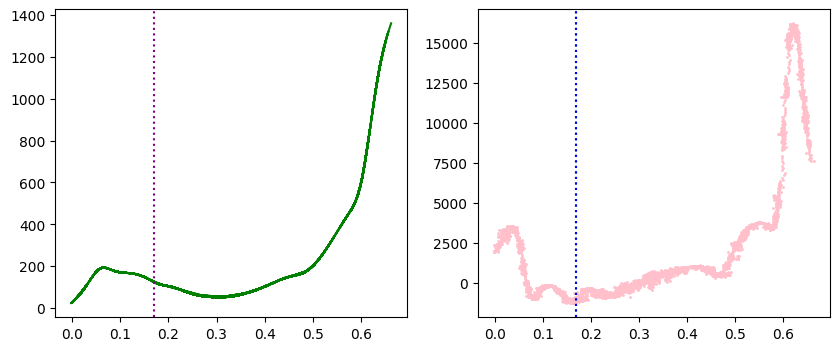

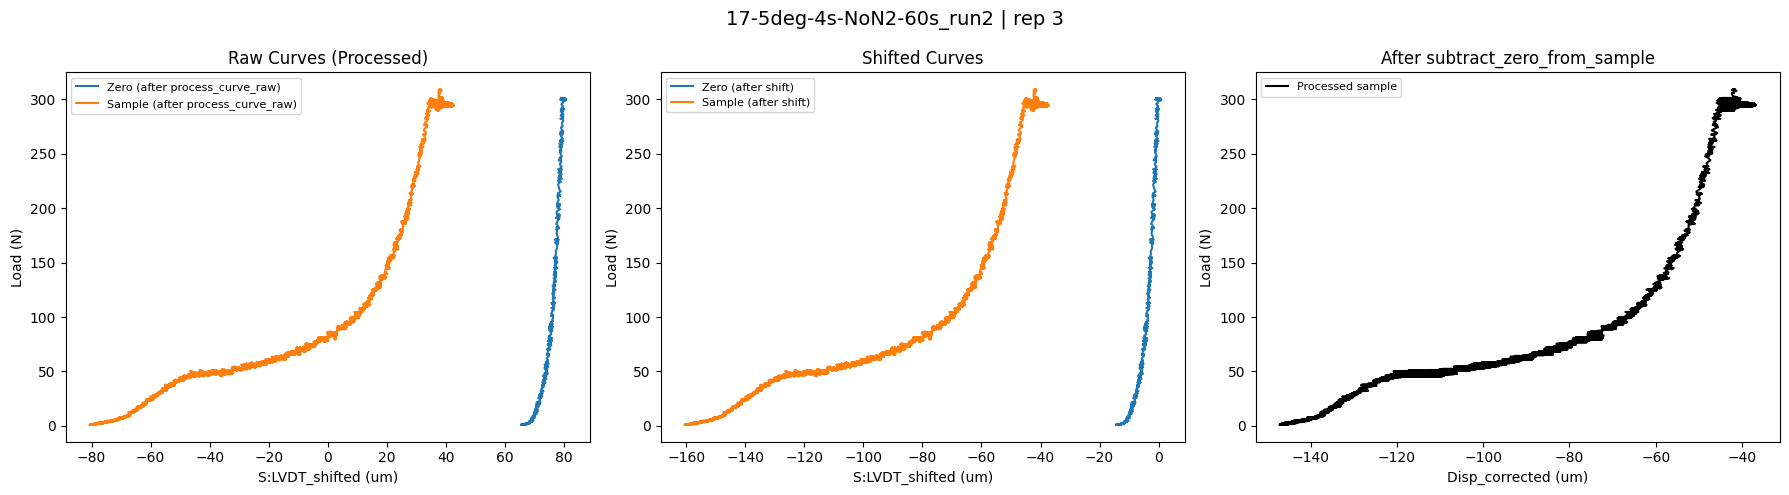

Average Standard Deviation: 59.541869393772004
Cutoff = 0.26566795655320763
PW + Double: 0.15496082206929418
Piecewise Chosen! 0.1646622447788251 | Drop Calculation: 0.19348747347448148
Cutoff = 0.26566795655320763
{'name': '17-5deg-4s-NoN2-60s_run2 | rep 3', 'Trial': 'sample 6', 'Thickness': np.float64(146.32939999999996), 'Elastic Modulus': np.float64(148.24310946544065), 'Yield Strength': np.float64(23.52918433778745), 'Changepoint': np.float64(0.5780525576625258), 'Slope Plateau': np.float64(46.49614264929848), 'Slope Densification': np.float64(975.0055188015425), 'Creep Strain': np.float64(0.056162224692898), 'Strain at 50 bar': 0.5311634659767925, 'Strain at 80 bar': 0.6137260225759961, 'Strain at 150 bar': 0.6841691419465774, 'Strain at 500 bar': nan, 'Good Fit': True, 'Average Standard Deviation': np.float64(59.541869393772004)}


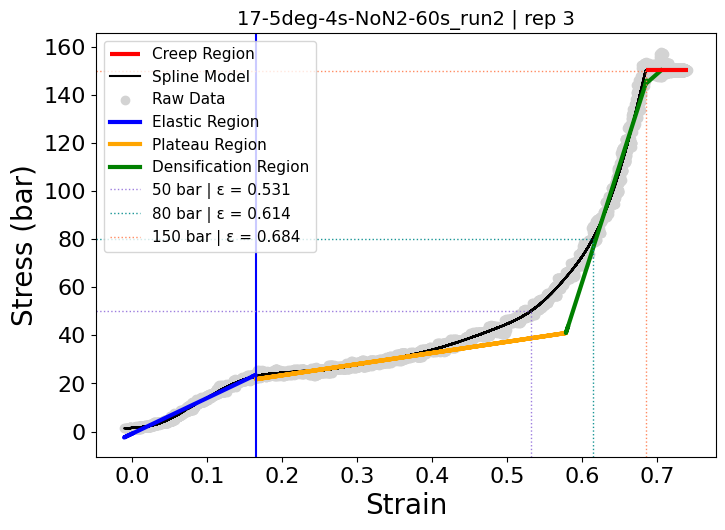

Score: 80/100 → PASS
  elastic_r2                     15/15  R²=0.975
  yield_accuracy                  8/10  |linear-GAM|=0.48 bar (2.1%)
  elastic_modulus                 5/5  E=148.2 bar
  junction_continuity             4/15  gap=7.6%
  plateau_flatness                1/5  slope/E=0.314
  plateau_r2_start                7/10  R²(first 40%)=0.717
  slope_ordering                  8/8  densif=975.0 > plateau=46.5
  densification_r2                2/2  R²=0.874
  elastic_vs_plateau             10/10  E=148.2 > slope=46.5
  breakpoint_order                5/5  bp1=0.165 < cp=0.578 < max=0.705
  densif_vs_elastic               5/5  densif/E=6.58
  data_density                    5/5  3/3 regions have ≥5 pts
  changepoint_vs_creep            5/5  GAM(cp)=64.1 vs creep=150.2


12

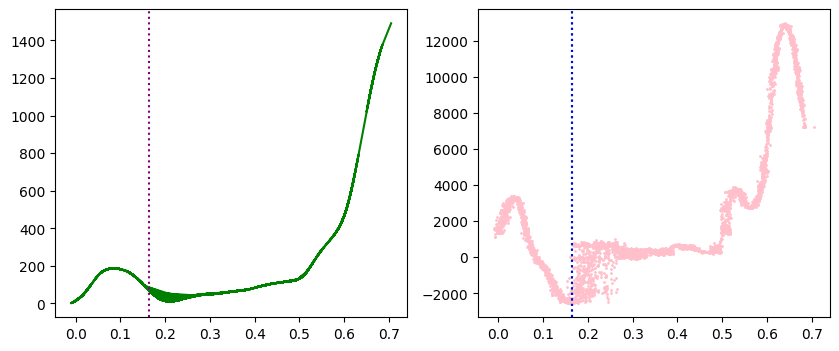

In [211]:
# Example run: processes each pair, shows both requested plots per pair, and returns all outputs.

pipeline_result = process_zero_sample_pairs_pipeline(
    folder_name="compression-test-data",
    data_root=".",
    strict=True,
    load_cutoff=1.0,
    thickness_info=False,
    creep_info=True,
)

len(pipeline_result)